# Dyck Counting Features for Four Models

- training sanity checks
- next-token accuracy by position
- counting-feature probes at a fixed prefix
- supervised projection plots
- PCA / rotated-plane diagnostics
- prefix sweep plots
- direction-arithmetic plots

This notebook keeps the reference-style plot families, but runs them sequentially for `rnn -> lstm -> transformer -> mamba` under the current project setting.

## 0. Path Setup

In [47]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ROOT

PosixPath('/home/hp_twist_shan/Research/Hidden State Evaluation')

## 1. Imports

In [48]:
import json

import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from hse.experiments.dyck import DEFAULT_DYCK_MODEL_SPECS, DEFAULT_DYCK_TASKS
from hse.models import build_model
from hse.tasks.dyck import DyckConfig, DyckSampler
from hse.utils import evaluate_causal_lm, train_causal_lm

sns.set_theme(style="whitegrid", context="talk")

## 2. Global Knobs

These defaults are now set to a long-form `dyck_no_noise` experiment with 200 Dyck pairs and total length 400. The run writes to a separate results directory so it retrains from scratch without overwriting the earlier shorter checkpoints.

In [49]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TASK_NAME = "dyck_no_noise"
NOTEBOOK_BASE_TASK = dict(DEFAULT_DYCK_TASKS[TASK_NAME])
TASK_RUN_NAME = "dyck_no_noise_pairs200_len400"
DYCK_PAIRS = 200
TOTAL_LENGTH = 400
SEQ_LEN = 400
REPEAT_PROB = NOTEBOOK_BASE_TASK["repeat_prob"]
N_TASKS = NOTEBOOK_BASE_TASK["n_tasks"]
PREFIX_PROBE_MAX_LEN = NOTEBOOK_BASE_TASK["prefix_probe_max_len"]
TASK_OVERRIDES = {
    "dyck_pairs": DYCK_PAIRS,
    "total_length": TOTAL_LENGTH,
    "seq_len": SEQ_LEN,
    "repeat_prob": REPEAT_PROB,
    "n_tasks": N_TASKS,
    "prefix_probe_max_len": PREFIX_PROBE_MAX_LEN,
}
MODEL_TYPES = ["rnn", "lstm", "transformer", "mamba"]
STATE_KIND_BY_MODEL = {"rnn": "h", "lstm": "c", "transformer": "h", "mamba": "h"}

TRAINING_STEPS = 10000
BATCH_SIZE = 128
LEARNING_RATE = 3e-4
EVAL_EVERY = 200
TRAIN_SEED = 0

PREFIX_LENGTH = 200
LAYER_INDEX = -1
N_PROBE_SAMPLES = 20000
PROBE_BATCH_SIZE = 1024
BALANCE_PROBE_BY = "height"
BALANCE_SEED = 0
HEIGHT_GEOMETRY_MIN_COUNT = 5
HEIGHT_GEOMETRY_PLOT_POINTS = 5000
MANIFOLD_SUBSPACE_DIM = 6
MANIFOLD_CURVE_SAMPLES_PER_SEG = 40
MANIFOLD_PROJECTION_BATCH = 512
MANIFOLD_HTML_POINTS = 12000
MANIFOLD_SWEEP_DIMS = [2, 3, 4, 6, 8, 10, 12]

SWEEP_PREFIX_LENGTHS = list(range(20, TOTAL_LENGTH, 20))
SWEEP_N_SAMPLES = 8192

FORCE_RETRAIN = False
EXPERIMENT_TAG = "formal_long_pairs200_len400"
RESULTS_ROOT = ROOT / "results" / "notebooks" / "dyck_reference_style" / EXPERIMENT_TAG / TASK_RUN_NAME
RESULTS_ROOT

PosixPath('/home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_reference_style/formal_long_pairs200_len400/dyck_no_noise_pairs200_len400')

## 3. Core Helpers

In [50]:
def save_json(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def get_task_kwargs(task_name=TASK_NAME):
    task_kwargs = dict(DEFAULT_DYCK_TASKS[task_name])
    task_kwargs.update(TASK_OVERRIDES)
    task_kwargs["device"] = DEVICE
    return task_kwargs


def get_task_config(task_name=TASK_NAME):
    return DyckConfig(**get_task_kwargs(task_name))


def get_model_spec(model_type):
    spec = dict(DEFAULT_DYCK_MODEL_SPECS[model_type])
    if model_type == "lstm":
        spec["state_kind"] = "c"
    return spec


def get_run_dir(model_type):
    return RESULTS_ROOT / f"{model_type}_seed{TRAIN_SEED}"


def build_fresh_model(model_type):
    spec = get_model_spec(model_type)
    model_kwargs = {k: v for k, v in spec.items() if k != "state_kind"}
    cfg = get_task_config()
    return build_model(model_name=model_type, vocab_size=cfg.vocab_size, **model_kwargs).to(DEVICE)


def make_sampler(seed_offset=0):
    return DyckSampler(get_task_config(), seed=TRAIN_SEED + seed_offset)


def load_or_train_model(model_type):
    run_dir = get_run_dir(model_type)
    checkpoint_path = run_dir / "checkpoints" / "model_final.pt"
    metrics_path = run_dir / "metrics.json"
    config_path = run_dir / "config.json"

    model = build_fresh_model(model_type)
    train_sampler = make_sampler(seed_offset=0)

    if checkpoint_path.exists() and metrics_path.exists() and not FORCE_RETRAIN:
        payload = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(payload["model"])
        return {
            "model": model,
            "train_sampler": train_sampler,
            "metrics": load_json(metrics_path),
            "run_dir": run_dir,
            "config": load_json(config_path) if config_path.exists() else None,
        }

    run_dir.mkdir(parents=True, exist_ok=True)
    spec = get_model_spec(model_type)
    save_json(
        {
            "task_name": TASK_RUN_NAME,
            "base_task_name": TASK_NAME,
            "task_overrides": TASK_OVERRIDES,
            "task": get_task_kwargs(),
            "model_type": model_type,
            "model_spec": spec,
            "training_steps": TRAINING_STEPS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "device": DEVICE,
            "seed": TRAIN_SEED,
        },
        config_path,
    )
    train_log = train_causal_lm(
        model=model,
        sampler=train_sampler,
        steps=TRAINING_STEPS,
        batch_size=BATCH_SIZE,
        lr=LEARNING_RATE,
        run_dir=run_dir,
        eval_every=EVAL_EVERY,
        device=DEVICE,
    )
    eval_metrics = evaluate_causal_lm(
        model=model,
        sampler=make_sampler(seed_offset=100),
        batch_size=BATCH_SIZE,
        device=DEVICE,
    )
    metrics = {"train": train_log, "eval": eval_metrics}
    save_json(metrics, metrics_path)
    return {
        "model": model,
        "train_sampler": train_sampler,
        "metrics": metrics,
        "run_dir": run_dir,
        "config": load_json(config_path),
    }


## 4. Training Sanity Checks

Define the shared sanity-check helpers used right after training. This cell smooths noisy loss curves and computes Dyck next-token accuracy by position so we can verify each model has really learned the long counting task before probing hidden states.


In [51]:
def moving_average_edge(x, window=11):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x.copy()
    left = window // 2
    right = window - 1 - left
    padded = np.pad(x, (left, right), mode="edge")
    return np.convolve(padded, np.ones(window) / window, mode="valid")


@torch.no_grad()
def compute_position_accuracy(model, sampler, *, num_samples=2048, batch_size=512):
    model.eval().to(DEVICE)
    numer = None
    denom = None
    total_correct = 0.0
    total_count = 0.0
    remaining = int(num_samples)

    while remaining > 0:
        bs = min(int(batch_size), remaining)
        batch = sampler.sample(bs)
        tokens = batch.tokens.to(DEVICE)
        dyck_mask = batch.dyck_mask.to(DEVICE)
        logits = model(tokens)
        pred = logits[:, :-1, :].argmax(dim=-1)
        target = tokens[:, 1:]
        eval_mask = dyck_mask[:, 1:]
        correct = (pred == target) & eval_mask

        batch_numer = correct.float().sum(dim=0).detach().cpu()
        batch_denom = eval_mask.float().sum(dim=0).detach().cpu()
        numer = batch_numer if numer is None else numer + batch_numer
        denom = batch_denom if denom is None else denom + batch_denom
        total_correct += float(batch_numer.sum())
        total_count += float(batch_denom.sum())
        remaining -= bs

    acc = torch.full_like(denom, float("nan"))
    valid = denom > 0
    acc[valid] = numer[valid] / denom[valid]
    return np.arange(acc.numel()), acc.numpy(), total_correct / max(total_count, 1.0)


def plot_loss_sanity(model_type, metrics):
    train_df = pd.DataFrame(metrics["train"])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(train_df["step"], train_df["loss"], lw=0.8, alpha=0.55, label="raw")
    if len(train_df) >= 5:
        smooth = moving_average_edge(train_df["loss"], window=min(11, len(train_df) if len(train_df) % 2 == 1 else len(train_df) - 1))
        axes[0].plot(train_df["step"], smooth, lw=1.6, label="smoothed")
    axes[0].set_title(f"{model_type.upper()} train loss")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("cross entropy")
    axes[0].legend(frameon=False)
    axes[0].grid(True, alpha=0.25)

    axes[1].plot(train_df["step"], train_df["eval_loss"], label="eval loss", lw=1.8)
    axes[1].set_title(f"{model_type.upper()} eval loss")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("cross entropy")
    axes[1].legend(frameon=False)
    axes[1].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


def plot_accuracy_sanity(model_type, model):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    summary = {}
    pos, acc, mean_acc = compute_position_accuracy(model, make_sampler(seed_offset=100))
    ax.plot(pos, acc, label=f"eval mean={mean_acc:.3f}")
    summary["eval"] = mean_acc
    ax.set_title(f"{model_type.upper()} Dyck-only next-token accuracy")
    ax.set_xlabel("target position")
    ax.set_ylabel("accuracy")
    ax.set_ylim(0, 1.02)
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
    print(f"{model_type.upper()} mean accuracy: " + ", ".join(f"{k}={v:.4f}" for k, v in summary.items()))
    return summary

### Shared Result Containers

Initialize the dictionaries that will hold each trained model and its sanity-check outputs. These shared containers let the later probe and manifold cells reuse the exact same loaded payloads instead of retraining or recomputing them.


In [52]:
loaded_models = {}
sanity_results = {}

## 4A. Train RNN

Load or train the `RNN`, cache its payload in `loaded_models`, and immediately plot the training-loss and position-wise accuracy sanity checks. This gives us a quick read on whether the recurrent baseline has learned the task well enough for later geometry analysis.


SANITY: rnn


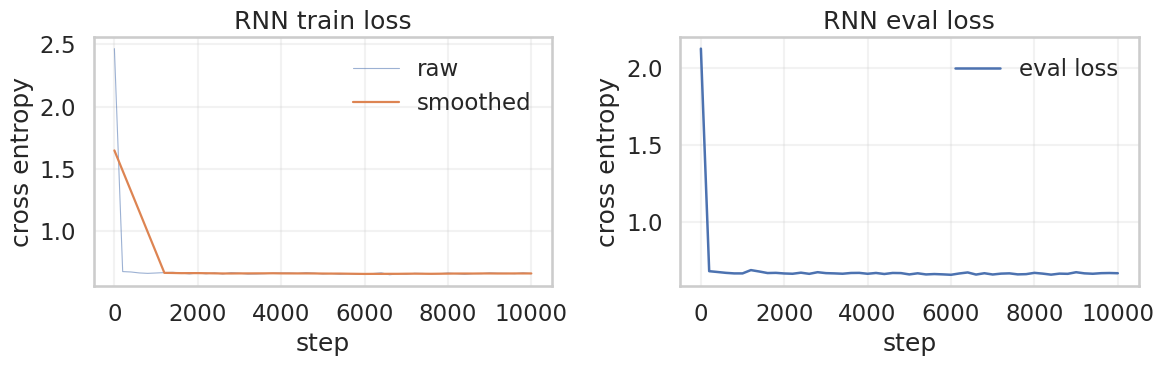

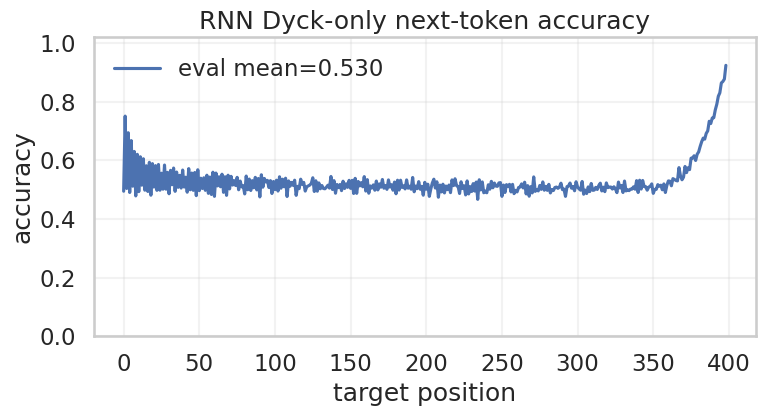

RNN mean accuracy: eval=0.5295


In [53]:
model_type = "rnn"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])

## 4B. Train LSTM

Do the same training-or-loading and sanity-check pass for the `LSTM`. Its saved model, metrics, and diagnostic plots are reused by all later probe and manifold sections.


SANITY: lstm


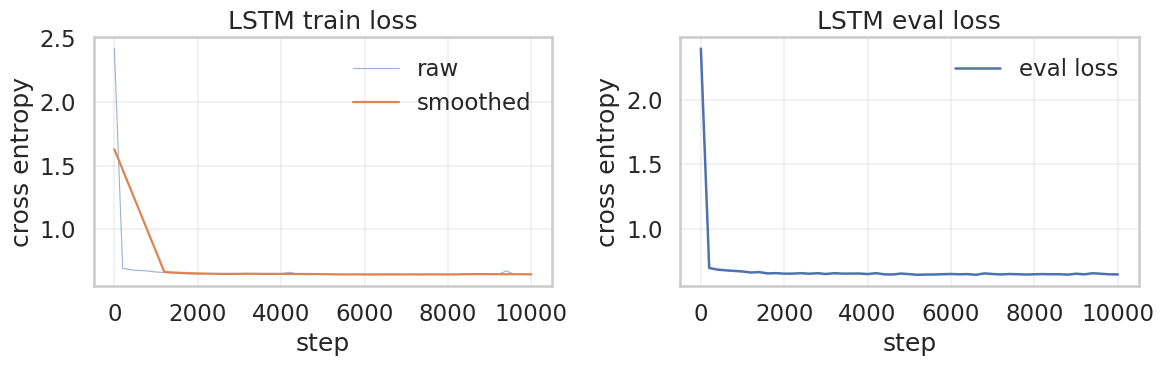

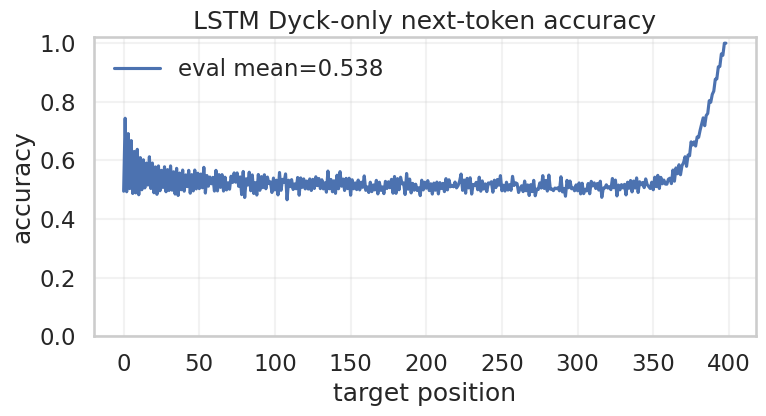

LSTM mean accuracy: eval=0.5383


In [54]:
model_type = "lstm"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])

## 4C. Train Transformer

Run the long-task training/sanity pipeline for the `Transformer`. This cell adds the transformer payload to the shared result dictionary and visualizes whether its token-level behavior is reliable enough for representation analysis.


SANITY: transformer


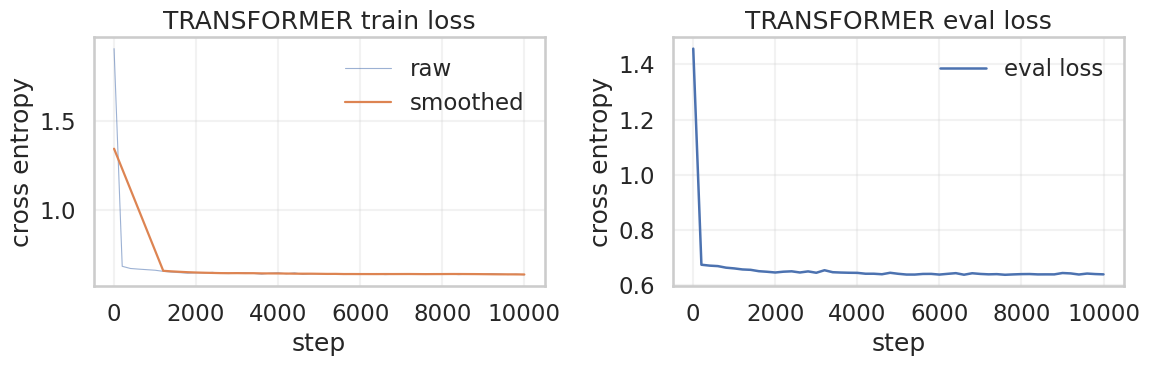

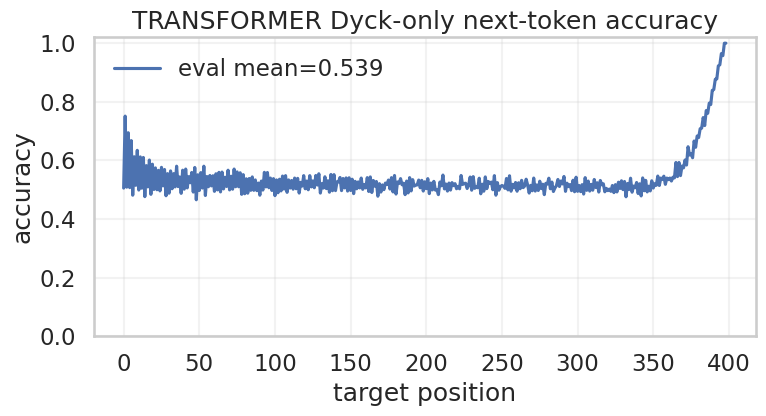

TRANSFORMER mean accuracy: eval=0.5390


In [55]:
model_type = "transformer"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])

## 4D. Train Mamba

Run the corresponding training/sanity pipeline for `Mamba`. After this cell, all four model families are loaded and ready for the shared probe, sweep, and manifold experiments below.


SANITY: mamba


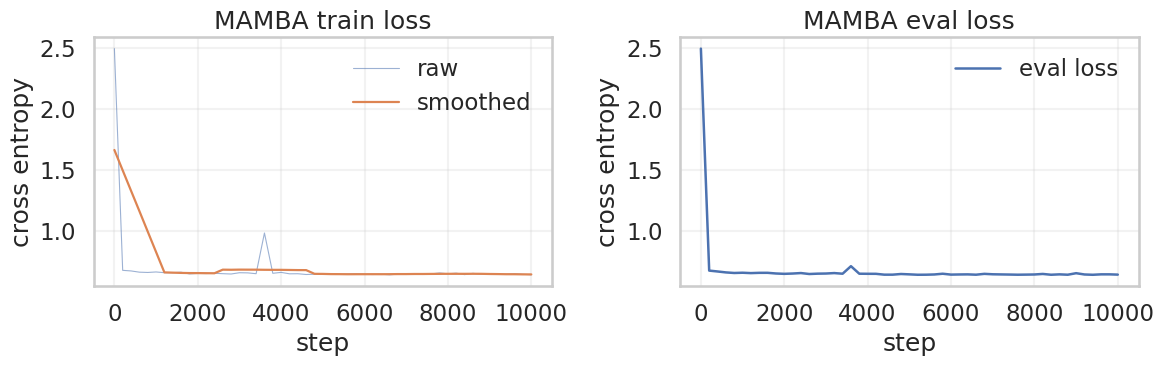

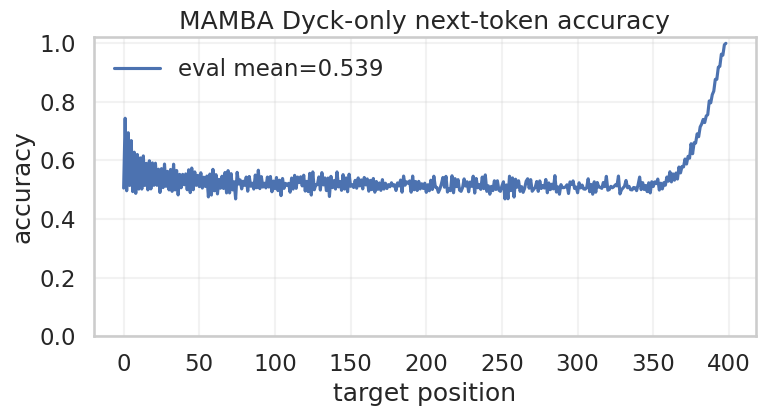

MAMBA mean accuracy: eval=0.5388


In [56]:
model_type = "mamba"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])

## 5. Counting Probe Data and Probe Fitting

Sample hidden states at a fixed Dyck prefix and turn each prefix into probe labels such as `left`, `right`, `height`, and exact `(left, right)` count pairs. This cell also defines the linear and logistic probe fitting code used to test whether these counting variables are linearly recoverable from the hidden representation.


In [57]:
@torch.no_grad()
def sample_hidden_count_matrix(
    model,
    sampler,
    *,
    prefix_length=PREFIX_LENGTH,
    layer_index=LAYER_INDEX,
    state_kind="h",
    n_samples=N_PROBE_SAMPLES,
    batch_size=PROBE_BATCH_SIZE,
):
    cfg = sampler.config
    assert 1 <= prefix_length <= cfg.total_length
    assert cfg.repeat_prob >= 1.0, "This reference-style notebook assumes Dyck-only prefixes from dyck_no_noise."
    model.eval().to(DEVICE)

    hs, prefixes, lefts, rights, heights, pair_ids, next_tokens = [], [], [], [], [], [], []
    remaining = int(n_samples)
    while remaining > 0:
        bs = min(int(batch_size), remaining)
        batch = sampler.sample(bs)
        tokens = batch.tokens.to(DEVICE)
        states = model.extract_states(tokens, layer_index=layer_index, state_kind=state_kind)
        h = states[:, prefix_length - 1, :].detach().cpu().numpy()
        prefix = tokens[:, :prefix_length].detach().cpu().numpy()

        open_token = cfg.open_token
        close_token = cfg.close_token
        sign = np.where(prefix == open_token, 1, np.where(prefix == close_token, -1, 0))
        left = (sign == 1).sum(axis=1)
        right = (sign == -1).sum(axis=1)
        height = left - right
        pair_id = left * (prefix_length + 1) + right

        hs.append(h)
        prefixes.append(prefix)
        lefts.append(left)
        rights.append(right)
        heights.append(height)
        pair_ids.append(pair_id)
        if prefix_length < cfg.seq_len:
            next_tokens.append(tokens[:, prefix_length].detach().cpu().numpy())
        remaining -= bs

    data = {
        "h": np.concatenate(hs, axis=0),
        "prefix": np.concatenate(prefixes, axis=0),
        "left": np.concatenate(lefts, axis=0),
        "right": np.concatenate(rights, axis=0),
        "height": np.concatenate(heights, axis=0),
        "pair_id": np.concatenate(pair_ids, axis=0),
    }
    if next_tokens:
        data["next_token"] = np.concatenate(next_tokens, axis=0)
    return data


def balance_data_by_label(data, label="height", seed=0, max_per_class=None):
    if label is None:
        return data
    y = np.asarray(data[label])
    rng = np.random.default_rng(seed)
    classes, counts = np.unique(y, return_counts=True)
    if len(classes) <= 1:
        return data
    target = int(counts.min()) if max_per_class is None else min(int(counts.min()), int(max_per_class))
    idx_parts = []
    for cls in classes:
        cls_idx = np.flatnonzero(y == cls)
        idx_parts.append(rng.choice(cls_idx, size=target, replace=False))
    idx = np.concatenate(idx_parts)
    rng.shuffle(idx)
    return {k: np.asarray(v)[idx] for k, v in data.items()}


def print_class_balance(data, label="height", name="data"):
    classes, counts = np.unique(data[label], return_counts=True)
    summary = ", ".join(f"{int(c)}:{int(n)}" for c, n in zip(classes, counts))
    print(f"{name} {label} counts -> {summary}")


def fit_ridge_probe(X_train, y_train, X_test, y_test, name):
    probe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    probe.fit(X_train, y_train)
    pred = probe.predict(X_test)
    return {
        "name": name,
        "probe": probe,
        "r2": float(r2_score(y_test, pred)),
        "mae": float(mean_absolute_error(y_test, pred)),
    }


def fit_logistic_probe(X_train, y_train, X_test, y_test, name):
    train_classes = np.unique(y_train)
    test_classes = np.unique(y_test)
    if len(train_classes) < 2 or len(test_classes) < 2:
        return {"name": name, "probe": None, "accuracy": float("nan"), "n_classes": int(len(train_classes))}
    probe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=1.0, solver="lbfgs"))
    probe.fit(X_train, y_train)
    pred = probe.predict(X_test)
    return {
        "name": name,
        "probe": probe,
        "accuracy": float(accuracy_score(y_test, pred)),
        "n_classes": int(len(train_classes)),
    }


def run_counting_probes(train_data, test_data):
    X_train = train_data["h"]
    X_test = test_data["h"]
    rows = []
    fitted = {}

    for target in ["left", "right", "height"]:
        out = fit_ridge_probe(X_train, train_data[target], X_test, test_data[target], target)
        fitted[f"ridge_{target}"] = out["probe"]
        rows.append({"probe": "ridge", "target": target, "metric": "r2", "value": out["r2"]})
        rows.append({"probe": "ridge", "target": target, "metric": "mae", "value": out["mae"]})

    for target in ["height", "pair_id"]:
        out = fit_logistic_probe(X_train, train_data[target], X_test, test_data[target], target)
        fitted[f"logistic_{target}"] = out["probe"]
        rows.append({"probe": "logistic", "target": target, "metric": "accuracy", "value": out["accuracy"]})
        rows.append({"probe": "logistic", "target": target, "metric": "n_classes", "value": out["n_classes"]})

    if "next_token" in train_data and "next_token" in test_data:
        out = fit_logistic_probe(X_train, train_data["next_token"], X_test, test_data["next_token"], "next_token")
        fitted["logistic_next_token"] = out["probe"]
        rows.append({"probe": "logistic", "target": "next_token", "metric": "accuracy", "value": out["accuracy"]})
        rows.append({"probe": "logistic", "target": "next_token", "metric": "n_classes", "value": out["n_classes"]})

    return rows, fitted

## 6. Prefix Scatter by Count Pair

Prepare a clean visualization of the hidden-state cloud at one prefix. The plotting helpers here color points by `height`, show how different count classes sit in a low-dimensional projection, and make it easier to visually inspect whether the representation looks line-like or more curved.


In [58]:
def prefix_to_paren(prefix_row, open_token):
    return "".join("(" if tok == open_token else ")" for tok in prefix_row)


def plot_prefix_scatter_by_count_pair(data, *, title, open_token, max_pts_per_prefix=250, grid_res=260):
    from matplotlib import colors as mcolors

    X = np.asarray(data["h"])
    left = np.asarray(data["left"])
    right = np.asarray(data["right"])
    height = np.asarray(data["height"])

    X2 = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))
    unique_heights = np.array(sorted(np.unique(height), reverse=True), dtype=int)
    cmap = plt.get_cmap("viridis_r")
    norm = mcolors.Normalize(vmin=float(unique_heights.min()), vmax=float(unique_heights.max()))

    centroids = np.stack([X2[height == h].mean(axis=0) for h in unique_heights], axis=0)
    fig, ax = plt.subplots(figsize=(8.6, 6.6))
    x_min, x_max = X2[:, 0].min(), X2[:, 0].max()
    y_min, y_max = X2[:, 1].min(), X2[:, 1].max()
    x_pad = (x_max - x_min) * 0.08
    y_pad = (y_max - y_min) * 0.08
    xx, yy = np.meshgrid(
        np.linspace(x_min - x_pad, x_max + x_pad, grid_res),
        np.linspace(y_min - y_pad, y_max + y_pad, grid_res),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    dists = ((grid[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    grid_pred = dists.argmin(axis=1).reshape(xx.shape)

    region_rgba = np.zeros((*xx.shape, 4))
    for i, h in enumerate(unique_heights):
        rgba = list(cmap(norm(float(h))))
        region_rgba[grid_pred == i] = rgba
    region_rgba[..., 3] = 0.16
    ax.imshow(
        region_rgba,
        extent=[xx.min(), xx.max(), yy.min(), yy.max()],
        origin="lower",
        aspect="auto",
        interpolation="bilinear",
    )

    rng = np.random.default_rng(0)
    for h in unique_heights:
        idx = np.flatnonzero(height == h)
        pts = X2[idx]
        if len(pts) > max_pts_per_prefix:
            pts = pts[rng.choice(len(pts), size=max_pts_per_prefix, replace=False)]
        ax.scatter(
            pts[:, 0], pts[:, 1],
            c=[cmap(norm(float(h)))], s=14, alpha=0.58,
            edgecolors="none",
        )

    ax.plot(centroids[:, 0], centroids[:, 1], color="black", lw=1.2, alpha=0.55, zorder=3)
    ax.scatter(
        centroids[:, 0], centroids[:, 1],
        c=unique_heights, cmap=cmap, norm=norm, s=84,
        edgecolors="black", linewidths=0.45, zorder=4,
    )
    label_every = max(1, len(unique_heights) // 10)
    for i, (cx, cy, h) in enumerate(zip(centroids[:, 0], centroids[:, 1], unique_heights)):
        if i % label_every == 0 or i == len(unique_heights) - 1:
            ax.text(
                cx, cy,
                f"h={int(h)}",
                fontsize=8,
                ha="left",
                va="bottom",
                bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.78),
                zorder=5,
            )

    ax.set_title(title)
    ax.set_xlabel("Projection dim 1")
    ax.set_ylabel("Projection dim 2")
    ax.grid(True, alpha=0.18)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("height (descending)")
    cbar.ax.invert_yaxis()
    fig.tight_layout()
    plt.show()


def _ridge_direction(ridge_pipeline):
    scaler = ridge_pipeline.named_steps["standardscaler"]
    ridge = ridge_pipeline.named_steps["ridge"]
    return ridge.coef_ / scaler.scale_


def _project_on_ridge_direction(X, ridge_pipeline, center=True, standardize=True):
    direction = _ridge_direction(ridge_pipeline)
    direction = direction / (np.linalg.norm(direction) + 1e-12)
    X_use = X - X.mean(axis=0, keepdims=True) if center else X
    z = X_use @ direction
    if standardize:
        z = (z - z.mean()) / (z.std() + 1e-12)
    return z


def plot_counting_projection(data, fitted, *, title, targets=("left", "right", "height")):
    X = data["h"]
    n_targets = len(targets)
    fig, axes = plt.subplots(1, n_targets + 1, figsize=(4.4 * (n_targets + 1), 4.2))

    projections = {}
    for ax, target in zip(axes[:n_targets], targets):
        z = _project_on_ridge_direction(X, fitted[f"ridge_{target}"])
        projections[target] = z
        y = data[target]
        ax.scatter(y, z, s=8, alpha=0.35)
        ax.set_xlabel(f"true {target}")
        ax.set_ylabel(f"projection on {target} vector")
        ax.set_title(f"Ridge direction: {target}")
        ax.grid(True, alpha=0.25)

    height = data["height"]
    pca = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))
    sc = axes[-1].scatter(pca[:, 0], pca[:, 1], c=height, s=8, alpha=0.55, cmap="viridis")
    axes[-1].set_xlabel("PC1")
    axes[-1].set_ylabel("PC2")
    axes[-1].set_title("PCA colored by height")
    axes[-1].grid(True, alpha=0.25)
    fig.colorbar(sc, ax=axes[-1], label="height")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    return projections


def summarize_counting_directions(fitted):
    directions = {}
    for target in ["left", "right", "height"]:
        w = _ridge_direction(fitted[f"ridge_{target}"])
        directions[target] = w / (np.linalg.norm(w) + 1e-12)
    print("Cosine similarities between learned Ridge directions:")
    for a in ["left", "right", "height"]:
        vals = []
        for b in ["left", "right", "height"]:
            vals.append(float(np.dot(directions[a], directions[b])))
        print(f"  {a:>6s}: " + "  ".join(f"{v:+.3f}" for v in vals))
    return directions

## 7. Projection Plots

Run the main fixed-prefix probe experiment for each of the four trained models. This cell samples train/test probe data, fits the supervised probes, prints the key metrics, and plots the resulting geometry diagnostics and projection figures.


MODEL: rnn


rnn train raw height counts -> 0:1128, 2:2260, 4:2191, 6:2089, 8:1907, 10:1772, 12:1567, 14:1453, 16:1153, 18:970, 20:839, 22:673, 24:538, 26:384, 28:316, 30:237, 32:182, 34:107, 36:90, 38:52, 40:29, 42:28, 44:12, 46:8, 48:7, 50:3, 52:3, 54:2
rnn test raw height counts -> 0:1098, 2:2331, 4:2177, 6:2029, 8:1928, 10:1766, 12:1568, 14:1376, 16:1142, 18:1000, 20:845, 22:681, 24:557, 26:419, 28:308, 30:224, 32:178, 34:114, 36:75, 38:62, 40:43, 42:31, 44:25, 46:9, 48:3, 50:7, 52:2, 54:1, 60:1
rnn train balanced height counts -> 0:2, 2:2, 4:2, 6:2, 8:2, 10:2, 12:2, 14:2, 16:2, 18:2, 20:2, 22:2, 24:2, 26:2, 28:2, 30:2, 32:2, 34:2, 36:2, 38:2, 40:2, 42:2, 44:2, 46:2, 48:2, 50:2, 52:2, 54:2
rnn test balanced height counts -> 0:1, 2:1, 4:1, 6:1, 8:1, 10:1, 12:1, 14:1, 16:1, 18:1, 20:1, 22:1, 24:1, 26:1, 28:1, 30:1, 32:1, 34:1, 36:1, 38:1, 40:1, 42:1, 44:1, 46:1, 48:1, 50:1, 52:1, 54:1, 60:1
   ridge       left        r2: -1.5960
   ridge       left       mae: 10.7845
   ridge      right        r2

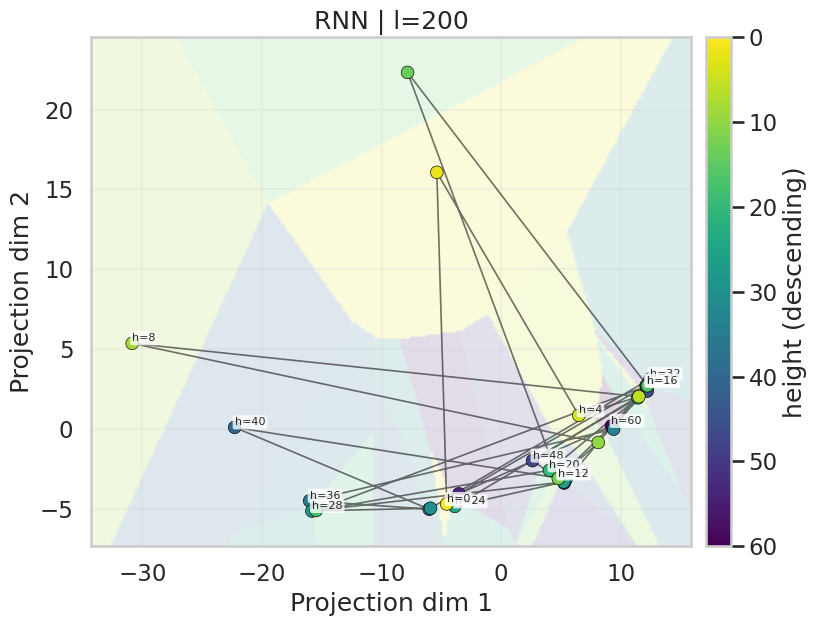

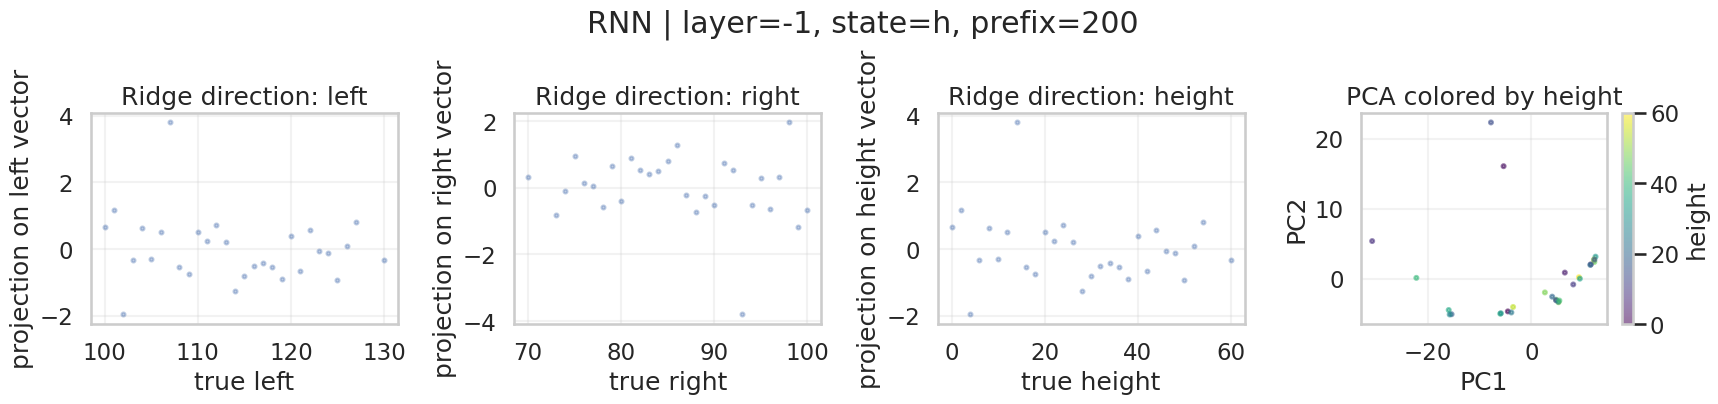

MODEL: lstm
lstm train raw height counts -> 0:1128, 2:2260, 4:2191, 6:2089, 8:1907, 10:1772, 12:1567, 14:1453, 16:1153, 18:970, 20:839, 22:673, 24:538, 26:384, 28:316, 30:237, 32:182, 34:107, 36:90, 38:52, 40:29, 42:28, 44:12, 46:8, 48:7, 50:3, 52:3, 54:2
lstm test raw height counts -> 0:1098, 2:2331, 4:2177, 6:2029, 8:1928, 10:1766, 12:1568, 14:1376, 16:1142, 18:1000, 20:845, 22:681, 24:557, 26:419, 28:308, 30:224, 32:178, 34:114, 36:75, 38:62, 40:43, 42:31, 44:25, 46:9, 48:3, 50:7, 52:2, 54:1, 60:1
lstm train balanced height counts -> 0:2, 2:2, 4:2, 6:2, 8:2, 10:2, 12:2, 14:2, 16:2, 18:2, 20:2, 22:2, 24:2, 26:2, 28:2, 30:2, 32:2, 34:2, 36:2, 38:2, 40:2, 42:2, 44:2, 46:2, 48:2, 50:2, 52:2, 54:2
lstm test balanced height counts -> 0:1, 2:1, 4:1, 6:1, 8:1, 10:1, 12:1, 14:1, 16:1, 18:1, 20:1, 22:1, 24:1, 26:1, 28:1, 30:1, 32:1, 34:1, 36:1, 38:1, 40:1, 42:1, 44:1, 46:1, 48:1, 50:1, 52:1, 54:1, 60:1
   ridge       left        r2: 0.9376
   ridge       left       mae: 1.8070
   ridge      r

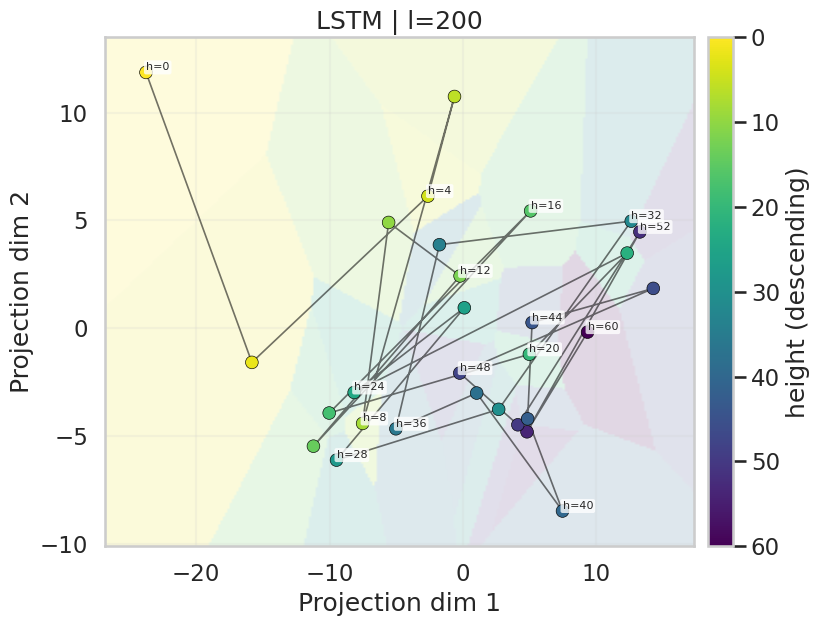

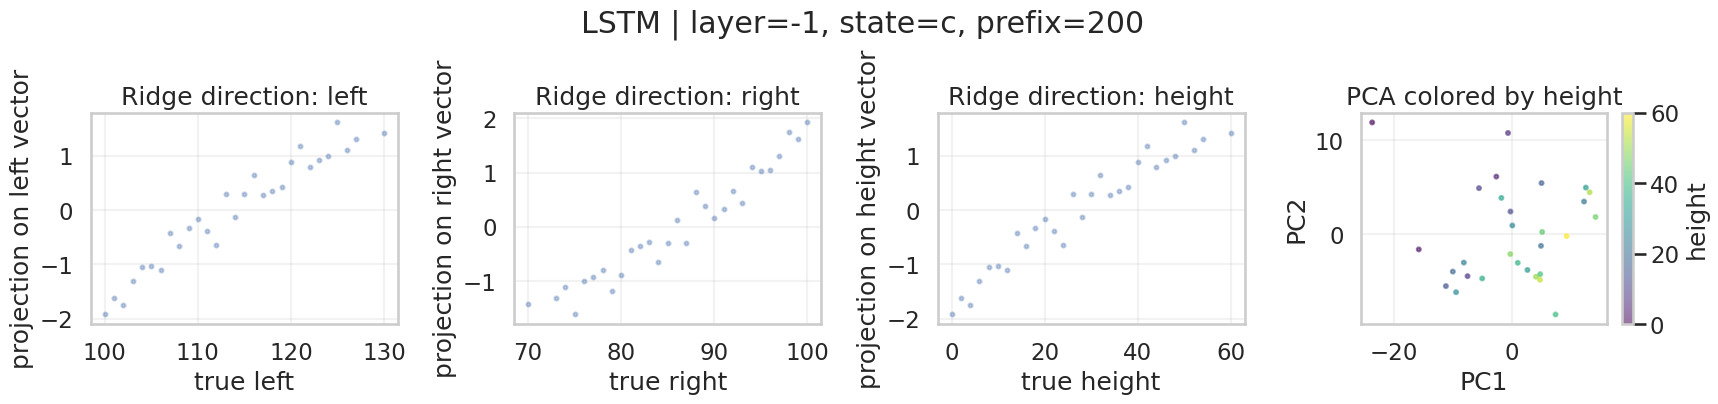

MODEL: transformer
transformer train raw height counts -> 0:1128, 2:2260, 4:2191, 6:2089, 8:1907, 10:1772, 12:1567, 14:1453, 16:1153, 18:970, 20:839, 22:673, 24:538, 26:384, 28:316, 30:237, 32:182, 34:107, 36:90, 38:52, 40:29, 42:28, 44:12, 46:8, 48:7, 50:3, 52:3, 54:2
transformer test raw height counts -> 0:1098, 2:2331, 4:2177, 6:2029, 8:1928, 10:1766, 12:1568, 14:1376, 16:1142, 18:1000, 20:845, 22:681, 24:557, 26:419, 28:308, 30:224, 32:178, 34:114, 36:75, 38:62, 40:43, 42:31, 44:25, 46:9, 48:3, 50:7, 52:2, 54:1, 60:1
transformer train balanced height counts -> 0:2, 2:2, 4:2, 6:2, 8:2, 10:2, 12:2, 14:2, 16:2, 18:2, 20:2, 22:2, 24:2, 26:2, 28:2, 30:2, 32:2, 34:2, 36:2, 38:2, 40:2, 42:2, 44:2, 46:2, 48:2, 50:2, 52:2, 54:2
transformer test balanced height counts -> 0:1, 2:1, 4:1, 6:1, 8:1, 10:1, 12:1, 14:1, 16:1, 18:1, 20:1, 22:1, 24:1, 26:1, 28:1, 30:1, 32:1, 34:1, 36:1, 38:1, 40:1, 42:1, 44:1, 46:1, 48:1, 50:1, 52:1, 54:1, 60:1
   ridge       left        r2: 0.9995
   ridge       lef

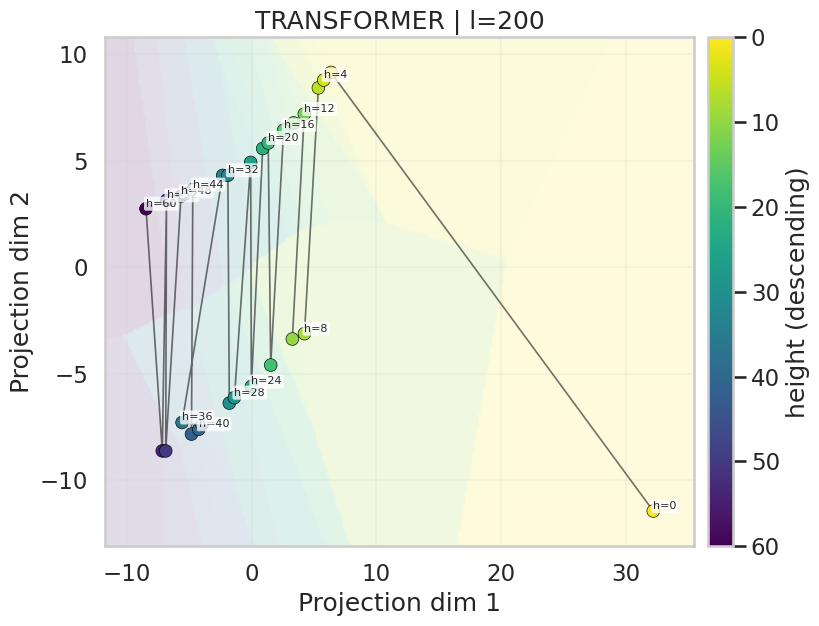

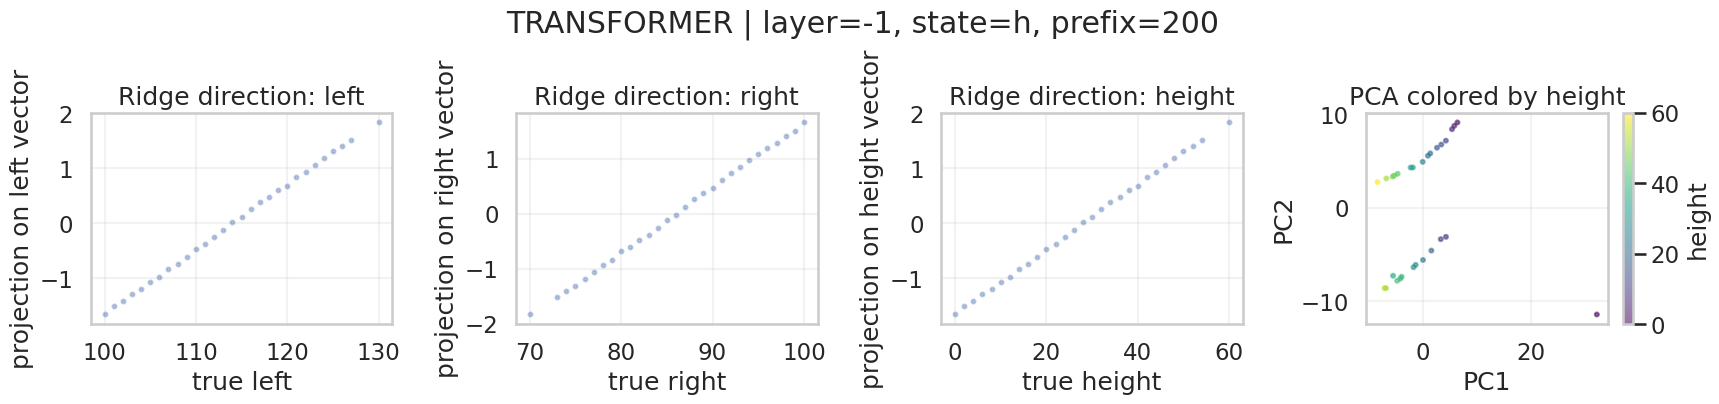

MODEL: mamba
mamba train raw height counts -> 0:1128, 2:2260, 4:2191, 6:2089, 8:1907, 10:1772, 12:1567, 14:1453, 16:1153, 18:970, 20:839, 22:673, 24:538, 26:384, 28:316, 30:237, 32:182, 34:107, 36:90, 38:52, 40:29, 42:28, 44:12, 46:8, 48:7, 50:3, 52:3, 54:2
mamba test raw height counts -> 0:1098, 2:2331, 4:2177, 6:2029, 8:1928, 10:1766, 12:1568, 14:1376, 16:1142, 18:1000, 20:845, 22:681, 24:557, 26:419, 28:308, 30:224, 32:178, 34:114, 36:75, 38:62, 40:43, 42:31, 44:25, 46:9, 48:3, 50:7, 52:2, 54:1, 60:1
mamba train balanced height counts -> 0:2, 2:2, 4:2, 6:2, 8:2, 10:2, 12:2, 14:2, 16:2, 18:2, 20:2, 22:2, 24:2, 26:2, 28:2, 30:2, 32:2, 34:2, 36:2, 38:2, 40:2, 42:2, 44:2, 46:2, 48:2, 50:2, 52:2, 54:2
mamba test balanced height counts -> 0:1, 2:1, 4:1, 6:1, 8:1, 10:1, 12:1, 14:1, 16:1, 18:1, 20:1, 22:1, 24:1, 26:1, 28:1, 30:1, 32:1, 34:1, 36:1, 38:1, 40:1, 42:1, 44:1, 46:1, 48:1, 50:1, 52:1, 54:1, 60:1
   ridge       left        r2: 0.7698
   ridge       left       mae: 2.6011
   ridge  

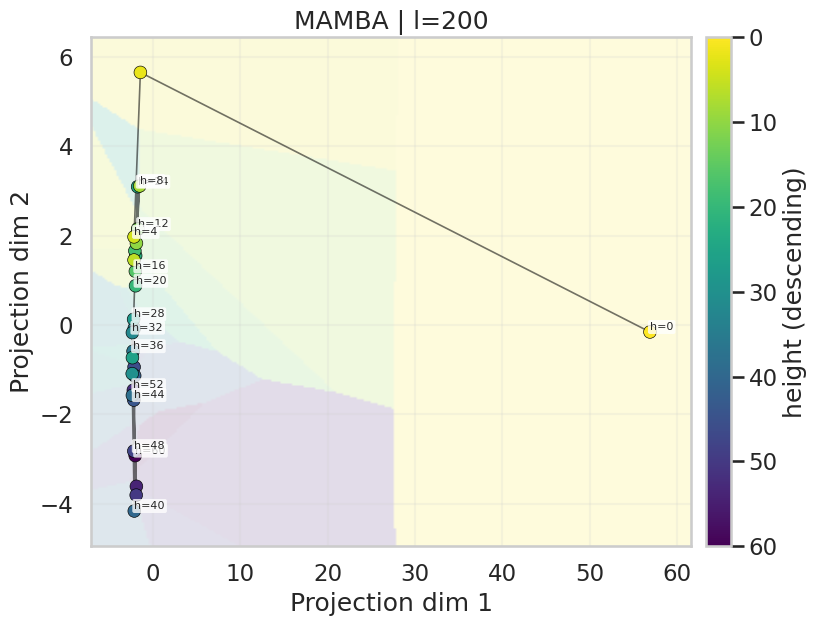

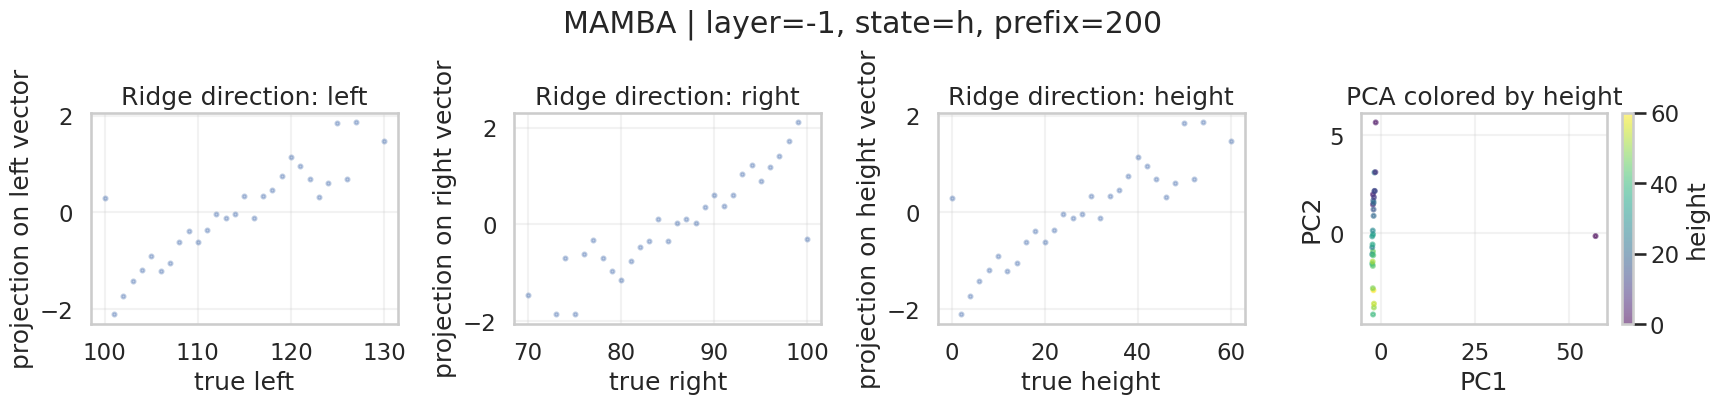

In [59]:
all_results = {}

for model_type in MODEL_TYPES:
    print("=" * 80)
    print(f"MODEL: {model_type}")
    payload = loaded_models[model_type]
    model = payload["model"]
    state_kind = STATE_KIND_BY_MODEL[model_type]

    train_data = sample_hidden_count_matrix(
        model,
        make_sampler(seed_offset=300),
        prefix_length=PREFIX_LENGTH,
        layer_index=LAYER_INDEX,
        state_kind=state_kind,
        n_samples=N_PROBE_SAMPLES,
    )
    test_data = sample_hidden_count_matrix(
        model,
        make_sampler(seed_offset=400),
        prefix_length=PREFIX_LENGTH,
        layer_index=LAYER_INDEX,
        state_kind=state_kind,
        n_samples=N_PROBE_SAMPLES,
    )

    print_class_balance(train_data, BALANCE_PROBE_BY, name=f"{model_type} train raw")
    print_class_balance(test_data, BALANCE_PROBE_BY, name=f"{model_type} test raw")
    train_probe_data = balance_data_by_label(train_data, BALANCE_PROBE_BY, seed=BALANCE_SEED)
    test_probe_data = balance_data_by_label(test_data, BALANCE_PROBE_BY, seed=BALANCE_SEED + 1)
    print_class_balance(train_probe_data, BALANCE_PROBE_BY, name=f"{model_type} train balanced")
    print_class_balance(test_probe_data, BALANCE_PROBE_BY, name=f"{model_type} test balanced")

    rows, fitted = run_counting_probes(train_probe_data, test_probe_data)
    all_results[model_type] = {
        "rows": rows,
        "fitted": fitted,
        "train_data": train_data,
        "test_data": test_data,
        "train_probe_data": train_probe_data,
        "test_probe_data": test_probe_data,
    }

    for row in rows:
        print(f"{row['probe']:>8s} {row['target']:>10s} {row['metric']:>9s}: {row['value']:.4f}")

    summarize_counting_directions(fitted)
    plot_prefix_scatter_by_count_pair(
        test_probe_data,
        title=f"{model_type.upper()} | l={PREFIX_LENGTH}",
        open_token=make_sampler(seed_offset=0).config.open_token,
    )
    plot_counting_projection(
        test_probe_data,
        fitted,
        title=f"{model_type.upper()} | layer={LAYER_INDEX}, state={state_kind}, prefix={PREFIX_LENGTH}",
    )

## 8. Prefix Sweep

Repeat the prefix probe over many prefix lengths instead of only one fixed location. The goal is to check whether the counting direction is stable across the long sequence rather than being a special feature of a single prefix position.


PREFIX SWEEP: rnn
rnn prefix=20
rnn prefix=40
rnn prefix=60
rnn prefix=80
rnn prefix=100
rnn prefix=120
rnn prefix=140


/home/hp_twist_shan/miniforge3/envs/hse/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/hp_twist_shan/miniforge3/envs/hse/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


rnn prefix=160


/home/hp_twist_shan/miniforge3/envs/hse/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/hp_twist_shan/miniforge3/envs/hse/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


rnn prefix=180


...

mamba prefix=300


/home/hp_twist_shan/miniforge3/envs/hse/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/hp_twist_shan/miniforge3/envs/hse/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


mamba prefix=320


/home/hp_twist_shan/miniforge3/envs/hse/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/hp_twist_shan/miniforge3/envs/hse/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


mamba prefix=340
mamba prefix=360
mamba prefix=380


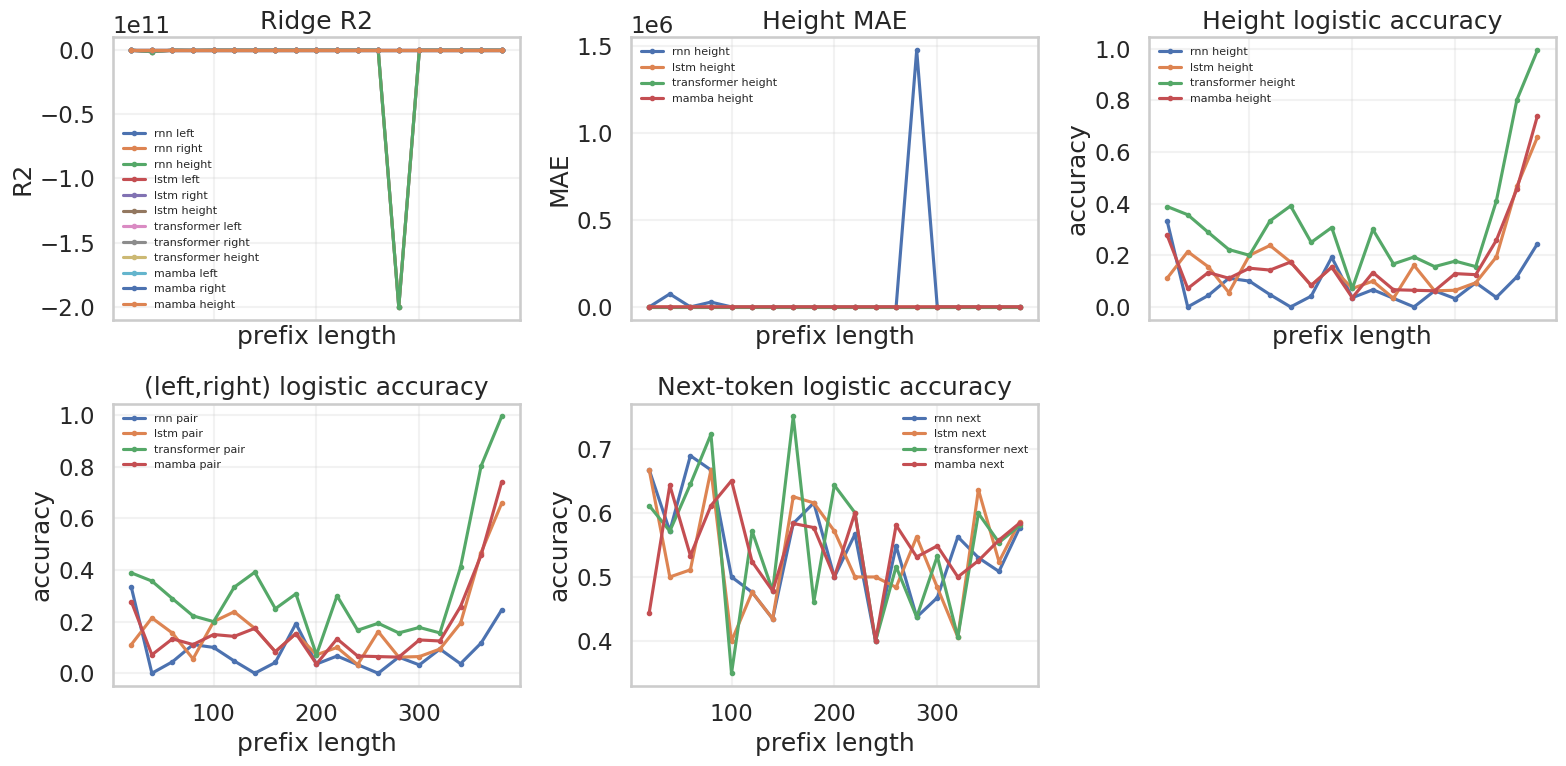

In [60]:
def _rows_to_lookup(rows):
    lookup = {}
    for row in rows:
        lookup[(row["probe"], row["target"], row["metric"])] = row["value"]
    return lookup


def run_prefix_sweep_for_model(model_type):
    model = loaded_models[model_type]["model"]
    state_kind = STATE_KIND_BY_MODEL[model_type]
    sweep_rows = []
    directions = {}

    for prefix_length in SWEEP_PREFIX_LENGTHS:
        print(f"{model_type} prefix={prefix_length}")
        train_data = sample_hidden_count_matrix(
            model,
            make_sampler(seed_offset=600 + prefix_length),
            prefix_length=prefix_length,
            layer_index=LAYER_INDEX,
            state_kind=state_kind,
            n_samples=SWEEP_N_SAMPLES,
        )
        test_data = sample_hidden_count_matrix(
            model,
            make_sampler(seed_offset=700 + prefix_length),
            prefix_length=prefix_length,
            layer_index=LAYER_INDEX,
            state_kind=state_kind,
            n_samples=SWEEP_N_SAMPLES,
        )
        train_data = balance_data_by_label(train_data, BALANCE_PROBE_BY, seed=BALANCE_SEED)
        test_data = balance_data_by_label(test_data, BALANCE_PROBE_BY, seed=BALANCE_SEED + 1)

        rows, fitted = run_counting_probes(train_data, test_data)
        lookup = _rows_to_lookup(rows)
        row = {"model": model_type, "prefix": prefix_length}
        for target in ["left", "right", "height"]:
            row[f"{target}_r2"] = lookup[("ridge", target, "r2")]
            row[f"{target}_mae"] = lookup[("ridge", target, "mae")]
        row["height_acc"] = lookup[("logistic", "height", "accuracy")]
        row["pair_acc"] = lookup[("logistic", "pair_id", "accuracy")]
        if ("logistic", "next_token", "accuracy") in lookup:
            row["next_acc"] = lookup[("logistic", "next_token", "accuracy")]
        sweep_rows.append(row)

        directions[prefix_length] = {}
        for target in ["left", "right", "height"]:
            w = _ridge_direction(fitted[f"ridge_{target}"])
            directions[prefix_length][target] = w / (np.linalg.norm(w) + 1e-12)
    return sweep_rows, directions


prefix_sweep_results = {}
for model_type in MODEL_TYPES:
    print("=" * 80)
    print(f"PREFIX SWEEP: {model_type}")
    rows, directions = run_prefix_sweep_for_model(model_type)
    prefix_sweep_results[model_type] = {"rows": rows, "directions": directions}


def plot_prefix_sweep(prefix_sweep_results):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
    for model_type, result in prefix_sweep_results.items():
        rows = result["rows"]
        prefixes = np.asarray([r["prefix"] for r in rows])
        for target in ["left", "right", "height"]:
            axes[0, 0].plot(prefixes, [r[f"{target}_r2"] for r in rows], marker="o", ms=3, label=f"{model_type} {target}")
        axes[0, 1].plot(prefixes, [r["height_mae"] for r in rows], marker="o", ms=3, label=f"{model_type} height")
        axes[0, 2].plot(prefixes, [r["height_acc"] for r in rows], marker="o", ms=3, label=f"{model_type} height")
        axes[1, 0].plot(prefixes, [r["pair_acc"] for r in rows], marker="o", ms=3, label=f"{model_type} pair")
        if rows and "next_acc" in rows[0]:
            axes[1, 1].plot(prefixes, [r["next_acc"] for r in rows], marker="o", ms=3, label=f"{model_type} next")

    axes[0, 0].set_title("Ridge R2")
    axes[0, 0].set_ylabel("R2")
    axes[0, 1].set_title("Height MAE")
    axes[0, 1].set_ylabel("MAE")
    axes[0, 2].set_title("Height logistic accuracy")
    axes[0, 2].set_ylabel("accuracy")
    axes[1, 0].set_title("(left,right) logistic accuracy")
    axes[1, 0].set_ylabel("accuracy")
    axes[1, 1].set_title("Next-token logistic accuracy")
    axes[1, 1].set_ylabel("accuracy")
    axes[1, 2].axis("off")

    for ax in axes.ravel():
        ax.set_xlabel("prefix length")
        ax.grid(True, alpha=0.25)
        if ax.has_data():
            ax.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()


plot_prefix_sweep(prefix_sweep_results)

## 9. Direction Arithmetic

Compare the learned probe directions algebraically across prefixes. In particular, this section checks whether the `height` direction behaves like `w_left - w_right`, which is the geometric signature we would expect if the model really encodes a counter-like feature.


RNN
prefix | cos(left,right) | cos(height,left-right) | cos(height,left+right)
    20 | -1.000 | +1.000 | +0.000
    40 | -1.000 | +1.000 | +0.000
    60 | -1.000 | +1.000 | +0.000
    80 | -1.000 | +1.000 | +0.000
   100 | -1.000 | +1.000 | +0.000
   120 | -1.000 | +1.000 | +0.000
   140 | -1.000 | +1.000 | -0.000
   160 | -1.000 | +1.000 | +0.000
   180 | -1.000 | +1.000 | +0.000
   200 | -1.000 | +1.000 | +0.000
   220 | -1.000 | +1.000 | +0.000
   240 | -1.000 | +1.000 | +0.000
   260 | -1.000 | +1.000 | +0.000
   280 | -1.000 | +1.000 | -0.000
   300 | -1.000 | +1.000 | +0.000
   320 | -1.000 | +1.000 | +0.000
   340 | -1.000 | +1.000 | +0.000
   360 | -1.000 | +1.000 | +0.000
   380 | -1.000 | +1.000 | +0.000
LSTM
prefix | cos(left,right) | cos(height,left-right) | cos(height,left+right)
    20 | -1.000 | +1.000 | +0.000
    40 | -1.000 | +1.000 | +0.000
    60 | -1.000 | +1.000 | +0.000
    80 | -1.000 | +1.000 | +0.000
   100 | -1.000 | +1.000 | +0.000
   120 | -1.000 | +1.000 

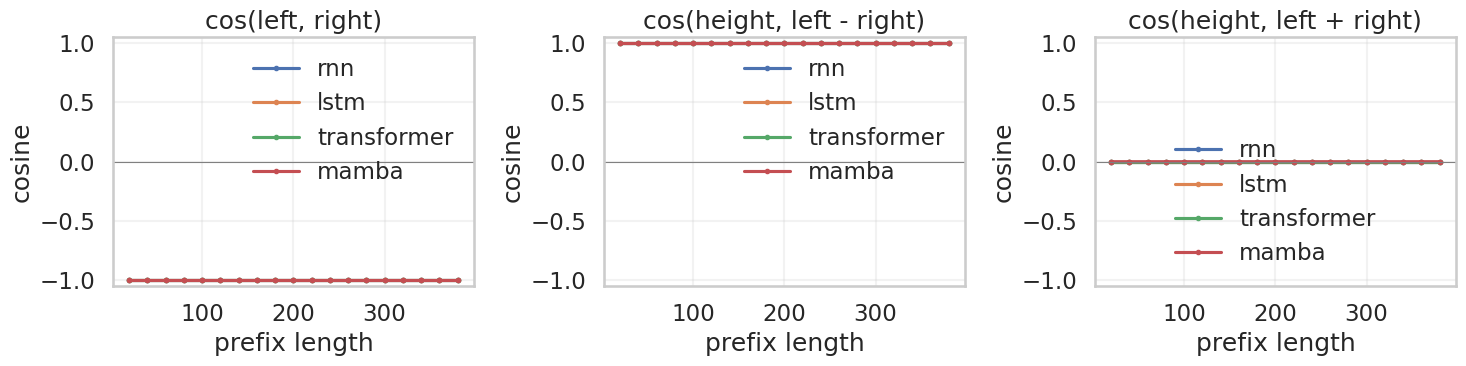

In [61]:
def direction_arithmetic_table(prefix_sweep_results):
    rows = []
    for model_type, result in prefix_sweep_results.items():
        directions = result["directions"]
        for prefix, d in directions.items():
            w_left = d["left"]
            w_right = d["right"]
            w_height = d["height"]
            w_diff = w_left - w_right
            w_sum = w_left + w_right
            w_diff = w_diff / (np.linalg.norm(w_diff) + 1e-12)
            w_sum = w_sum / (np.linalg.norm(w_sum) + 1e-12)
            rows.append({
                "model": model_type,
                "prefix": prefix,
                "cos_left_right": float(np.dot(w_left, w_right)),
                "cos_height_left_minus_right": float(np.dot(w_height, w_diff)),
                "cos_height_left_plus_right": float(np.dot(w_height, w_sum)),
            })
    return rows


direction_arithmetic_rows = direction_arithmetic_table(prefix_sweep_results)

for model_type in MODEL_TYPES:
    print("=" * 80)
    print(model_type.upper())
    rows = [r for r in direction_arithmetic_rows if r["model"] == model_type]
    print("prefix | cos(left,right) | cos(height,left-right) | cos(height,left+right)")
    for r in rows:
        print(
            f"{r['prefix']:>6d} | {r['cos_left_right']:+.3f} | {r['cos_height_left_minus_right']:+.3f} | {r['cos_height_left_plus_right']:+.3f}"
        )


def plot_direction_arithmetic(direction_arithmetic_rows):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
    metrics = [
        ("cos_left_right", "cos(left, right)"),
        ("cos_height_left_minus_right", "cos(height, left - right)"),
        ("cos_height_left_plus_right", "cos(height, left + right)"),
    ]
    for ax, (key, title) in zip(axes, metrics):
        for model_type in MODEL_TYPES:
            rows = [r for r in direction_arithmetic_rows if r["model"] == model_type]
            prefixes = [r["prefix"] for r in rows]
            vals = [r[key] for r in rows]
            ax.plot(prefixes, vals, marker="o", ms=3, label=model_type)
        ax.axhline(0, color="gray", lw=0.8)
        ax.set_title(title)
        ax.set_xlabel("prefix length")
        ax.set_ylabel("cosine")
        ax.set_ylim(-1.05, 1.05)
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


plot_direction_arithmetic(direction_arithmetic_rows)

## 10. Height Linearity Diagnostics

Fix `prefix = 200`, group hidden states by `height`, and study the mean hidden state `μ(h)` for each height class. These diagnostics ask whether the class means lie close to a straight line, a plane, or something more curved by reporting PCA variance, line-fit quality, and local direction consistency.


HEIGHT LINEARITY: rnn | prefix=200
kept height classes (count >= 5): 25
height range kept: 0 .. 50
PC1 explained variance on class means: 0.9100
PC1+PC2 explained variance on class means: 0.9527
line residual fraction: 0.0900
plane residual fraction: 0.0473
height ~ PC1 linear-fit R2: 0.2117
height ~ PC1+PC2 linear-fit R2: 0.2164
corr(height, PC1): 0.4601
step-vs-line cosine: mean=0.1382, min=-0.5675
adjacent-step cosine: mean=-0.2924, min=-0.9448


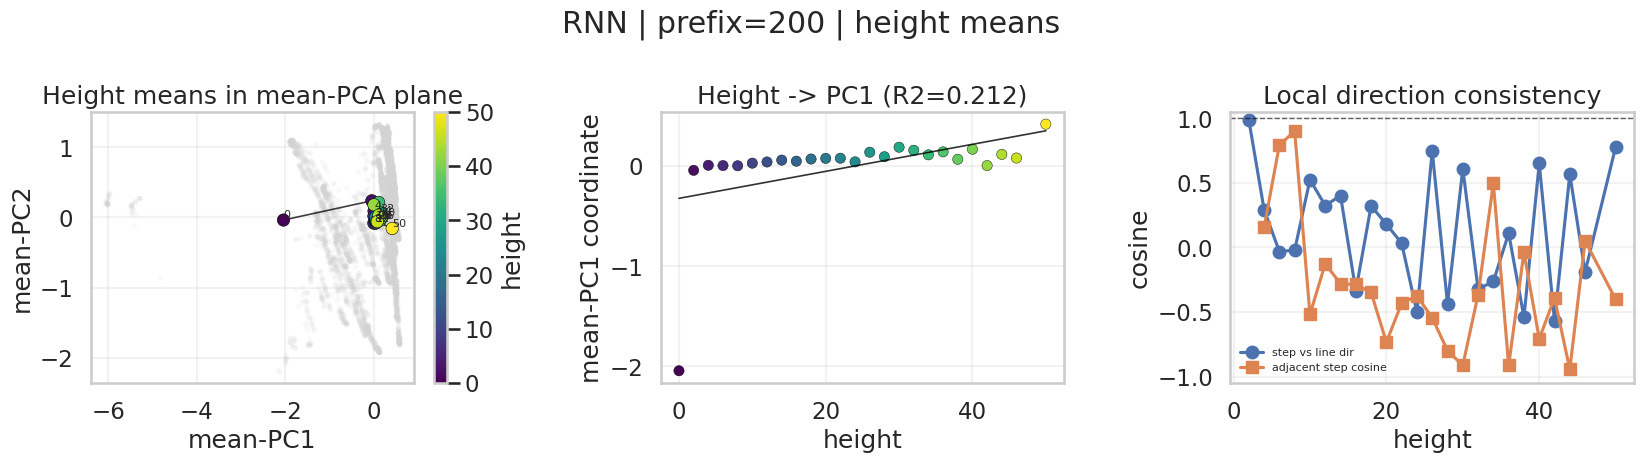

HEIGHT LINEARITY: lstm | prefix=200
kept height classes (count >= 5): 25
height range kept: 0 .. 50
PC1 explained variance on class means: 0.9696
PC1+PC2 explained variance on class means: 0.9972
line residual fraction: 0.0304
plane residual fraction: 0.0028
height ~ PC1 linear-fit R2: 0.8749
height ~ PC1+PC2 linear-fit R2: 0.9750
corr(height, PC1): 0.9353
step-vs-line cosine: mean=0.7687, min=-0.7612
adjacent-step cosine: mean=0.6066, min=-0.9278


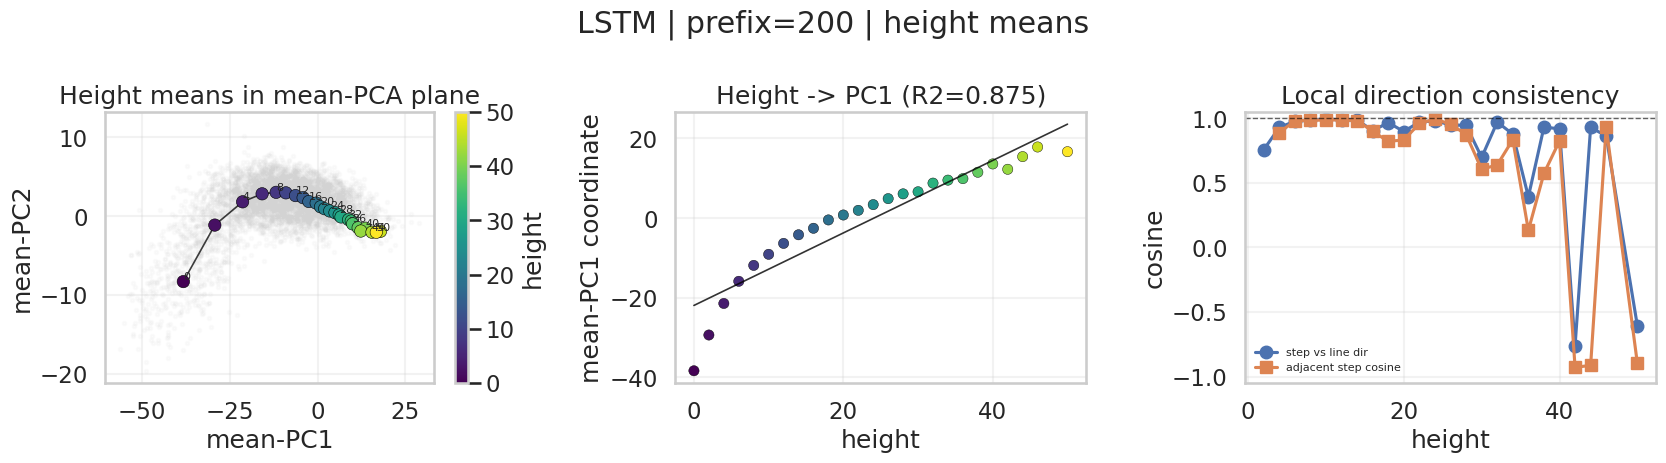

HEIGHT LINEARITY: transformer | prefix=200
kept height classes (count >= 5): 25
height range kept: 0 .. 50
PC1 explained variance on class means: 0.7305
PC1+PC2 explained variance on class means: 0.9856
line residual fraction: 0.2695
plane residual fraction: 0.0144
height ~ PC1 linear-fit R2: 0.7410
height ~ PC1+PC2 linear-fit R2: 0.9984
corr(height, PC1): 0.8608
step-vs-line cosine: mean=0.6363, min=-0.0505
adjacent-step cosine: mean=0.4952, min=-0.9243


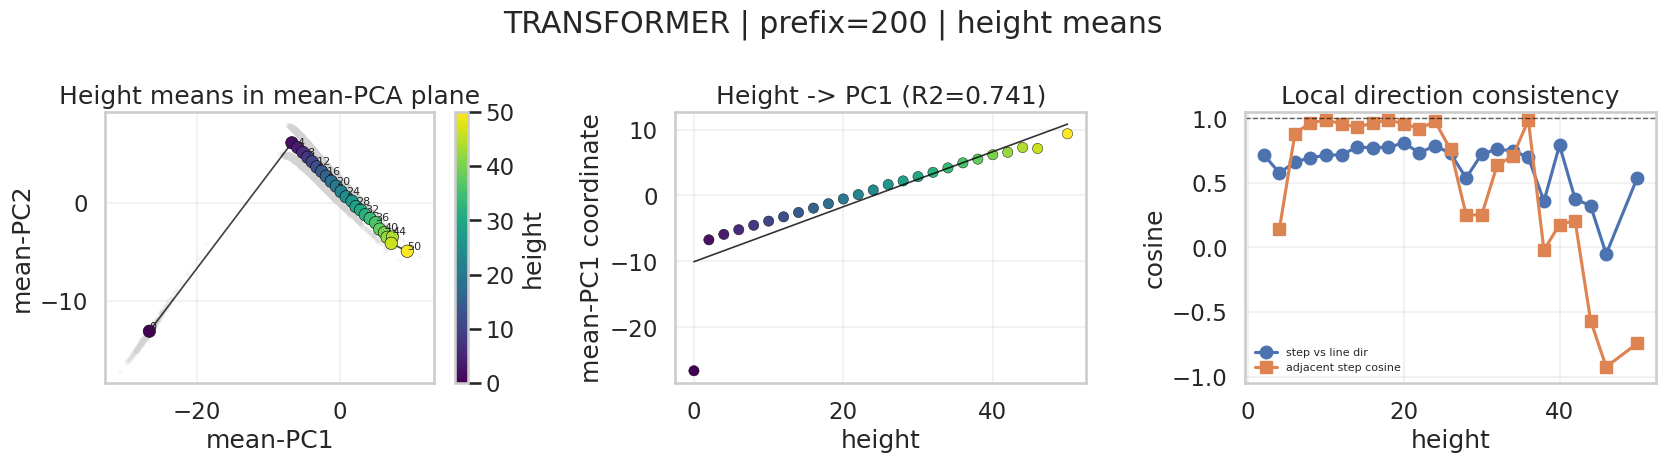

HEIGHT LINEARITY: mamba | prefix=200
kept height classes (count >= 5): 25
height range kept: 0 .. 50
PC1 explained variance on class means: 0.9938
PC1+PC2 explained variance on class means: 0.9990
line residual fraction: 0.0062
plane residual fraction: 0.0010
height ~ PC1 linear-fit R2: 0.1189
height ~ PC1+PC2 linear-fit R2: 0.8178
corr(height, PC1): 0.3448
step-vs-line cosine: mean=0.0597, min=-0.3783
adjacent-step cosine: mean=0.4485, min=-0.8337


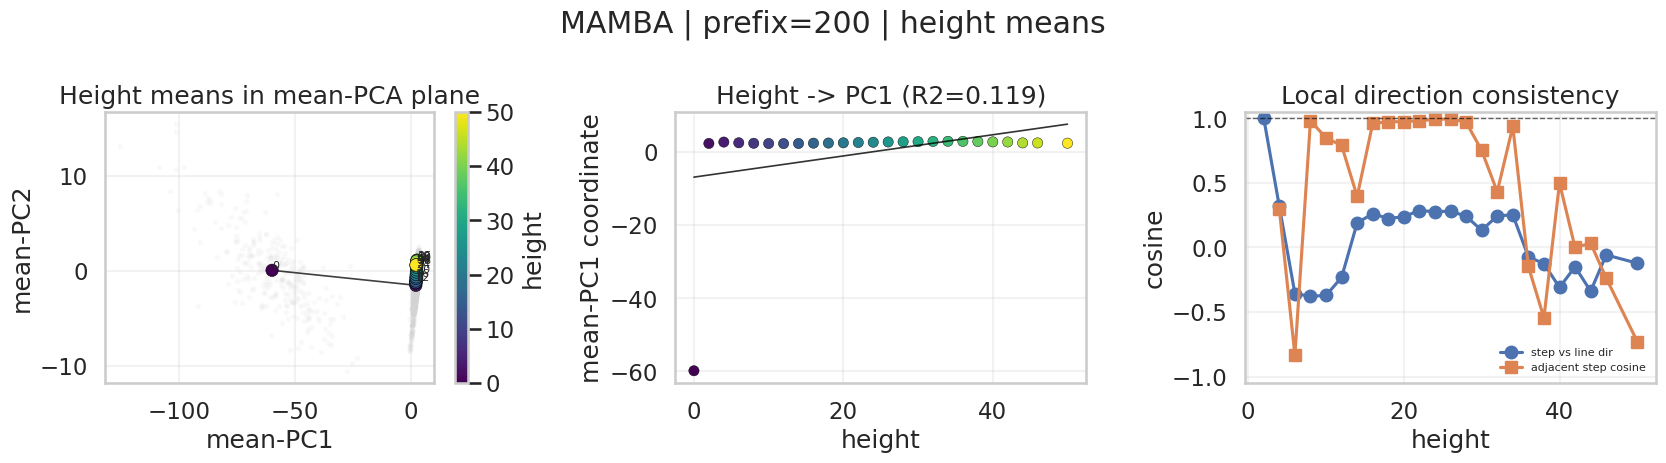

model | n_heights | pc1_var | line_resid | plane_resid | height_pc1_r2 | height_pc12_r2 | step_line_cos | adjacent_step_cos
        rnn |        25 | 0.9100 | 0.0900 | 0.0473 | 0.2117 | 0.2164 | 0.1382 | -0.2924
       lstm |        25 | 0.9696 | 0.0304 | 0.0028 | 0.8749 | 0.9750 | 0.7687 | 0.6066
transformer |        25 | 0.7305 | 0.2695 | 0.0144 | 0.7410 | 0.9984 | 0.6363 | 0.4952
      mamba |        25 | 0.9938 | 0.0062 | 0.0010 | 0.1189 | 0.8178 | 0.0597 | 0.4485


In [62]:
def _linear_fit_r2(features, target):
    features = np.asarray(features, dtype=float)
    target = np.asarray(target, dtype=float)
    if features.ndim == 1:
        features = features[:, None]
    X = np.c_[np.ones(len(target)), features]
    coef, *_ = np.linalg.lstsq(X, target, rcond=None)
    pred = X @ coef
    return float(r2_score(target, pred))


def compute_height_mean_geometry(data, min_count=HEIGHT_GEOMETRY_MIN_COUNT):
    X = np.asarray(data["h"], dtype=float)
    height = np.asarray(data["height"], dtype=int)
    heights, counts = np.unique(height, return_counts=True)
    keep = counts >= int(min_count)
    heights = heights[keep]
    counts = counts[keep]
    if len(heights) < 3:
        raise ValueError("Need at least 3 height classes after min_count filtering.")

    means = np.stack([X[height == h].mean(axis=0) for h in heights], axis=0)
    center = means.mean(axis=0, keepdims=True)
    centered = means - center

    n_components = min(3, len(heights), means.shape[1])
    pca = PCA(n_components=n_components)
    mean_coords = pca.fit_transform(centered)
    line_dir = pca.components_[0].copy()
    pc1 = mean_coords[:, 0].copy()
    corr = np.corrcoef(pc1, heights)[0, 1] if len(heights) > 1 else 1.0
    if np.isnan(corr):
        corr = 0.0
    if corr < 0:
        line_dir *= -1
        mean_coords[:, 0] *= -1
        pc1 *= -1
        corr *= -1

    total_ss = float((centered ** 2).sum())
    proj1 = np.outer(centered @ line_dir, line_dir)
    line_resid_ss = float(((centered - proj1) ** 2).sum())

    if pca.components_.shape[0] >= 2:
        plane_basis = pca.components_[:2]
        proj2 = (centered @ plane_basis.T) @ plane_basis
        plane_resid_ss = float(((centered - proj2) ** 2).sum())
    else:
        plane_resid_ss = 0.0

    steps = means[1:] - means[:-1]
    step_norms = np.linalg.norm(steps, axis=1)
    valid = step_norms > 1e-12
    unit_steps = steps[valid] / step_norms[valid, None]
    tangent_to_line_cos = unit_steps @ line_dir if len(unit_steps) else np.asarray([])
    adjacent_tangent_cos = (
        np.sum(unit_steps[1:] * unit_steps[:-1], axis=1) if len(unit_steps) >= 2 else np.asarray([])
    )

    basis2 = pca.components_[: min(2, pca.components_.shape[0])]
    sample_coords = (X - center) @ basis2.T
    mean_coords_2d = mean_coords[:, : min(2, mean_coords.shape[1])]
    if sample_coords.shape[1] == 1:
        sample_coords = np.c_[sample_coords[:, 0], np.zeros(len(sample_coords))]
        mean_coords_2d = np.c_[mean_coords_2d[:, 0], np.zeros(len(mean_coords_2d))]

    return {
        "heights": heights,
        "counts": counts,
        "means": means,
        "center": center,
        "mean_coords": mean_coords,
        "mean_coords_2d": mean_coords_2d,
        "sample_coords_2d": sample_coords,
        "pc1_var_explained": float(pca.explained_variance_ratio_[0]),
        "pc12_var_explained": float(pca.explained_variance_ratio_[: min(2, len(pca.explained_variance_ratio_))].sum()),
        "line_residual_frac": float(line_resid_ss / total_ss) if total_ss > 0 else 0.0,
        "plane_residual_frac": float(plane_resid_ss / total_ss) if total_ss > 0 else 0.0,
        "height_from_pc1_r2": _linear_fit_r2(pc1, heights),
        "height_from_pc12_r2": _linear_fit_r2(mean_coords[:, : min(2, mean_coords.shape[1])], heights),
        "pc1_height_corr": float(corr),
        "tangent_to_line_cos": tangent_to_line_cos,
        "adjacent_tangent_cos": adjacent_tangent_cos,
        "min_count": int(min_count),
    }


def summarize_height_linearity(diag):
    print(f"kept height classes (count >= {diag['min_count']}): {len(diag['heights'])}")
    print(f"height range kept: {int(diag['heights'][0])} .. {int(diag['heights'][-1])}")
    print(f"PC1 explained variance on class means: {diag['pc1_var_explained']:.4f}")
    print(f"PC1+PC2 explained variance on class means: {diag['pc12_var_explained']:.4f}")
    print(f"line residual fraction: {diag['line_residual_frac']:.4f}")
    print(f"plane residual fraction: {diag['plane_residual_frac']:.4f}")
    print(f"height ~ PC1 linear-fit R2: {diag['height_from_pc1_r2']:.4f}")
    print(f"height ~ PC1+PC2 linear-fit R2: {diag['height_from_pc12_r2']:.4f}")
    print(f"corr(height, PC1): {diag['pc1_height_corr']:.4f}")
    if len(diag['tangent_to_line_cos']):
        print(
            "step-vs-line cosine: "
            f"mean={diag['tangent_to_line_cos'].mean():.4f}, "
            f"min={diag['tangent_to_line_cos'].min():.4f}"
        )
    if len(diag['adjacent_tangent_cos']):
        print(
            "adjacent-step cosine: "
            f"mean={diag['adjacent_tangent_cos'].mean():.4f}, "
            f"min={diag['adjacent_tangent_cos'].min():.4f}"
        )


def plot_height_mean_geometry(diag, *, title, max_points=HEIGHT_GEOMETRY_PLOT_POINTS):
    rng = np.random.default_rng(0)
    sample_coords = diag['sample_coords_2d']
    if len(sample_coords) > max_points:
        idx = rng.choice(len(sample_coords), size=max_points, replace=False)
        sample_coords = sample_coords[idx]

    mean_coords = diag['mean_coords_2d']
    heights = diag['heights']
    pc1 = diag['mean_coords'][:, 0]
    x_line = np.linspace(heights.min(), heights.max(), 200)
    coef = np.polyfit(heights, pc1, deg=1)
    pc1_fit = np.poly1d(coef)

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

    axes[0].scatter(sample_coords[:, 0], sample_coords[:, 1], s=6, alpha=0.08, color='lightgray')
    sc = axes[0].scatter(
        mean_coords[:, 0], mean_coords[:, 1], c=heights, cmap='viridis', s=80,
        edgecolors='black', linewidths=0.4, zorder=3,
    )
    axes[0].plot(mean_coords[:, 0], mean_coords[:, 1], color='black', lw=1.2, alpha=0.75)
    label_every = max(1, len(heights) // 12)
    for i, (x, y, h) in enumerate(zip(mean_coords[:, 0], mean_coords[:, 1], heights)):
        if i % label_every == 0 or i == len(heights) - 1:
            axes[0].text(x, y, f'{int(h)}', fontsize=8, ha='left', va='bottom')
    axes[0].set_title('Height means in mean-PCA plane')
    axes[0].set_xlabel('mean-PC1')
    axes[0].set_ylabel('mean-PC2')
    axes[0].grid(True, alpha=0.25)
    fig.colorbar(sc, ax=axes[0], label='height')

    axes[1].scatter(heights, pc1, c=heights, cmap='viridis', s=55, edgecolors='black', linewidths=0.3)
    axes[1].plot(x_line, pc1_fit(x_line), color='black', lw=1.2, alpha=0.8)
    axes[1].set_title(f'Height -> PC1 (R2={diag["height_from_pc1_r2"]:.3f})')
    axes[1].set_xlabel('height')
    axes[1].set_ylabel('mean-PC1 coordinate')
    axes[1].grid(True, alpha=0.25)

    step_heights = heights[1:]
    if len(diag['tangent_to_line_cos']):
        axes[2].plot(step_heights[: len(diag['tangent_to_line_cos'])], diag['tangent_to_line_cos'], marker='o', label='step vs line dir')
    if len(diag['adjacent_tangent_cos']):
        axes[2].plot(heights[2: 2 + len(diag['adjacent_tangent_cos'])], diag['adjacent_tangent_cos'], marker='s', label='adjacent step cosine')
    axes[2].axhline(1.0, color='black', lw=1.0, linestyle='--', alpha=0.6)
    axes[2].set_ylim(-1.05, 1.05)
    axes[2].set_title('Local direction consistency')
    axes[2].set_xlabel('height')
    axes[2].set_ylabel('cosine')
    axes[2].grid(True, alpha=0.25)
    axes[2].legend(frameon=False, fontsize=8)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def collect_height_linearity_rows(results):
    rows = []
    for model_type, diag in results.items():
        rows.append({
            'model': model_type,
            'n_heights': int(len(diag['heights'])),
            'pc1_var': diag['pc1_var_explained'],
            'line_resid': diag['line_residual_frac'],
            'plane_resid': diag['plane_residual_frac'],
            'height_pc1_r2': diag['height_from_pc1_r2'],
            'height_pc12_r2': diag['height_from_pc12_r2'],
            'step_line_cos_mean': float(diag['tangent_to_line_cos'].mean()) if len(diag['tangent_to_line_cos']) else float('nan'),
            'adjacent_step_cos_mean': float(diag['adjacent_tangent_cos'].mean()) if len(diag['adjacent_tangent_cos']) else float('nan'),
        })
    return rows


height_linearity_results = {}
for model_type in MODEL_TYPES:
    print('=' * 80)
    print(f'HEIGHT LINEARITY: {model_type} | prefix={PREFIX_LENGTH}')
    diag = compute_height_mean_geometry(all_results[model_type]['test_data'])
    height_linearity_results[model_type] = diag
    summarize_height_linearity(diag)
    plot_height_mean_geometry(diag, title=f'{model_type.upper()} | prefix={PREFIX_LENGTH} | height means')


height_linearity_rows = collect_height_linearity_rows(height_linearity_results)
print('=' * 80)
print('model | n_heights | pc1_var | line_resid | plane_resid | height_pc1_r2 | height_pc12_r2 | step_line_cos | adjacent_step_cos')
for row in height_linearity_rows:
    print(
        f"{row['model']:>11s} | {row['n_heights']:>9d} | {row['pc1_var']:.4f} | {row['line_resid']:.4f} | "
        f"{row['plane_resid']:.4f} | {row['height_pc1_r2']:.4f} | {row['height_pc12_r2']:.4f} | "
        f"{row['step_line_cos_mean']:.4f} | {row['adjacent_step_cos_mean']:.4f}"
    )


1. 左图 `Height means in mean-PCA plane`
   - 先对每个高度 `h` 取平均隐藏状态：`μ(h) = mean{x_i : height_i = h}`。
   - 对这些 `μ(h)` 做 PCA，只在这些类均值上做。
   - 灰点是所有样本 hidden state 投到这个“由类均值定义出来的前两主成分平面”里。
   - 彩色点是每个 `μ(h)` 的位置，颜色表示高度，黑线按高度顺序把这些均值连起来。

2. 中图 `Height -> PC1`
   - 横轴是 `height`，纵轴是对应类均值 `μ(h)` 在第一主成分上的坐标。
   - 标题里的 `R²` 是“用 PC1 线性预测 height”的拟合优度。
   - 如果这个值高，说明“高度”大致可以沿一个单一方向来读出。
   - 黑线只是视觉上的线性趋势线，帮你看单调性和偏离程度。

3. 右图 `Local direction consistency`
   - 先看相邻高度均值之间的步长：`Δ_h = μ(h+1) - μ(h)`。
   - 蓝线 `step vs line dir cosine`：每一步 `Δ_h` 和全局主方向 `PC1` 的 cosine。
   - 橙线 `adjacent step cosine`：相邻两步 `Δ_h`、`Δ_{h+1}` 彼此之间的 cosine。
   - 如果两条线都接近 `1`，说明轨迹局部方向很稳定，很像一条直线。
   - 如果掉到 `0` 附近甚至负数，说明轨迹在转弯，甚至回头。

- 看左图：先判断 `μ(h)` 连起来像不像一条细长轨迹。
- 看中图：再判断“高度能不能主要靠一个轴解释”。
- 看右图：最后判断这条轨迹是不是局部方向稳定，还是只是投影后看起来像线。

- `RNN`
  - 左图里大部分高度均值挤在一起，只有少数点被拉出去，整体不像干净的线或平滑曲线。
  - 中图 `R²=0.212` 很低，说明单一 PC1 解释 height 很差。
  - 右图抖动很大，很多地方 cosine 接近 0 或变负，局部方向不稳定。

- `LSTM`
  - 左图很明显是一条弯曲轨迹，前半段弯得更厉害，后半段比较顺。
  - 中图 `R²=0.875` 很高，说明大部分 height 信息确实能沿一个主轴读出来，但不是完美直线。
  - 右图在大部分高度上接近 `1`，说明中段局部方向非常稳定；但尾部掉到负数，说明端点在回折。

- `Transformer`
  - 左图主体几乎是一条斜线，但 `h=0` 那个端点被单独甩出去，形成一条很长的跳线。
  - 中图 `R²=0.741` 略低，是因为第一个点影响太大。
  - 右图中段相当稳定，尾部尤其低高度端开始明显转弯。

- `Mamba`
  - 左图几乎所有高度都堆在一小团附近，只有一个巨大离群点。
  - 中图 `R²=0.119` 很低，说明 PC1 基本没法稳定解释 height。
  - 右图里橙线有时很高，表示局部几步方向可能相似，但蓝线整体不高，说明这些局部方向并不对齐到同一个全局轴。

## 11. Searching For A Curved 1D Manifold

Search for a curved `1D` manifold in the hidden states after fixing the long prefix. This section builds a low-dimensional PCA subspace from the height means, fits an ordered curve through those means, projects real samples onto that curve, and compares `1D line`, `1D curve`, and `2D plane` explanations of the representation.


MANIFOLD SEARCH: rnn | prefix=200
kept heights: 25 classes | range 0 .. 50
mean-PCA variance ratios: 0.9100, 0.0427, 0.0320, 0.0099, 0.0024, 0.0012
sample RMSE  | line=1.2289, curve=1.2278, plane=0.9272
mean RMSE    | line=0.1327, curve=0.0000, plane=0.0953
height R2    | line=0.0473, curve=0.0415, plane=0.0511
curve stats  | length=5.2780, mean-path=4.9895, monotone=True


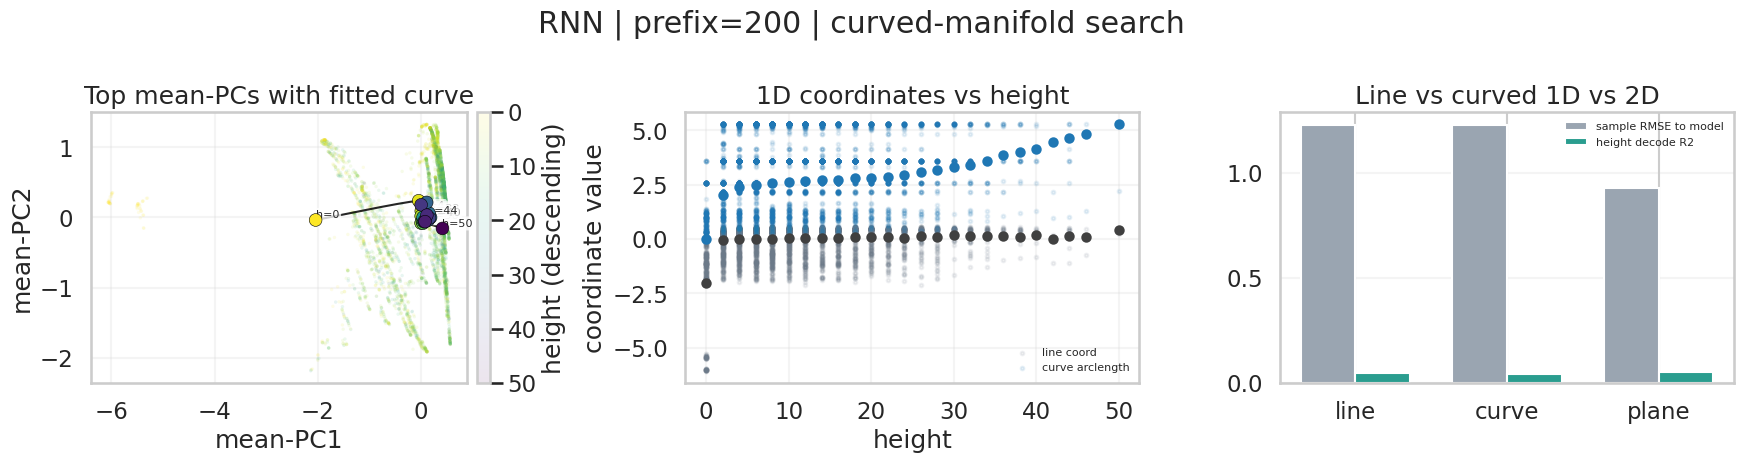

MANIFOLD SEARCH: lstm | prefix=200
kept heights: 25 classes | range 0 .. 50
mean-PCA variance ratios: 0.9696, 0.0275, 0.0017, 0.0008, 0.0002, 0.0001
sample RMSE  | line=6.7949, curve=6.3698, plane=5.6253
mean RMSE    | line=2.5046, curve=0.0000, plane=0.7549
height R2    | line=0.6344, curve=0.6614, plane=0.6939
curve stats  | length=67.6978, mean-path=67.2250, monotone=True


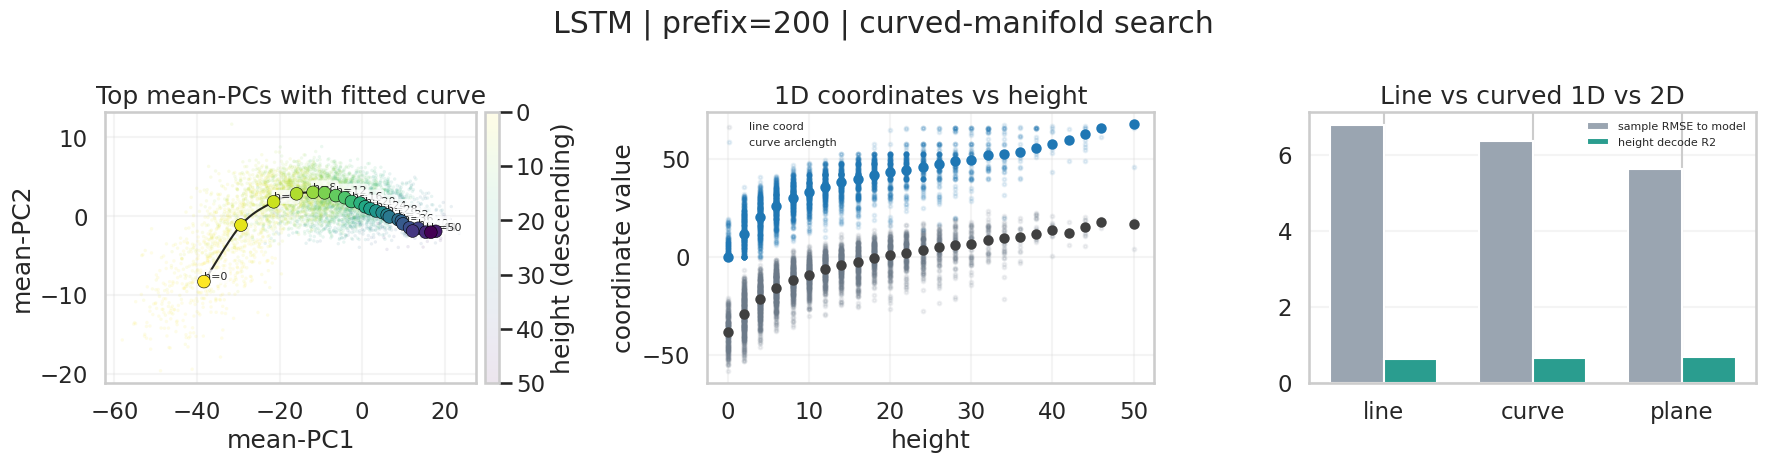

MANIFOLD SEARCH: transformer | prefix=200
kept heights: 25 classes | range 0 .. 50
mean-PCA variance ratios: 0.7305, 0.2551, 0.0085, 0.0044, 0.0010, 0.0002
sample RMSE  | line=7.3447, curve=5.0777, plane=5.1340
mean RMSE    | line=4.2913, curve=0.0000, plane=0.9839
height R2    | line=0.5048, curve=0.5519, plane=0.9599
curve stats  | length=60.3558, mean-path=56.8601, monotone=True


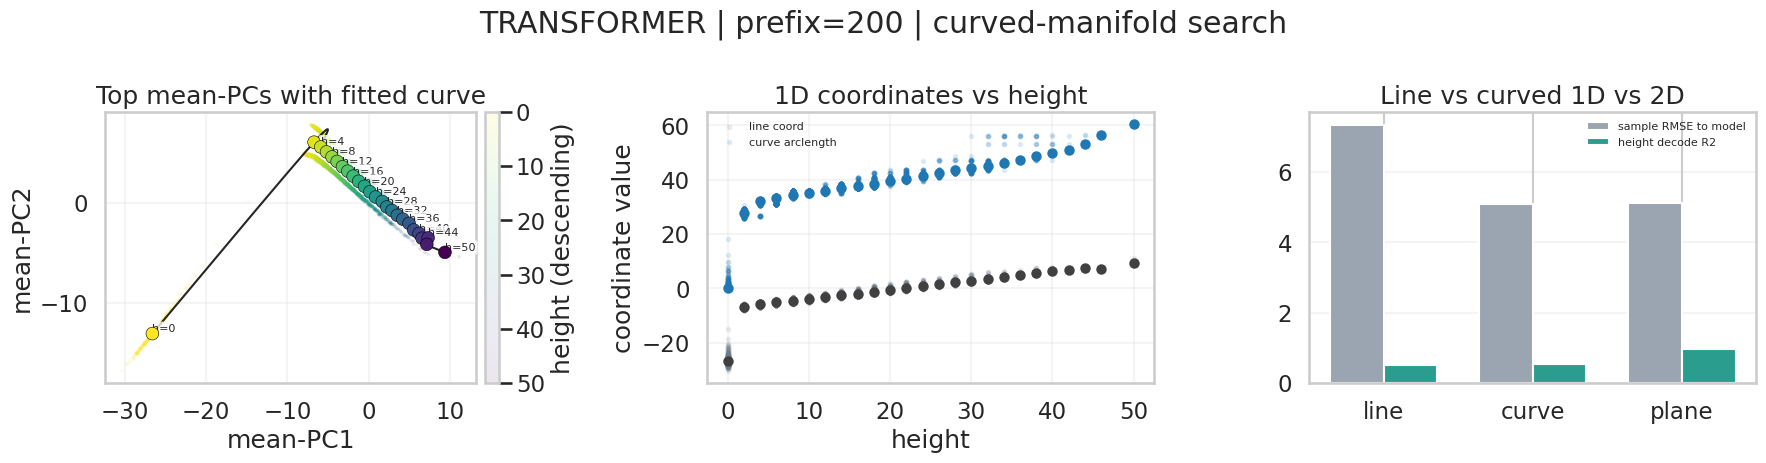

MANIFOLD SEARCH: mamba | prefix=200
kept heights: 25 classes | range 0 .. 50
mean-PCA variance ratios: 0.9938, 0.0052, 0.0008, 0.0002, 0.0000, 0.0000
sample RMSE  | line=2.3299, curve=3.3651, plane=1.3564
mean RMSE    | line=0.9646, curve=0.0000, plane=0.3937
height R2    | line=0.0968, curve=0.1613, plane=0.1846
curve stats  | length=77.5580, mean-path=69.3093, monotone=True


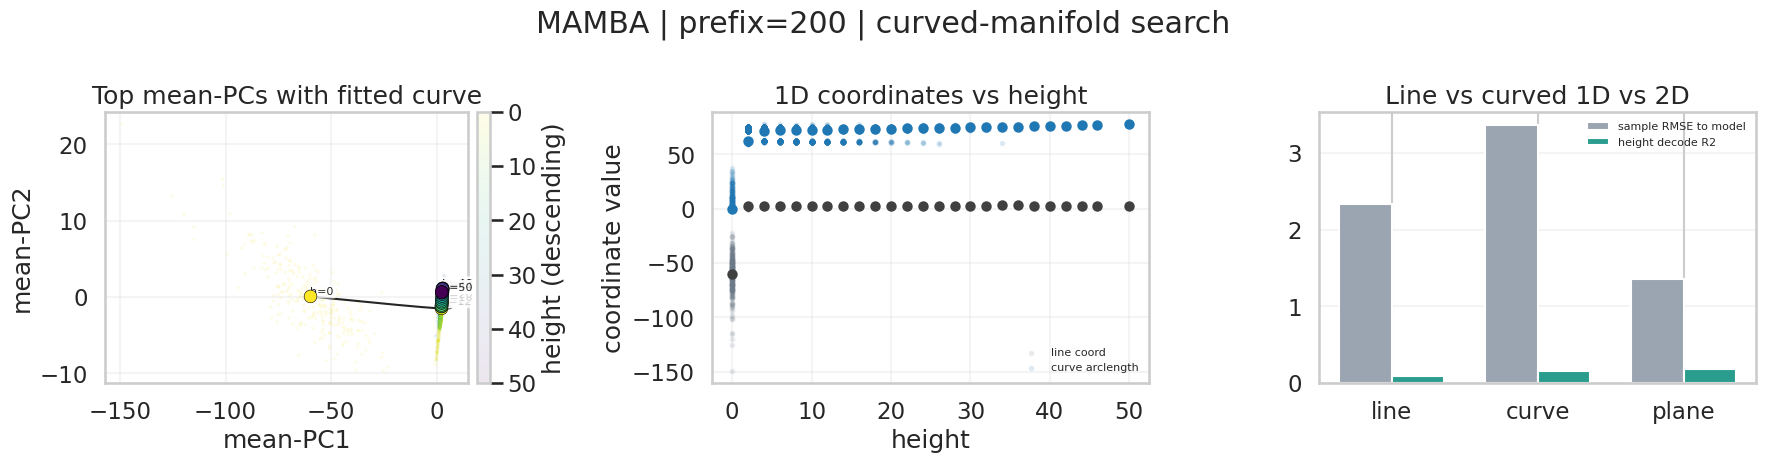

model | n_heights | subspace_dim | line_rmse | curve_rmse | plane_rmse | line_r2 | curve_r2 | plane_r2 | curve_monotone
        rnn |        25 |            6 | 1.2289 | 1.2278 | 0.9272 | 0.0473 | 0.0415 | 0.0511 | True
       lstm |        25 |            6 | 6.7949 | 6.3698 | 5.6253 | 0.6344 | 0.6614 | 0.6939 | True
transformer |        25 |            6 | 7.3447 | 5.0777 | 5.1340 | 0.5048 | 0.5519 | 0.9599 | True
      mamba |        25 |            6 | 2.3299 | 3.3651 | 1.3564 | 0.0968 | 0.1613 | 0.1846 | True


In [63]:
def _fit_linear_readout_r2(features, target):
    features = np.asarray(features, dtype=float)
    target = np.asarray(target, dtype=float)
    if features.ndim == 1:
        features = features[:, None]
    X = np.c_[np.ones(len(target)), features]
    coef, *_ = np.linalg.lstsq(X, target, rcond=None)
    pred = X @ coef
    return float(r2_score(target, pred))


def _catmull_rom_curve(points, samples_per_seg=None):
    if samples_per_seg is None:
        samples_per_seg = globals().get('MANIFOLD_CURVE_SAMPLES_PER_SEG', 40)
    points = np.asarray(points, dtype=float)
    if len(points) < 2:
        return points.copy()
    ext = np.vstack([points[0], points, points[-1]])
    curve = []
    for i in range(1, len(ext) - 2):
        p0, p1, p2, p3 = ext[i - 1], ext[i], ext[i + 1], ext[i + 2]
        m1 = 0.5 * (p2 - p0)
        m2 = 0.5 * (p3 - p1)
        ts = np.linspace(0.0, 1.0, int(samples_per_seg), endpoint=False)
        for t in ts:
            t2 = t * t
            t3 = t2 * t
            h00 = 2 * t3 - 3 * t2 + 1
            h10 = t3 - 2 * t2 + t
            h01 = -2 * t3 + 3 * t2
            h11 = t3 - t2
            curve.append(h00 * p1 + h10 * m1 + h01 * p2 + h11 * m2)
    curve.append(points[-1])
    return np.asarray(curve, dtype=float)


def _curve_arclength(curve_points):
    curve_points = np.asarray(curve_points, dtype=float)
    if len(curve_points) == 0:
        return np.asarray([], dtype=float)
    if len(curve_points) == 1:
        return np.asarray([0.0], dtype=float)
    steps = np.linalg.norm(curve_points[1:] - curve_points[:-1], axis=1)
    return np.concatenate([[0.0], np.cumsum(steps)])


def _project_points_to_curve(points, curve_points, curve_s, batch_size=None):
    if batch_size is None:
        batch_size = globals().get('MANIFOLD_PROJECTION_BATCH', 512)
    points = np.asarray(points, dtype=float)
    curve_points = np.asarray(curve_points, dtype=float)
    curve_s = np.asarray(curve_s, dtype=float)
    n = len(points)
    nearest_idx = np.zeros(n, dtype=int)
    nearest_sq = np.zeros(n, dtype=float)
    nearest_s = np.zeros(n, dtype=float)
    batch_size = int(batch_size)
    for start in range(0, n, batch_size):
        stop = min(start + batch_size, n)
        block = points[start:stop]
        sq = ((block[:, None, :] - curve_points[None, :, :]) ** 2).sum(axis=2)
        idx = sq.argmin(axis=1)
        nearest_idx[start:stop] = idx
        nearest_sq[start:stop] = sq[np.arange(len(block)), idx]
        nearest_s[start:stop] = curve_s[idx]
    return nearest_idx, nearest_sq, nearest_s


def compute_height_manifold_search(
    data,
    *,
    min_count=None,
    subspace_dim=None,
    samples_per_seg=None,
):
    if min_count is None:
        min_count = globals().get('HEIGHT_GEOMETRY_MIN_COUNT', 5)
    if subspace_dim is None:
        subspace_dim = globals().get('MANIFOLD_SUBSPACE_DIM', 6)
    if samples_per_seg is None:
        samples_per_seg = globals().get('MANIFOLD_CURVE_SAMPLES_PER_SEG', 40)
    X = np.asarray(data['h'], dtype=float)
    height = np.asarray(data['height'], dtype=int)
    heights, counts = np.unique(height, return_counts=True)
    keep = counts >= int(min_count)
    heights = heights[keep]
    counts = counts[keep]
    if len(heights) < 4:
        raise ValueError('Need at least 4 height classes after min_count filtering.')

    keep_mask = np.isin(height, heights)
    X = X[keep_mask]
    sample_height = height[keep_mask]
    means = np.stack([X[sample_height == h].mean(axis=0) for h in heights], axis=0)
    center = means.mean(axis=0, keepdims=True)
    mean_centered = means - center

    max_dim = min(int(subspace_dim), means.shape[0] - 1, means.shape[1])
    if max_dim < 2:
        raise ValueError('Need at least a 2D subspace to test curved manifolds.')
    pca = PCA(n_components=max_dim)
    mean_coords = pca.fit_transform(mean_centered)
    sample_coords = (X - center) @ pca.components_.T

    if np.corrcoef(mean_coords[:, 0], heights)[0, 1] < 0:
        mean_coords[:, 0] *= -1
        sample_coords[:, 0] *= -1

    curve_points = _catmull_rom_curve(mean_coords, samples_per_seg=samples_per_seg)
    curve_s = _curve_arclength(curve_points)
    mean_curve_idx, mean_curve_sq, mean_curve_s = _project_points_to_curve(mean_coords, curve_points, curve_s)
    if np.corrcoef(mean_curve_s, heights)[0, 1] < 0:
        curve_points = curve_points[::-1].copy()
        total_len = float(curve_s[-1]) if len(curve_s) else 0.0
        curve_s = total_len - curve_s[::-1]
        mean_curve_idx, mean_curve_sq, mean_curve_s = _project_points_to_curve(mean_coords, curve_points, curve_s)
    sample_curve_idx, sample_curve_sq, sample_curve_s = _project_points_to_curve(sample_coords, curve_points, curve_s)

    line_resid_sq = (sample_coords[:, 1:] ** 2).sum(axis=1)
    mean_line_resid_sq = (mean_coords[:, 1:] ** 2).sum(axis=1)
    if sample_coords.shape[1] > 2:
        plane_resid_sq = (sample_coords[:, 2:] ** 2).sum(axis=1)
        mean_plane_resid_sq = (mean_coords[:, 2:] ** 2).sum(axis=1)
    else:
        plane_resid_sq = np.zeros(len(sample_coords), dtype=float)
        mean_plane_resid_sq = np.zeros(len(mean_coords), dtype=float)

    line_r2 = _fit_linear_readout_r2(sample_coords[:, 0], sample_height)
    curve_r2 = _fit_linear_readout_r2(sample_curve_s, sample_height)
    plane_r2 = _fit_linear_readout_r2(sample_coords[:, : min(2, sample_coords.shape[1])], sample_height)

    mean_path_steps = np.linalg.norm(mean_coords[1:] - mean_coords[:-1], axis=1)
    mean_curve_steps = np.diff(mean_curve_s)
    monotone_curve = bool(np.all(mean_curve_steps > 0))

    return {
        'heights': heights,
        'counts': counts,
        'sample_height': sample_height,
        'center': center,
        'pca': pca,
        'mean_coords': mean_coords,
        'sample_coords': sample_coords,
        'curve_points': curve_points,
        'curve_s': curve_s,
        'mean_curve_s': mean_curve_s,
        'sample_curve_s': sample_curve_s,
        'sample_curve_sq': sample_curve_sq,
        'line_resid_sq': line_resid_sq,
        'plane_resid_sq': plane_resid_sq,
        'mean_line_resid_sq': mean_line_resid_sq,
        'mean_plane_resid_sq': mean_plane_resid_sq,
        'mean_curve_sq': mean_curve_sq,
        'line_rmse': float(np.sqrt(line_resid_sq.mean())),
        'curve_rmse': float(np.sqrt(sample_curve_sq.mean())),
        'plane_rmse': float(np.sqrt(plane_resid_sq.mean())),
        'mean_line_rmse': float(np.sqrt(mean_line_resid_sq.mean())),
        'mean_curve_rmse': float(np.sqrt(mean_curve_sq.mean())),
        'mean_plane_rmse': float(np.sqrt(mean_plane_resid_sq.mean())),
        'line_height_r2': float(line_r2),
        'curve_height_r2': float(curve_r2),
        'plane_height_r2': float(plane_r2),
        'pc_var_explained': pca.explained_variance_ratio_,
        'subspace_dim': int(max_dim),
        'curve_length': float(curve_s[-1]) if len(curve_s) else 0.0,
        'mean_path_length': float(mean_path_steps.sum()) if len(mean_path_steps) else 0.0,
        'curve_monotone_in_height': monotone_curve,
    }


def summarize_height_manifold_search(diag):
    top_var = diag['pc_var_explained'][: min(6, len(diag['pc_var_explained']))]
    print(f"kept heights: {len(diag['heights'])} classes | range {int(diag['heights'][0])} .. {int(diag['heights'][-1])}")
    print('mean-PCA variance ratios:', ', '.join(f'{v:.4f}' for v in top_var))
    print(
        'sample RMSE  | '
        f"line={diag['line_rmse']:.4f}, curve={diag['curve_rmse']:.4f}, plane={diag['plane_rmse']:.4f}"
    )
    print(
        'mean RMSE    | '
        f"line={diag['mean_line_rmse']:.4f}, curve={diag['mean_curve_rmse']:.4f}, plane={diag['mean_plane_rmse']:.4f}"
    )
    print(
        'height R2    | '
        f"line={diag['line_height_r2']:.4f}, curve={diag['curve_height_r2']:.4f}, plane={diag['plane_height_r2']:.4f}"
    )
    print(
        'curve stats  | '
        f"length={diag['curve_length']:.4f}, mean-path={diag['mean_path_length']:.4f}, monotone={diag['curve_monotone_in_height']}"
    )


def plot_height_manifold_search(diag, *, title, max_points=None):
    if max_points is None:
        max_points = globals().get('HEIGHT_GEOMETRY_PLOT_POINTS', 5000)
    rng = np.random.default_rng(0)
    sample_coords = diag['sample_coords']
    sample_height = diag['sample_height']
    sample_curve_s = diag['sample_curve_s']
    if len(sample_coords) > max_points:
        idx = rng.choice(len(sample_coords), size=max_points, replace=False)
        sample_coords_plot = sample_coords[idx]
        sample_height_plot = sample_height[idx]
        sample_curve_s_plot = sample_curve_s[idx]
    else:
        sample_coords_plot = sample_coords
        sample_height_plot = sample_height
        sample_curve_s_plot = sample_curve_s

    mean_coords = diag['mean_coords']
    curve_points = diag['curve_points']
    heights = diag['heights']
    cmap = plt.get_cmap('viridis_r')

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

    sc = axes[0].scatter(
        sample_coords_plot[:, 0], sample_coords_plot[:, 1],
        c=sample_height_plot, cmap=cmap, s=6, alpha=0.10, edgecolors='none'
    )
    axes[0].plot(curve_points[:, 0], curve_points[:, 1], color='black', lw=1.5, alpha=0.85)
    axes[0].scatter(
        mean_coords[:, 0], mean_coords[:, 1], c=heights, cmap=cmap,
        s=84, edgecolors='black', linewidths=0.4, zorder=4,
    )
    label_every = max(1, len(heights) // 10)
    for i, (x, y, h) in enumerate(zip(mean_coords[:, 0], mean_coords[:, 1], heights)):
        if i % label_every == 0 or i == len(heights) - 1:
            axes[0].text(
                x, y, f'h={int(h)}', fontsize=8, ha='left', va='bottom',
                bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='none', alpha=0.78),
            )
    axes[0].set_title('Top mean-PCs with fitted curve')
    axes[0].set_xlabel('mean-PC1')
    axes[0].set_ylabel('mean-PC2')
    axes[0].grid(True, alpha=0.2)
    cbar = fig.colorbar(sc, ax=axes[0], pad=0.02)
    cbar.set_label('height (descending)')
    cbar.ax.invert_yaxis()

    axes[1].scatter(sample_height_plot, sample_coords_plot[:, 0], s=7, alpha=0.10, color='#6c7a89', label='line coord')
    axes[1].scatter(sample_height_plot, sample_curve_s_plot, s=7, alpha=0.10, color='#1f77b4', label='curve arclength')
    axes[1].scatter(heights, mean_coords[:, 0], s=36, color='#404040')
    axes[1].scatter(heights, diag['mean_curve_s'], s=36, color='#1f77b4')
    axes[1].set_title('1D coordinates vs height')
    axes[1].set_xlabel('height')
    axes[1].set_ylabel('coordinate value')
    axes[1].grid(True, alpha=0.2)
    axes[1].legend(frameon=False, fontsize=8)

    names = ['line', 'curve', 'plane']
    rmses = [diag['line_rmse'], diag['curve_rmse'], diag['plane_rmse']]
    r2s = [diag['line_height_r2'], diag['curve_height_r2'], diag['plane_height_r2']]
    x = np.arange(len(names))
    axes[2].bar(x - 0.18, rmses, width=0.36, color='#9aa5b1', label='sample RMSE to model')
    axes[2].bar(x + 0.18, r2s, width=0.36, color='#2a9d8f', label='height decode R2')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(names)
    axes[2].set_title('Line vs curved 1D vs 2D')
    axes[2].grid(True, axis='y', alpha=0.2)
    axes[2].legend(frameon=False, fontsize=8)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def collect_manifold_search_rows(results):
    rows = []
    for model_type, diag in results.items():
        rows.append({
            'model': model_type,
            'n_heights': int(len(diag['heights'])),
            'subspace_dim': diag['subspace_dim'],
            'line_rmse': diag['line_rmse'],
            'curve_rmse': diag['curve_rmse'],
            'plane_rmse': diag['plane_rmse'],
            'line_height_r2': diag['line_height_r2'],
            'curve_height_r2': diag['curve_height_r2'],
            'plane_height_r2': diag['plane_height_r2'],
            'curve_monotone': diag['curve_monotone_in_height'],
        })
    return rows


manifold_search_results = {}
for model_type in MODEL_TYPES:
    print('=' * 80)
    print(f'MANIFOLD SEARCH: {model_type} | prefix={PREFIX_LENGTH}')
    diag = compute_height_manifold_search(all_results[model_type]['test_data'])
    manifold_search_results[model_type] = diag
    summarize_height_manifold_search(diag)
    plot_height_manifold_search(diag, title=f'{model_type.upper()} | prefix={PREFIX_LENGTH} | curved-manifold search')


manifold_search_rows = collect_manifold_search_rows(manifold_search_results)
print('=' * 80)
print('model | n_heights | subspace_dim | line_rmse | curve_rmse | plane_rmse | line_r2 | curve_r2 | plane_r2 | curve_monotone')
for row in manifold_search_rows:
    print(
        f"{row['model']:>11s} | {row['n_heights']:>9d} | {row['subspace_dim']:>12d} | "
        f"{row['line_rmse']:.4f} | {row['curve_rmse']:.4f} | {row['plane_rmse']:.4f} | "
        f"{row['line_height_r2']:.4f} | {row['curve_height_r2']:.4f} | {row['plane_height_r2']:.4f} | "
        f"{row['curve_monotone']}"
    )


1. 固定 `prefix=200`，取所有样本 hidden state `X` 和对应 `height`
2. 对每个高度先求类均值 `μ(h)`
3. 只对这些 `μ(h)` 做 PCA，取前 `6` 维子空间
4. 在这个子空间里比较三种模型：

- `line`
  只用第一主成分 `PC1` 当作 `1D` 坐标
- `curve`
  用各个 `μ(h)` 拟合一条有序曲线，然后把每个样本投到最近曲线点，取弧长 `s(x)` 当 `1D` 坐标
- `plane`
  用前两个主成分 `PC1, PC2` 当作 `2D` 坐标

然后对每种表示算两类指标：

- `RMSE`
  =“样本到这个几何对象的距离”
  - `line_rmse`：样本到 `PC1` 轴的距离
  - `curve_rmse`：样本到拟合曲线的最近距离
  - `plane_rmse`：样本到 `PC1-PC2` 平面的距离

- `R²`
  能不能用这个坐标去预测 `height`”
  - `line_r2`：用 `PC1` 线性回归 `height`
  - `curve_r2`：用曲线弧长 `s(x)` 线性回归 `height`
  - `plane_r2`：用 `(PC1, PC2)` 线性回归 `height`

- `curve_monotone=True`
  只表示各个 `μ(h)` 投到曲线后的弧长，随 `height` 是单调增加的。

1. 中图 `1D coordinates vs height`
- 黑点：`line` 的 `PC1` 坐标 vs `height`
- 蓝点：`curve` 的弧长坐标 vs `height`
- 如果蓝点更单调、更集中，说明 curved 1D 比 straight line 更合理

2. 右图 `Line vs curved 1D vs 2D`
- 灰柱：几何拟合误差 `RMSE`
- 绿柱：用该表示预测 `height` 的 `R²`

**RNN**
- `line_rmse 1.2289` 和 `curve_rmse 1.2278` 几乎一样
- `line_r2 0.0473` 和 `curve_r2 0.0415` 也几乎一样，而且都很低
- `plane_r2 0.0511` 也还是很低

- 弯曲曲线完全没比直线更好
- 就算给到 `2D plane`，height 也几乎读不出来

**LSTM**
- `curve` 比 `line` 有稳定提升
  - `RMSE: 6.79 -> 6.37`
  - `R²: 0.634 -> 0.661`
- `plane` 还会再提升一点
  - `plane_r2 = 0.694`

- LSTM 明显不是“纯直线”
- curved 1D 比 straight 1D 更合理
- 但 `2D` 还是略好一点
- LSTM 很像“弯曲的 1D 轨迹”，但这条轨迹带一点厚度，或者带一点二维弯带结构

**Transformer**
- `curve` 比 `line` 提升很明显
  - `RMSE: 7.34 -> 5.08`
  - `R²: 0.505 -> 0.552`
- 但 `plane_r2 = 0.9599` 非常高，远高于 `curve_r2`
- 同时 `curve_rmse 5.0777` 和 `plane_rmse 5.1340` 很接近

- 从几何距离看，样本离 curve 和离 plane 都差不多近
- 但从 `height` 解码看，`2D plane` 比 `1D curve` 强太多
- hidden state 的主体确实贴着一个低维结构，但这个结构不是“单参数弧长就够了”，更像是一个嵌在二维里的带状/扁平结构。
- Transformer 不是简单的单方向 counter，也不太像一条足够解释一切的 1D 曲线，更像“2D 几何里包含了 height 信息”，而且第二个面内方向也很重要。

**Mamba**
- `curve_rmse = 3.3651` 反而比 `line_rmse = 2.3299` 更差
- `curve_r2 = 0.1613` 只比 `line_r2 = 0.0968` 稍好一点
- `plane_r2 = 0.1846` 也还是很低

- curve 几何拟合本身都不稳
- 就算用 `2D plane`，height 信息也不强
- Mamba 在这里没有形成清晰的 1D manifold，也没有形成特别强的 2D height plane。

## 12. Interactive 3D HTML Exports

Export the manifold picture as rotatable `3D` HTML files. The helpers in this section turn the sample cloud, fitted curve, and height means into interactive Plotly visualizations so the geometry can be inspected from multiple angles outside the notebook.


In [64]:
def _pad_to_3d(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2:
        raise ValueError('Expected a 2D array.')
    if arr.shape[1] >= 3:
        return arr[:, :3]
    return np.pad(arr, ((0, 0), (0, 3 - arr.shape[1])), mode='constant')


def _to_serializable_float_list(arr):
    return np.asarray(arr, dtype=float).tolist()


def build_manifold_3d_html(diag, *, model_type, prefix_length, max_points=None):
    if max_points is None:
        max_points = globals().get('MANIFOLD_HTML_POINTS', 12000)
    rng = np.random.default_rng(0)

    sample_coords = _pad_to_3d(diag['sample_coords'])
    sample_height = np.asarray(diag['sample_height'], dtype=int)
    if len(sample_coords) > max_points:
        idx = rng.choice(len(sample_coords), size=int(max_points), replace=False)
        sample_coords = sample_coords[idx]
        sample_height = sample_height[idx]

    mean_coords = _pad_to_3d(diag['mean_coords'])
    curve_points = _pad_to_3d(diag['curve_points'])
    heights = np.asarray(diag['heights'], dtype=int)

    payload = {
        'sample': {
            'x': _to_serializable_float_list(sample_coords[:, 0]),
            'y': _to_serializable_float_list(sample_coords[:, 1]),
            'z': _to_serializable_float_list(sample_coords[:, 2]),
            'height': sample_height.tolist(),
        },
        'mean': {
            'x': _to_serializable_float_list(mean_coords[:, 0]),
            'y': _to_serializable_float_list(mean_coords[:, 1]),
            'z': _to_serializable_float_list(mean_coords[:, 2]),
            'height': heights.tolist(),
            'text': [f'h={int(h)}' for h in heights],
        },
        'curve': {
            'x': _to_serializable_float_list(curve_points[:, 0]),
            'y': _to_serializable_float_list(curve_points[:, 1]),
            'z': _to_serializable_float_list(curve_points[:, 2]),
        },
        'meta': {
            'model': model_type,
            'prefix': int(prefix_length),
            'curve_r2': float(diag['curve_height_r2']),
            'line_r2': float(diag['line_height_r2']),
            'plane_r2': float(diag['plane_height_r2']),
            'curve_rmse': float(diag['curve_rmse']),
            'line_rmse': float(diag['line_rmse']),
            'plane_rmse': float(diag['plane_rmse']),
        },
    }

    return f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="utf-8" />
  <title>{model_type.upper()} prefix={prefix_length} manifold 3D</title>
  <script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
  <style>
    body {{ font-family: Arial, sans-serif; margin: 0; background: #f8f7f4; color: #202124; }}
    .wrap {{ max-width: 1400px; margin: 0 auto; padding: 20px 24px 28px; }}
    h1 {{ margin: 0 0 8px; font-size: 28px; }}
    .sub {{ margin: 0 0 16px; color: #4b5563; line-height: 1.5; }}
    #plot {{ width: 100%; height: 78vh; min-height: 720px; border-radius: 14px; overflow: hidden; background: white; box-shadow: 0 10px 30px rgba(0,0,0,0.08); }}
    .metrics {{ display: flex; gap: 18px; flex-wrap: wrap; margin-bottom: 14px; }}
    .metric {{ background: white; border-radius: 12px; padding: 10px 14px; box-shadow: 0 4px 12px rgba(0,0,0,0.06); }}
    .metric .k {{ font-size: 12px; color: #6b7280; text-transform: uppercase; letter-spacing: 0.06em; }}
    .metric .v {{ font-size: 18px; margin-top: 2px; }}
  </style>
</head>
<body>
  <div class="wrap">
    <h1>{model_type.upper()} | prefix={prefix_length} | 3D manifold view</h1>
    <p class="sub">Top three PCA directions computed from height means. Samples are colored by height, black line is the fitted curved 1D manifold, and larger labeled points are the class means μ(h).</p>
    <div class="metrics">
      <div class="metric"><div class="k">Line R²</div><div class="v">{diag['line_height_r2']:.4f}</div></div>
      <div class="metric"><div class="k">Curve R²</div><div class="v">{diag['curve_height_r2']:.4f}</div></div>
      <div class="metric"><div class="k">Plane R²</div><div class="v">{diag['plane_height_r2']:.4f}</div></div>
      <div class="metric"><div class="k">Line RMSE</div><div class="v">{diag['line_rmse']:.4f}</div></div>
      <div class="metric"><div class="k">Curve RMSE</div><div class="v">{diag['curve_rmse']:.4f}</div></div>
      <div class="metric"><div class="k">Plane RMSE</div><div class="v">{diag['plane_rmse']:.4f}</div></div>
    </div>
    <div id="plot"></div>
  </div>
  <script>
    const payload = {json.dumps(payload)};
    const sampleTrace = {{
      type: 'scatter3d',
      mode: 'markers',
      name: 'samples',
      x: payload.sample.x,
      y: payload.sample.y,
      z: payload.sample.z,
      marker: {{
        size: 2.6,
        opacity: 0.12,
        color: payload.sample.height,
        colorscale: 'Viridis',
        reversescale: true,
        colorbar: {{ title: 'height (descending)' }},
      }},
      hovertemplate: 'height=%{{marker.color}}<br>pc1=%{{x:.3f}}<br>pc2=%{{y:.3f}}<br>pc3=%{{z:.3f}}<extra></extra>',
    }};
    const meanTrace = {{
      type: 'scatter3d',
      mode: 'markers+text',
      name: 'height means',
      x: payload.mean.x,
      y: payload.mean.y,
      z: payload.mean.z,
      text: payload.mean.text,
      textposition: 'top center',
      marker: {{
        size: 7,
        color: payload.mean.height,
        colorscale: 'Viridis',
        reversescale: true,
        line: {{ color: '#111827', width: 1 }},
      }},
      hovertemplate: '%{{text}}<br>pc1=%{{x:.3f}}<br>pc2=%{{y:.3f}}<br>pc3=%{{z:.3f}}<extra></extra>',
    }};
    const curveTrace = {{
      type: 'scatter3d',
      mode: 'lines',
      name: 'fitted curve',
      x: payload.curve.x,
      y: payload.curve.y,
      z: payload.curve.z,
      line: {{ color: '#111111', width: 6 }},
      hoverinfo: 'skip',
    }};
    const layout = {{
      margin: {{ l: 0, r: 0, t: 20, b: 0 }},
      paper_bgcolor: '#f8f7f4',
      plot_bgcolor: '#ffffff',
      legend: {{ orientation: 'h', y: 1.02, x: 0.0 }},
      scene: {{
        xaxis: {{ title: 'mean-PC1', backgroundcolor: '#fafaf9', gridcolor: '#d1d5db', zerolinecolor: '#9ca3af' }},
        yaxis: {{ title: 'mean-PC2', backgroundcolor: '#fafaf9', gridcolor: '#d1d5db', zerolinecolor: '#9ca3af' }},
        zaxis: {{ title: 'mean-PC3', backgroundcolor: '#fafaf9', gridcolor: '#d1d5db', zerolinecolor: '#9ca3af' }},
        camera: {{ eye: {{ x: 1.45, y: 1.55, z: 0.95 }} }},
        aspectmode: 'data',
      }},
    }};
    Plotly.newPlot('plot', [sampleTrace, curveTrace, meanTrace], layout, {{responsive: true, displaylogo: false}});
  </script>
</body>
</html>
"""


def export_manifold_3d_html(results, *, output_dir=None, prefix_length=PREFIX_LENGTH):
    if output_dir is None:
        output_dir = RESULTS_ROOT / 'manifold_3d_html'
    output_dir.mkdir(parents=True, exist_ok=True)
    paths = {}
    for model_type, diag in results.items():
        html = build_manifold_3d_html(diag, model_type=model_type, prefix_length=prefix_length)
        out_path = output_dir / f'{model_type}_prefix{int(prefix_length)}_manifold3d.html'
        out_path.write_text(html, encoding='utf-8')
        paths[model_type] = out_path
    return paths


manifold_3d_paths = export_manifold_3d_html(manifold_search_results)
print('Interactive 3D HTML files:')
for model_type, out_path in manifold_3d_paths.items():
    print(f'  {model_type:>11s}: {out_path}')


Interactive 3D HTML files:
          rnn: /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_reference_style/formal_long_pairs200_len400/dyck_no_noise_pairs200_len400/manifold_3d_html/rnn_prefix200_manifold3d.html
         lstm: /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_reference_style/formal_long_pairs200_len400/dyck_no_noise_pairs200_len400/manifold_3d_html/lstm_prefix200_manifold3d.html
  transformer: /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_reference_style/formal_long_pairs200_len400/dyck_no_noise_pairs200_len400/manifold_3d_html/transformer_prefix200_manifold3d.html
        mamba: /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_reference_style/formal_long_pairs200_len400/dyck_no_noise_pairs200_len400/manifold_3d_html/mamba_prefix200_manifold3d.html


## 13. Subspace Dim Sweep

Sweep the PCA subspace dimension used in the manifold search. If the curved-manifold scores improve sharply as the retained dimension increases, that would suggest earlier `1D` failures came from too aggressive a dimensionality bottleneck rather than from the geometry itself.


SUBSPACE DIM SWEEP: rnn | prefix=200
dim= 2 | curve_r2=0.0285 | plane_r2=0.0511 | retained_var=0.9527
dim= 3 | curve_r2=0.0378 | plane_r2=0.0511 | retained_var=0.9847
dim= 4 | curve_r2=0.0418 | plane_r2=0.0511 | retained_var=0.9946
dim= 6 | curve_r2=0.0415 | plane_r2=0.0511 | retained_var=0.9982
dim= 8 | curve_r2=0.0419 | plane_r2=0.0511 | retained_var=0.9994
dim=10 | curve_r2=0.0420 | plane_r2=0.0511 | retained_var=0.9998
dim=12 | curve_r2=0.0421 | plane_r2=0.0511 | retained_var=0.9999
SUBSPACE DIM SWEEP: lstm | prefix=200
dim= 2 | curve_r2=0.6547 | plane_r2=0.6939 | retained_var=0.9972
dim= 3 | curve_r2=0.6583 | plane_r2=0.6939 | retained_var=0.9989
dim= 4 | curve_r2=0.6608 | plane_r2=0.6939 | retained_var=0.9996
dim= 6 | curve_r2=0.6614 | plane_r2=0.6939 | retained_var=0.9999
dim= 8 | curve_r2=0.6619 | plane_r2=0.6939 | retained_var=1.0000
dim=10 | curve_r2=0.6619 | plane_r2=0.6939 | retained_var=1.0000
dim=12 | curve_r2=0.6620 | plane_r2=0.6939 | retained_var=1.0000
SUBSPACE DIM SW

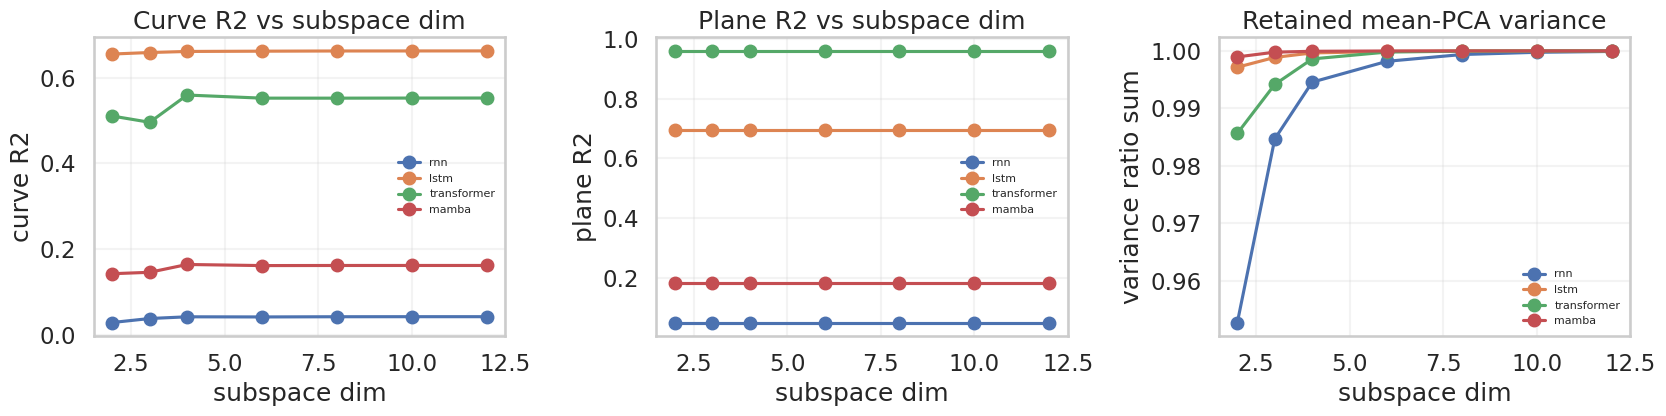

,model,subspace_dim,curve_height_r2,plane_height_r2,retained_mean_pca_var,curve_rmse,plane_rmse
0,rnn,2,0.028488,0.051115,0.952704,0.823454,0.000000
1,rnn,3,0.037777,0.051115,0.984675,1.036917,0.653058
2,rnn,4,0.041792,0.051115,0.994561,1.147328,0.815693
3,rnn,6,0.041453,0.051115,0.998190,1.227812,0.927223
4,rnn,8,0.041935,0.051115,0.999370,1.286887,1.004180
5,rnn,10,0.042046,0.051115,0.999759,1.299643,1.020466
6,rnn,12,0.042056,0.051115,0.999907,1.312928,1.037236
7,lstm,2,0.654736,0.693887,0.997160,2.995683,0.000000
8,lstm,3,0.658289,0.693887,0.998872,4.618417,3.476075
9,lstm,4,0.660764,0.693887,0.999648,5.904572,5.091525


In [65]:
def run_subspace_dim_sweep(all_results_dict, dims=None):
    if dims is None:
        dims = globals().get('MANIFOLD_SWEEP_DIMS', [2, 3, 4, 6, 8, 10, 12])
    rows = []
    for model_type in MODEL_TYPES:
        print('=' * 80)
        print(f'SUBSPACE DIM SWEEP: {model_type} | prefix={PREFIX_LENGTH}')
        data = all_results_dict[model_type]['test_data']
        for dim in dims:
            diag = compute_height_manifold_search(data, subspace_dim=dim)
            retained_var = float(diag['pc_var_explained'].sum())
            row = {
                'model': model_type,
                'subspace_dim': int(diag['subspace_dim']),
                'curve_height_r2': float(diag['curve_height_r2']),
                'plane_height_r2': float(diag['plane_height_r2']),
                'retained_mean_pca_var': retained_var,
                'curve_rmse': float(diag['curve_rmse']),
                'plane_rmse': float(diag['plane_rmse']),
            }
            rows.append(row)
            print(
                f"dim={row['subspace_dim']:>2d} | curve_r2={row['curve_height_r2']:.4f} | "
                f"plane_r2={row['plane_height_r2']:.4f} | retained_var={row['retained_mean_pca_var']:.4f}"
            )
    return rows


def plot_subspace_dim_sweep(rows):
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharex=True)
    for model_type in MODEL_TYPES:
        model_rows = sorted([r for r in rows if r['model'] == model_type], key=lambda r: r['subspace_dim'])
        dims = np.asarray([r['subspace_dim'] for r in model_rows])
        axes[0].plot(dims, [r['curve_height_r2'] for r in model_rows], marker='o', label=model_type)
        axes[1].plot(dims, [r['plane_height_r2'] for r in model_rows], marker='o', label=model_type)
        axes[2].plot(dims, [r['retained_mean_pca_var'] for r in model_rows], marker='o', label=model_type)

    axes[0].set_title('Curve R2 vs subspace dim')
    axes[0].set_ylabel('curve R2')
    axes[1].set_title('Plane R2 vs subspace dim')
    axes[1].set_ylabel('plane R2')
    axes[2].set_title('Retained mean-PCA variance')
    axes[2].set_ylabel('variance ratio sum')

    for ax in axes:
        ax.set_xlabel('subspace dim')
        ax.grid(True, alpha=0.22)
        ax.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()


subspace_dim_sweep_rows = run_subspace_dim_sweep(all_results)
plot_subspace_dim_sweep(subspace_dim_sweep_rows)
pd.DataFrame(subspace_dim_sweep_rows)


如果我把 manifold search 用的 PCA 子空间从 `2,3,4,6,8,10,12` 维一路放大，`curve` 的效果会不会明显变好？

- 左图：`curve R² vs subspace dim`
  看曲线坐标预测 `height` 的能力会不会随着维度增加而明显提升。

- 中图：`plane R² vs subspace dim`
  看 2D 平面解释 `height` 的能力。
  这里几乎是水平线，是正常的，因为 `plane` 一直只用前两个主成分；往后加第 3、4、6 维，并不会改变前两维本身。

- 右图：`retained mean-PCA variance`
  看类均值的几何是不是本来就已经很低维。
  如果 `2` 或 `4` 维就接近 `1.0`，说明“均值轨迹”已经几乎完全落在一个很低维的子空间里。

## 14. Piecewise-Linear Curve Through μ(h)

Replace the smooth curve fit with a piecewise-linear path that connects the height means `μ(h)` directly in order. This is a robustness check against spline overshoot: if a `1D` explanation is real, it should survive even when the fitted curve is simplified to a polyline.


PIECEWISE CURVE: rnn | prefix=200
kept heights: 25 classes | range 0 .. 50
mean-PCA variance ratios: 0.9100, 0.0427, 0.0320, 0.0099, 0.0024, 0.0012
sample RMSE  | line=1.2289, curve=1.2286, plane=0.9272
mean RMSE    | line=0.1327, curve=0.0000, plane=0.0953
height R2    | line=0.0473, curve=0.0403, plane=0.0511
curve stats  | length=4.9895, mean-path=4.9895, monotone=True


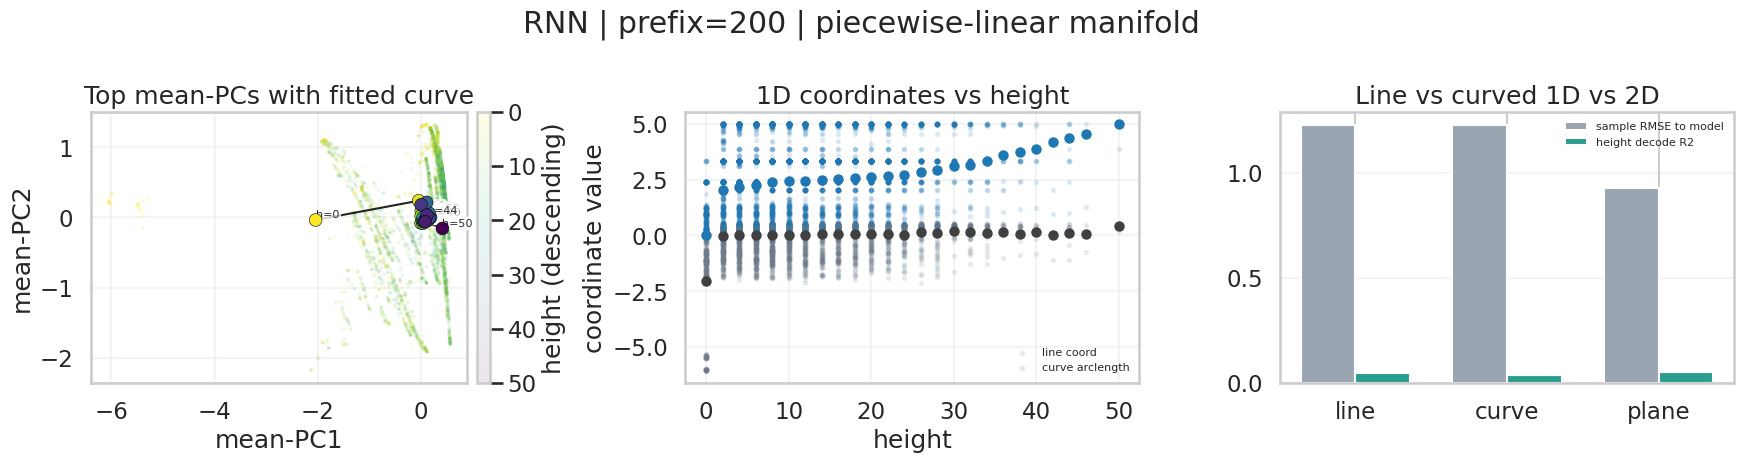

PIECEWISE CURVE: lstm | prefix=200
kept heights: 25 classes | range 0 .. 50
mean-PCA variance ratios: 0.9696, 0.0275, 0.0017, 0.0008, 0.0002, 0.0001
sample RMSE  | line=6.7949, curve=6.3773, plane=5.6253
mean RMSE    | line=2.5046, curve=0.0000, plane=0.7549
height R2    | line=0.6344, curve=0.6604, plane=0.6939
curve stats  | length=67.2250, mean-path=67.2250, monotone=True


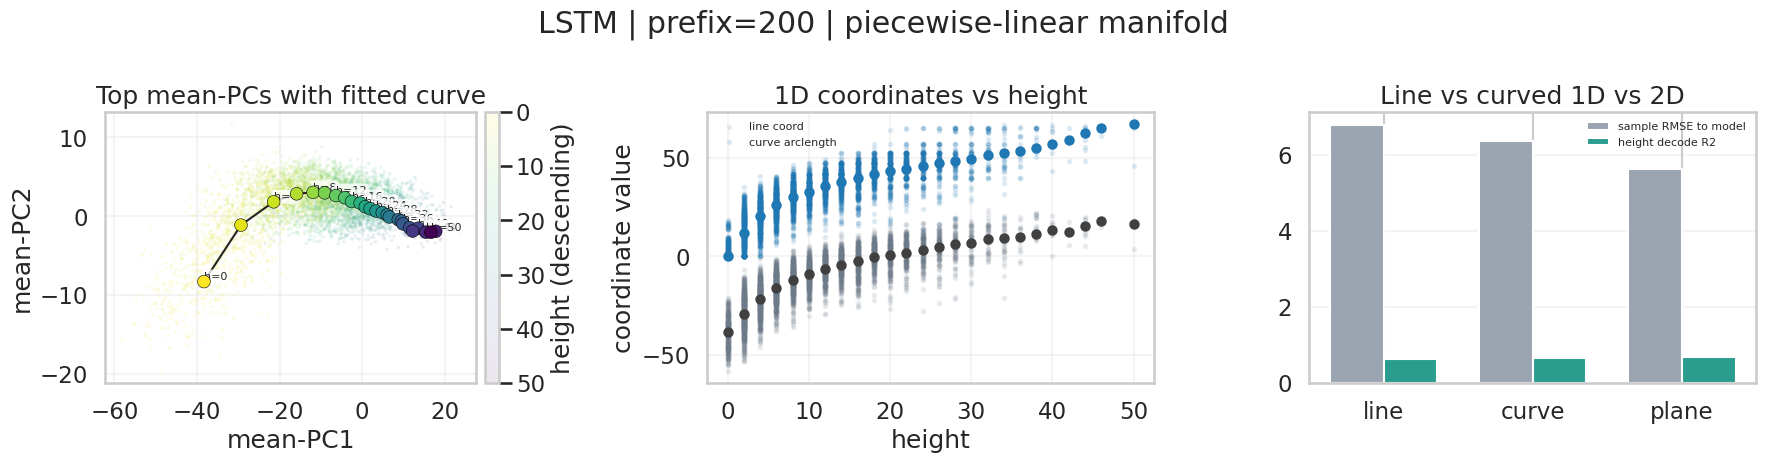

PIECEWISE CURVE: transformer | prefix=200
kept heights: 25 classes | range 0 .. 50
mean-PCA variance ratios: 0.7305, 0.2551, 0.0085, 0.0044, 0.0010, 0.0002
sample RMSE  | line=7.3447, curve=5.0980, plane=5.1340
mean RMSE    | line=4.2913, curve=0.0000, plane=0.9839
height R2    | line=0.5048, curve=0.5452, plane=0.9599
curve stats  | length=56.8601, mean-path=56.8601, monotone=True


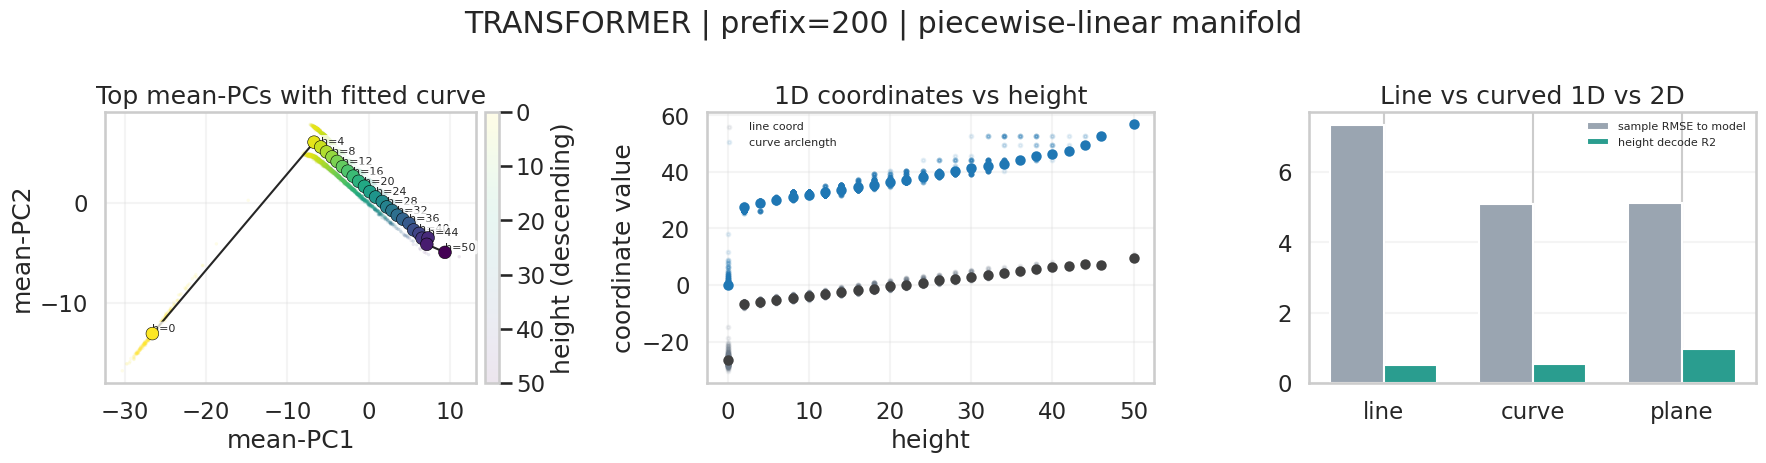

PIECEWISE CURVE: mamba | prefix=200
kept heights: 25 classes | range 0 .. 50
mean-PCA variance ratios: 0.9938, 0.0052, 0.0008, 0.0002, 0.0000, 0.0000
sample RMSE  | line=2.3299, curve=3.3709, plane=1.3564
mean RMSE    | line=0.9646, curve=0.0000, plane=0.3937
height R2    | line=0.0968, curve=0.1360, plane=0.1846
curve stats  | length=69.3093, mean-path=69.3093, monotone=True


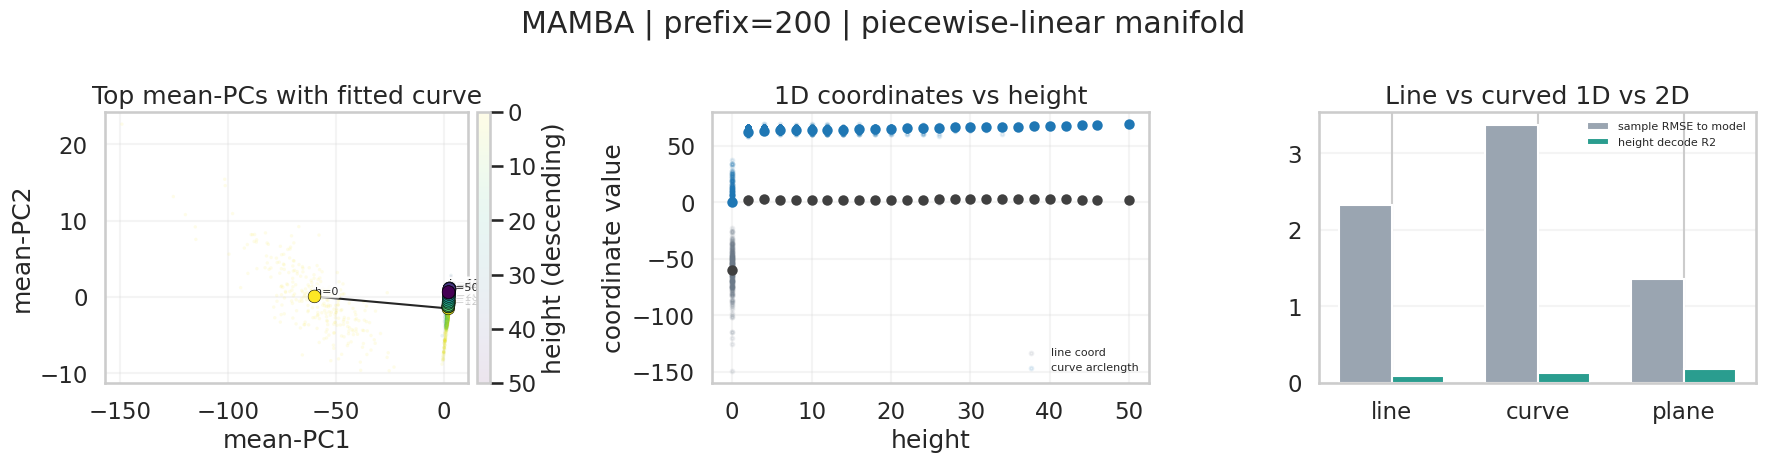

model | smooth_curve_r2 | piecewise_curve_r2 | plane_r2 | smooth_curve_rmse | piecewise_curve_rmse | plane_rmse
        rnn | 0.0415 | 0.0403 | 0.0511 | 1.2278 | 1.2286 | 0.9272
       lstm | 0.6614 | 0.6604 | 0.6939 | 6.3698 | 6.3773 | 5.6253
transformer | 0.5519 | 0.5452 | 0.9599 | 5.0777 | 5.0980 | 5.1340
      mamba | 0.1613 | 0.1360 | 0.1846 | 3.3651 | 3.3709 | 1.3564


In [66]:
def _polyline_curve(points, samples_per_seg=None):
    if samples_per_seg is None:
        samples_per_seg = globals().get('MANIFOLD_CURVE_SAMPLES_PER_SEG', 40)
    points = np.asarray(points, dtype=float)
    if len(points) < 2:
        return points.copy()
    curve = []
    for i in range(len(points) - 1):
        p1 = points[i]
        p2 = points[i + 1]
        ts = np.linspace(0.0, 1.0, int(samples_per_seg), endpoint=False)
        for t in ts:
            curve.append((1.0 - t) * p1 + t * p2)
    curve.append(points[-1])
    return np.asarray(curve, dtype=float)


def compute_height_manifold_search_polyline(
    data,
    *,
    min_count=None,
    subspace_dim=None,
    samples_per_seg=None,
):
    if min_count is None:
        min_count = globals().get('HEIGHT_GEOMETRY_MIN_COUNT', 5)
    if subspace_dim is None:
        subspace_dim = globals().get('MANIFOLD_SUBSPACE_DIM', 6)
    if samples_per_seg is None:
        samples_per_seg = globals().get('MANIFOLD_CURVE_SAMPLES_PER_SEG', 40)

    X = np.asarray(data['h'], dtype=float)
    height = np.asarray(data['height'], dtype=int)
    heights, counts = np.unique(height, return_counts=True)
    keep = counts >= int(min_count)
    heights = heights[keep]
    counts = counts[keep]
    if len(heights) < 4:
        raise ValueError('Need at least 4 height classes after min_count filtering.')

    keep_mask = np.isin(height, heights)
    X = X[keep_mask]
    sample_height = height[keep_mask]
    means = np.stack([X[sample_height == h].mean(axis=0) for h in heights], axis=0)
    center = means.mean(axis=0, keepdims=True)
    mean_centered = means - center

    max_dim = min(int(subspace_dim), means.shape[0] - 1, means.shape[1])
    if max_dim < 2:
        raise ValueError('Need at least a 2D subspace to test curved manifolds.')
    pca = PCA(n_components=max_dim)
    mean_coords = pca.fit_transform(mean_centered)
    sample_coords = (X - center) @ pca.components_.T

    if np.corrcoef(mean_coords[:, 0], heights)[0, 1] < 0:
        mean_coords[:, 0] *= -1
        sample_coords[:, 0] *= -1

    curve_points = _polyline_curve(mean_coords, samples_per_seg=samples_per_seg)
    curve_s = _curve_arclength(curve_points)
    _, mean_curve_sq, mean_curve_s = _project_points_to_curve(mean_coords, curve_points, curve_s)
    if np.corrcoef(mean_curve_s, heights)[0, 1] < 0:
        curve_points = curve_points[::-1].copy()
        total_len = float(curve_s[-1]) if len(curve_s) else 0.0
        curve_s = total_len - curve_s[::-1]
        _, mean_curve_sq, mean_curve_s = _project_points_to_curve(mean_coords, curve_points, curve_s)
    _, sample_curve_sq, sample_curve_s = _project_points_to_curve(sample_coords, curve_points, curve_s)

    line_resid_sq = (sample_coords[:, 1:] ** 2).sum(axis=1)
    mean_line_resid_sq = (mean_coords[:, 1:] ** 2).sum(axis=1)
    if sample_coords.shape[1] > 2:
        plane_resid_sq = (sample_coords[:, 2:] ** 2).sum(axis=1)
        mean_plane_resid_sq = (mean_coords[:, 2:] ** 2).sum(axis=1)
    else:
        plane_resid_sq = np.zeros(len(sample_coords), dtype=float)
        mean_plane_resid_sq = np.zeros(len(mean_coords), dtype=float)

    line_r2 = _fit_linear_readout_r2(sample_coords[:, 0], sample_height)
    curve_r2 = _fit_linear_readout_r2(sample_curve_s, sample_height)
    plane_r2 = _fit_linear_readout_r2(sample_coords[:, : min(2, sample_coords.shape[1])], sample_height)

    mean_path_steps = np.linalg.norm(mean_coords[1:] - mean_coords[:-1], axis=1)
    mean_curve_steps = np.diff(mean_curve_s)
    monotone_curve = bool(np.all(mean_curve_steps > 0))

    return {
        'heights': heights,
        'counts': counts,
        'sample_height': sample_height,
        'center': center,
        'pca': pca,
        'mean_coords': mean_coords,
        'sample_coords': sample_coords,
        'curve_points': curve_points,
        'curve_s': curve_s,
        'mean_curve_s': mean_curve_s,
        'sample_curve_s': sample_curve_s,
        'sample_curve_sq': sample_curve_sq,
        'line_resid_sq': line_resid_sq,
        'plane_resid_sq': plane_resid_sq,
        'mean_line_resid_sq': mean_line_resid_sq,
        'mean_plane_resid_sq': mean_plane_resid_sq,
        'mean_curve_sq': mean_curve_sq,
        'line_rmse': float(np.sqrt(line_resid_sq.mean())),
        'curve_rmse': float(np.sqrt(sample_curve_sq.mean())),
        'plane_rmse': float(np.sqrt(plane_resid_sq.mean())),
        'mean_line_rmse': float(np.sqrt(mean_line_resid_sq.mean())),
        'mean_curve_rmse': float(np.sqrt(mean_curve_sq.mean())),
        'mean_plane_rmse': float(np.sqrt(mean_plane_resid_sq.mean())),
        'line_height_r2': float(line_r2),
        'curve_height_r2': float(curve_r2),
        'plane_height_r2': float(plane_r2),
        'pc_var_explained': pca.explained_variance_ratio_,
        'subspace_dim': int(max_dim),
        'curve_length': float(curve_s[-1]) if len(curve_s) else 0.0,
        'mean_path_length': float(mean_path_steps.sum()) if len(mean_path_steps) else 0.0,
        'curve_monotone_in_height': monotone_curve,
    }


piecewise_manifold_results = {}
for model_type in MODEL_TYPES:
    print('=' * 80)
    print(f'PIECEWISE CURVE: {model_type} | prefix={PREFIX_LENGTH}')
    diag = compute_height_manifold_search_polyline(all_results[model_type]['test_data'])
    piecewise_manifold_results[model_type] = diag
    summarize_height_manifold_search(diag)
    plot_height_manifold_search(diag, title=f'{model_type.upper()} | prefix={PREFIX_LENGTH} | piecewise-linear manifold')


print('=' * 80)
print('model | smooth_curve_r2 | piecewise_curve_r2 | plane_r2 | smooth_curve_rmse | piecewise_curve_rmse | plane_rmse')
for model_type in MODEL_TYPES:
    smooth = manifold_search_results[model_type]
    piece = piecewise_manifold_results[model_type]
    print(
        f"{model_type:>11s} | {smooth['curve_height_r2']:.4f} | {piece['curve_height_r2']:.4f} | {piece['plane_height_r2']:.4f} | "
        f"{smooth['curve_rmse']:.4f} | {piece['curve_rmse']:.4f} | {piece['plane_rmse']:.4f}"
    )


如果我不用平滑曲线，只是把每个 `μ(h)` 按顺序用折线连起来，`1D manifold` 会不会变强？

- 对相邻两个类均值 `μ(h), μ(h+1)` 之间做线性插值
- 最后得到一条 piecewise-linear path
- 再把每个样本投到这条折线最近点
- 用折线弧长 `s(x)` 做 1D coordinate
- 然后继续算：
  - `curve_r2`
  - `curve_rmse`
  - 和 `plane_r2 / plane_rmse` 比较

1. 左图
- 在 mean-PCA 前两维里看类均值和折线路径
- 直观看是不是一条合理的 ordered path

1. 中图
- 黑色：line coordinate（PC1）
- 蓝色：curve arclength（沿折线的弧长）
- 看 `curve` 的 1D 坐标和 height 是否更单调、更有区分度

1. 右图
- 灰柱：到 line / curve / plane 的几何距离 RMSE
- 绿柱：用对应坐标预测 height 的 R²

**RNN**
从图上基本看不出变化，还是：
- 高度均值大多挤成一团
- 折线只是硬连起来
- `curve` 没有比 `line` 实质更强

- RNN 的问题不在曲线拟合器，而在于 hidden states 本身就没有清晰的 ordered manifold。

**LSTM**
LSTM 这张图其实最说明问题：

- 左图里折线顺着 `μ(h)` 的弯轨迹走，视觉上很合理
- 中图里蓝色弧长坐标和 height 的关系确实比单纯 line 更有结构
- 但右图里 `curve` 还是只比 `line` 略好，且仍然不如 `plane`

- LSTM 的最佳解释仍然是“接近 curved 1D，但带厚度”，不是严格的一条细线 manifold。

**Transformer**
- 左图中大多数 `μ(h)` 在一条很规整的斜带上，但 `h=0` 那个点被远远拉出去。
- 中图蓝色 `curve arclength` 虽然和 height 单调关系不错，但并没有把 height 压得特别准
- 右图里 `curve` 依旧明显不如 `plane`

**Mamba**
- 折线把几个均值点机械地连起来
- 但样本云和这条路径并没有形成特别自然的 1D 几何
- `curve` 依旧没有显著优于 `line` 或 `plane`

- Mamba 的 height 结构弱，不是拟合方法导致的，就算用最宽容的折线，1D 解释还是站不住。

## 15. 2D Nonlinear Decoder On The Mean-PCA Plane

Test whether the top two mean-PCA coordinates already support a stronger `2D` decoding story than any `1D` manifold. This section trains linear and small nonlinear decoders on the `2D` plane and compares their height prediction quality against the line and curve baselines.


2D NONLINEAR DECODER: rnn | prefix=200
line_r2=0.0473 | curve_r2=0.0403 | plane_linear_r2=0.0489 | plane_nonlinear_r2=0.0947


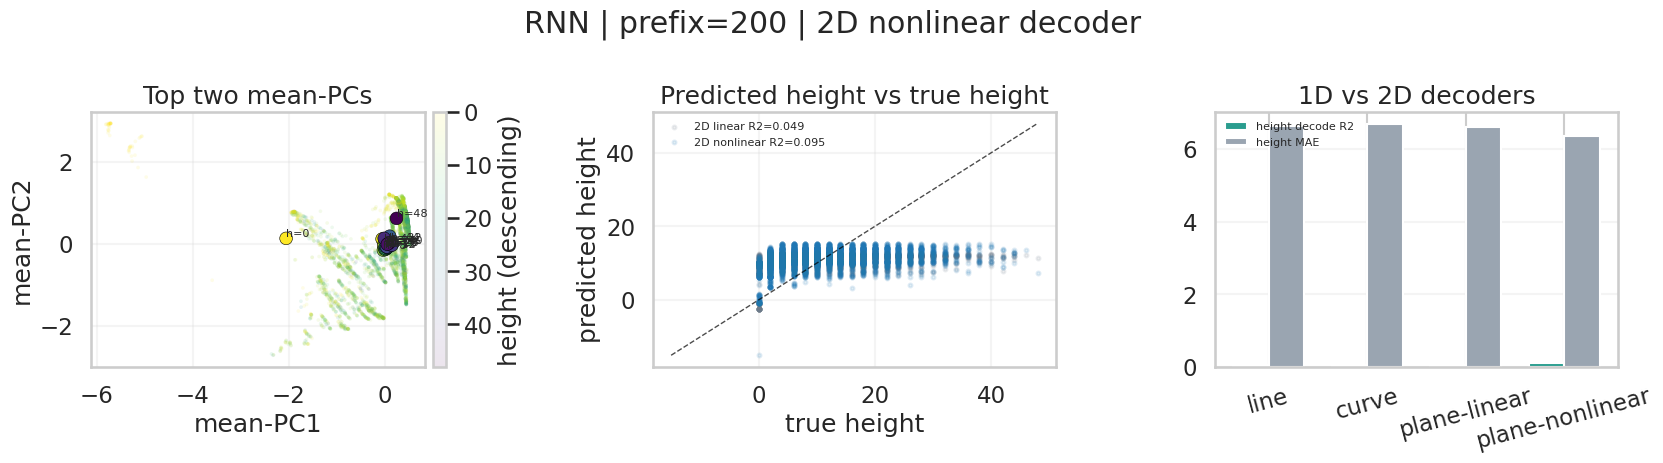

2D NONLINEAR DECODER: lstm | prefix=200
line_r2=0.6344 | curve_r2=0.6604 | plane_linear_r2=0.6937 | plane_nonlinear_r2=0.7624


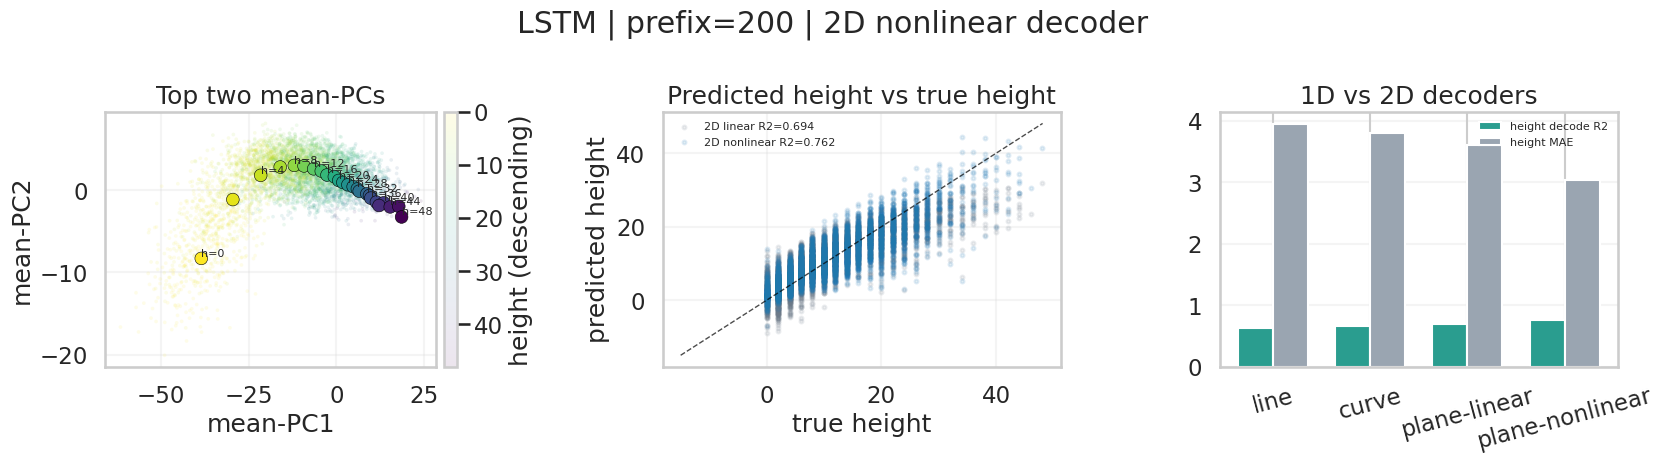

2D NONLINEAR DECODER: transformer | prefix=200
line_r2=0.5048 | curve_r2=0.5452 | plane_linear_r2=0.9558 | plane_nonlinear_r2=0.9769


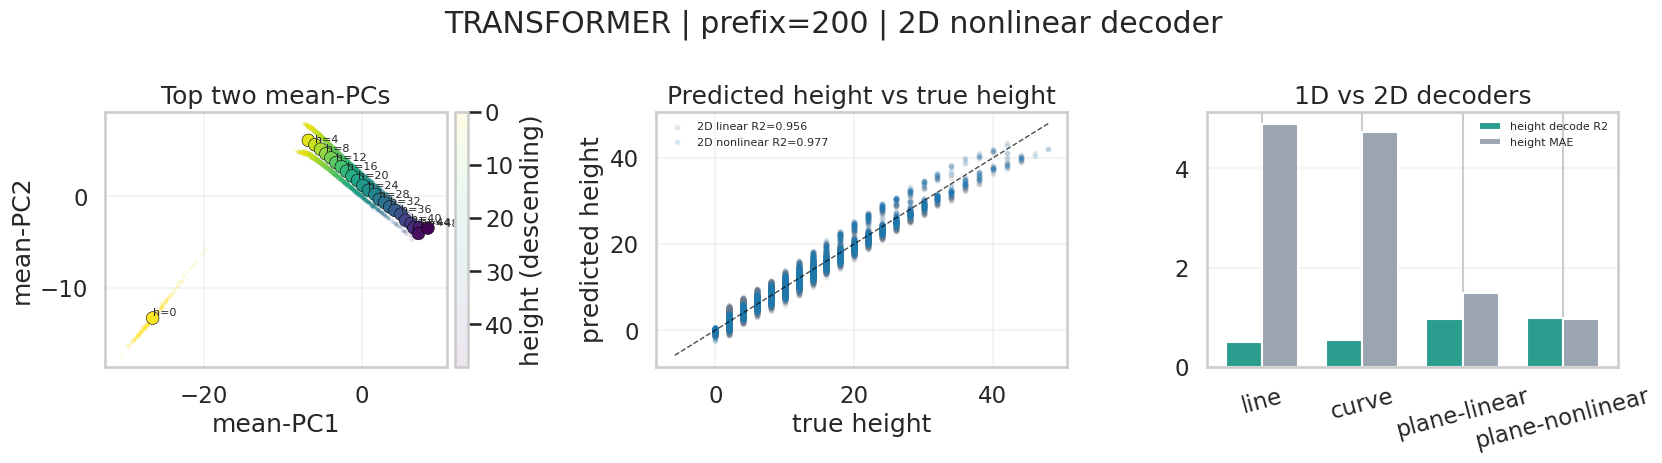

2D NONLINEAR DECODER: mamba | prefix=200
line_r2=0.0968 | curve_r2=0.1360 | plane_linear_r2=0.1837 | plane_nonlinear_r2=0.2136


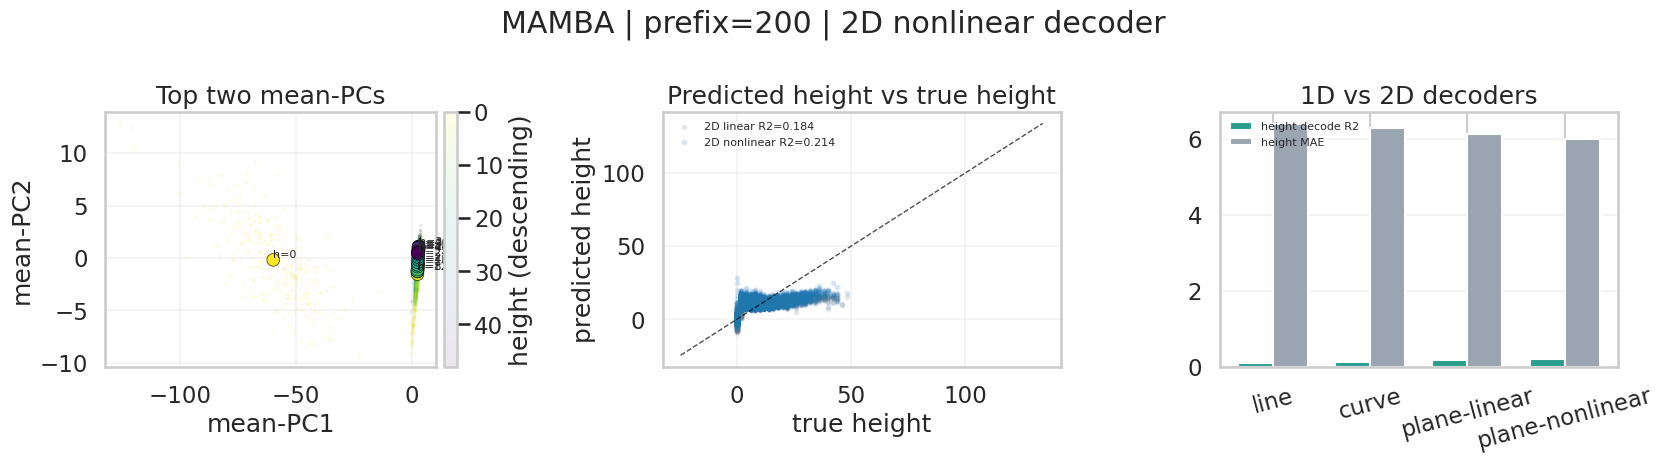

,model,line_r2,curve_r2,plane_linear_r2,plane_nonlinear_r2,line_mae,curve_mae,plane_linear_mae,plane_nonlinear_mae
0,rnn,0.047312,0.040251,0.048865,0.094678,6.625003,6.684574,6.607317,6.364087
1,lstm,0.634381,0.660425,0.693717,0.762374,3.946613,3.805909,3.603891,3.042991
2,transformer,0.504818,0.545234,0.955819,0.976900,4.892763,4.731715,1.493128,0.956330
3,mamba,0.096837,0.135994,0.183704,0.213566,6.389611,6.273483,6.120588,5.990598


In [67]:
def _fit_coordinate_decoder_metrics(z_train, y_train, z_test, y_test):
    z_train = np.asarray(z_train, dtype=float)
    z_test = np.asarray(z_test, dtype=float)
    if z_train.ndim == 1:
        z_train = z_train[:, None]
    if z_test.ndim == 1:
        z_test = z_test[:, None]
    X = np.c_[np.ones(len(y_train)), z_train]
    coef, *_ = np.linalg.lstsq(X, np.asarray(y_train, dtype=float), rcond=None)
    pred = np.c_[np.ones(len(y_test)), z_test] @ coef
    return {
        'pred': pred,
        'r2': float(r2_score(y_test, pred)),
        'mae': float(mean_absolute_error(y_test, pred)),
    }


def _prepare_height_plane_split(train_data, test_data, min_count=None):
    if min_count is None:
        min_count = globals().get('HEIGHT_GEOMETRY_MIN_COUNT', 5)
    X_train = np.asarray(train_data['h'], dtype=float)
    y_train = np.asarray(train_data['height'], dtype=int)
    X_test = np.asarray(test_data['h'], dtype=float)
    y_test = np.asarray(test_data['height'], dtype=int)

    train_heights, train_counts = np.unique(y_train, return_counts=True)
    keep_heights = train_heights[train_counts >= int(min_count)]
    test_heights = np.unique(y_test)
    keep_heights = np.array(sorted(set(keep_heights.tolist()) & set(test_heights.tolist())), dtype=int)
    if len(keep_heights) < 4:
        raise ValueError('Need at least 4 shared height classes after min_count filtering.')

    train_mask = np.isin(y_train, keep_heights)
    test_mask = np.isin(y_test, keep_heights)
    X_train = X_train[train_mask]
    y_train = y_train[train_mask]
    X_test = X_test[test_mask]
    y_test = y_test[test_mask]

    mean_train = np.stack([X_train[y_train == h].mean(axis=0) for h in keep_heights], axis=0)
    center = mean_train.mean(axis=0, keepdims=True)
    pca = PCA(n_components=min(2, mean_train.shape[0] - 1, mean_train.shape[1]))
    mean_coords_train = pca.fit_transform(mean_train - center)
    X_train_2d = (X_train - center) @ pca.components_.T
    X_test_2d = (X_test - center) @ pca.components_.T
    mean_coords_test = np.stack([X_test_2d[y_test == h].mean(axis=0) for h in keep_heights], axis=0)

    corr = np.corrcoef(mean_coords_train[:, 0], keep_heights)[0, 1] if len(keep_heights) > 1 else 1.0
    if np.isnan(corr):
        corr = 0.0
    if corr < 0:
        mean_coords_train[:, 0] *= -1
        mean_coords_test[:, 0] *= -1
        X_train_2d[:, 0] *= -1
        X_test_2d[:, 0] *= -1

    return {
        'X_train_2d': X_train_2d,
        'X_test_2d': X_test_2d,
        'y_train': y_train,
        'y_test': y_test,
        'keep_heights': keep_heights,
        'mean_coords_train': mean_coords_train,
        'mean_coords_test': mean_coords_test,
    }


def fit_height_2d_nonlinear_decoder(train_data, test_data, degree=3, alpha=1.0, min_count=None):
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import PolynomialFeatures, StandardScaler
    from sklearn.linear_model import Ridge

    split = _prepare_height_plane_split(train_data, test_data, min_count=min_count)
    X_train_2d = split['X_train_2d']
    X_test_2d = split['X_test_2d']
    y_train = split['y_train']
    y_test = split['y_test']

    plane_linear = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    plane_linear.fit(X_train_2d, y_train)
    pred_linear = plane_linear.predict(X_test_2d)

    plane_nonlinear = make_pipeline(
        PolynomialFeatures(degree=int(degree), include_bias=False),
        StandardScaler(),
        Ridge(alpha=alpha),
    )
    plane_nonlinear.fit(X_train_2d, y_train)
    pred_nonlinear = plane_nonlinear.predict(X_test_2d)

    return {
        'split': split,
        'linear_r2': float(r2_score(y_test, pred_linear)),
        'linear_mae': float(mean_absolute_error(y_test, pred_linear)),
        'nonlinear_r2': float(r2_score(y_test, pred_nonlinear)),
        'nonlinear_mae': float(mean_absolute_error(y_test, pred_nonlinear)),
        'pred_linear': pred_linear,
        'pred_nonlinear': pred_nonlinear,
    }


def plot_height_2d_decoder(result, *, title):
    split = result['split']
    X_test_2d = split['X_test_2d']
    y_test = split['y_test']
    mean_coords = split['mean_coords_test']
    heights = split['keep_heights']
    pred_linear = result['pred_linear']
    pred_nonlinear = result['pred_nonlinear']

    rng = np.random.default_rng(0)
    max_points = min(len(X_test_2d), 5000)
    idx = rng.choice(len(X_test_2d), size=max_points, replace=False) if len(X_test_2d) > max_points else np.arange(len(X_test_2d))
    X_plot = X_test_2d[idx]
    y_plot = y_test[idx]
    pred_linear_plot = pred_linear[idx]
    pred_nonlinear_plot = pred_nonlinear[idx]

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
    sc = axes[0].scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap='viridis_r', s=7, alpha=0.10, edgecolors='none')
    axes[0].scatter(mean_coords[:, 0], mean_coords[:, 1], c=heights, cmap='viridis_r', s=84, edgecolors='black', linewidths=0.4)
    label_every = max(1, len(heights) // 10)
    for i, (x, y, h) in enumerate(zip(mean_coords[:, 0], mean_coords[:, 1], heights)):
        if i % label_every == 0 or i == len(heights) - 1:
            axes[0].text(x, y, f'h={int(h)}', fontsize=8, ha='left', va='bottom')
    axes[0].set_title('Top two mean-PCs')
    axes[0].set_xlabel('mean-PC1')
    axes[0].set_ylabel('mean-PC2')
    axes[0].grid(True, alpha=0.2)
    cbar = fig.colorbar(sc, ax=axes[0], pad=0.02)
    cbar.set_label('height (descending)')
    cbar.ax.invert_yaxis()

    axes[1].scatter(y_plot, pred_linear_plot, s=8, alpha=0.12, color='#6c7a89', label=f'2D linear R2={result["linear_r2"]:.3f}')
    axes[1].scatter(y_plot, pred_nonlinear_plot, s=8, alpha=0.12, color='#1f77b4', label=f'2D nonlinear R2={result["nonlinear_r2"]:.3f}')
    lo = min(y_test.min(), pred_linear.min(), pred_nonlinear.min())
    hi = max(y_test.max(), pred_linear.max(), pred_nonlinear.max())
    axes[1].plot([lo, hi], [lo, hi], color='black', lw=1.0, linestyle='--', alpha=0.7)
    axes[1].set_title('Predicted height vs true height')
    axes[1].set_xlabel('true height')
    axes[1].set_ylabel('predicted height')
    axes[1].grid(True, alpha=0.2)
    axes[1].legend(frameon=False, fontsize=8)

    labels = ['line', 'curve', 'plane-linear', 'plane-nonlinear']
    r2s = [result['line_r2'], result['curve_r2'], result['linear_r2'], result['nonlinear_r2']]
    maes = [result['line_mae'], result['curve_mae'], result['linear_mae'], result['nonlinear_mae']]
    x = np.arange(len(labels))
    axes[2].bar(x - 0.18, r2s, width=0.36, color='#2a9d8f', label='height decode R2')
    axes[2].bar(x + 0.18, maes, width=0.36, color='#9aa5b1', label='height MAE')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(labels, rotation=15)
    axes[2].set_title('1D vs 2D decoders')
    axes[2].grid(True, axis='y', alpha=0.2)
    axes[2].legend(frameon=False, fontsize=8)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


height_2d_decoder_results = {}
for model_type in MODEL_TYPES:
    print('=' * 80)
    print(f'2D NONLINEAR DECODER: {model_type} | prefix={PREFIX_LENGTH}')
    decoder = fit_height_2d_nonlinear_decoder(
        all_results[model_type]['train_data'],
        all_results[model_type]['test_data'],
        degree=3,
    )
    base = piecewise_manifold_results[model_type]
    line_metrics = _fit_coordinate_decoder_metrics(base['sample_coords'][:, 0], base['sample_height'], base['sample_coords'][:, 0], base['sample_height'])
    curve_metrics = _fit_coordinate_decoder_metrics(base['sample_curve_s'], base['sample_height'], base['sample_curve_s'], base['sample_height'])
    merged = {
        **decoder,
        'line_r2': float(line_metrics['r2']),
        'curve_r2': float(curve_metrics['r2']),
        'line_mae': float(line_metrics['mae']),
        'curve_mae': float(curve_metrics['mae']),
    }
    height_2d_decoder_results[model_type] = merged
    print(
        f"line_r2={merged['line_r2']:.4f} | curve_r2={merged['curve_r2']:.4f} | plane_linear_r2={merged['linear_r2']:.4f} | plane_nonlinear_r2={merged['nonlinear_r2']:.4f}"
    )
    plot_height_2d_decoder(merged, title=f'{model_type.upper()} | prefix={PREFIX_LENGTH} | 2D nonlinear decoder')


height_2d_rows = []
for model_type, result in height_2d_decoder_results.items():
    height_2d_rows.append({
        'model': model_type,
        'line_r2': result['line_r2'],
        'curve_r2': result['curve_r2'],
        'plane_linear_r2': result['linear_r2'],
        'plane_nonlinear_r2': result['nonlinear_r2'],
        'line_mae': result['line_mae'],
        'curve_mae': result['curve_mae'],
        'plane_linear_mae': result['linear_mae'],
        'plane_nonlinear_mae': result['nonlinear_mae'],
    })
pd.DataFrame(height_2d_rows)


如果 `1D line` 和 `1D curve` 都不够好，那是不是其实前两维里已经有一个更合适的 `2D` 几何，只是它不是线性的？

- `line`
  用 `PC1` 这一个坐标预测 `height`
- `curve`
  用折线 manifold 的弧长 `s(x)` 这个一维坐标预测 `height`
- `plane-linear`
  用前两维 `(PC1, PC2)` 做线性回归预测 `height`
- `plane-nonlinear`
  用前两维 `(PC1, PC2)` 做一个小的非线性回归预测 `height`
  这里实现是 `PolynomialFeatures(degree=3) + Ridge`

- `plane-linear` 和 `plane-nonlinear` 是真正的 `train -> test` 评估
- 但 `line` 和 `curve` 这里是直接在同一批 `piecewise_manifold_results` 样本上算的诊断指标，不是严格独立的 train/test split

1. 中图 `Predicted height vs true height`
- 横轴是真实 `height`
- 纵轴是 decoder 预测出来的 `height`
- 灰色是 `2D linear`
- 蓝色是 `2D nonlinear`
- 越贴近对角线越好

2. 右图 `1D vs 2D decoders`
- 绿色柱是 `R²`
- 灰色柱是 `MAE`
- 比较四种 decoder 谁更适合

### RNN
- `line_r2 = 0.047`
- `curve_r2 = 0.040`
- `plane_linear_r2 = 0.049`
- `plane_nonlinear_r2 = 0.095`

- RNN 这里不是“需要更聪明的低维 decoder”，而是 height 表示本身就很弱，不像清晰的 1D，也不像清晰的 2D。

### LSTM
- `line_r2 = 0.634`
- `curve_r2 = 0.660`
- `plane_linear_r2 = 0.694`
- `plane_nonlinear_r2 = 0.762`

- LSTM 不是单一直线 counter，也不只是“完美 curved 1D”，更像一个低维弯带结构，其中 1D 主轨迹很强，但 2D 非线性会更完整地解释 height。

### Transformer
- `line_r2 = 0.505`
- `curve_r2 = 0.545`
- `plane_linear_r2 = 0.956`
- `plane_nonlinear_r2 = 0.977`

- Transformer，1D 解释明显不够，即便用 curve，也只到 `0.545`，但只用前两维做线性回归，就已经 `0.956`，再加一点轻微非线性，直接到 `0.977`。更像一个二维低维 manifold，而不是单参数弧长能压缩掉的结构。

### Mamba
- `line_r2 = 0.097`
- `curve_r2 = 0.136`
- `plane_linear_r2 = 0.184`
- `plane_nonlinear_r2 = 0.214`
：
- Mamba 不是完全没结构，但这个结构不强，不足以支持清晰的 1D/2D counting-manifold 叙事。

## 16. Trimmed 1D Manifold Without Endpoints

Trim away the lowest and highest height classes and recompute the `1D` manifold metrics. This isolates whether the apparent nonlinearity is mainly caused by endpoint outliers or whether the middle of the representation is still inconsistent with a simple `1D` counter curve.


TRIMMED 1D: rnn | full_curve_r2=0.0403 -> trimmed_curve_r2=0.0008 | full_line_r2=0.0473 -> trimmed_line_r2=0.0010


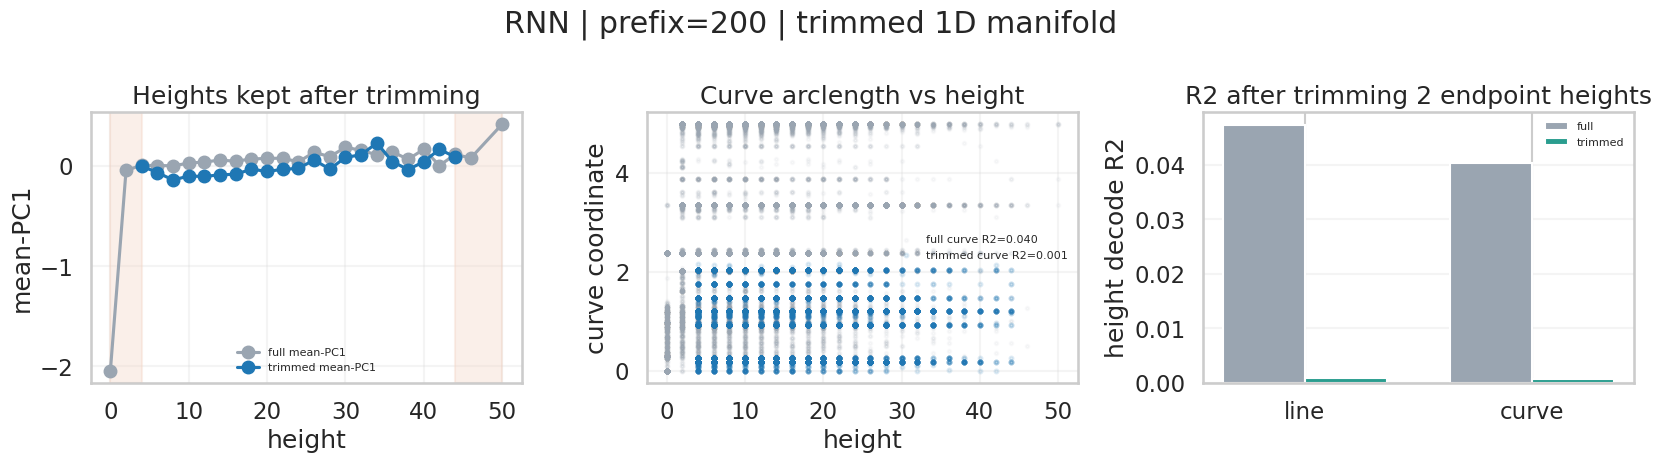

TRIMMED 1D: lstm | full_curve_r2=0.6604 -> trimmed_curve_r2=0.6049 | full_line_r2=0.6344 -> trimmed_line_r2=0.5710


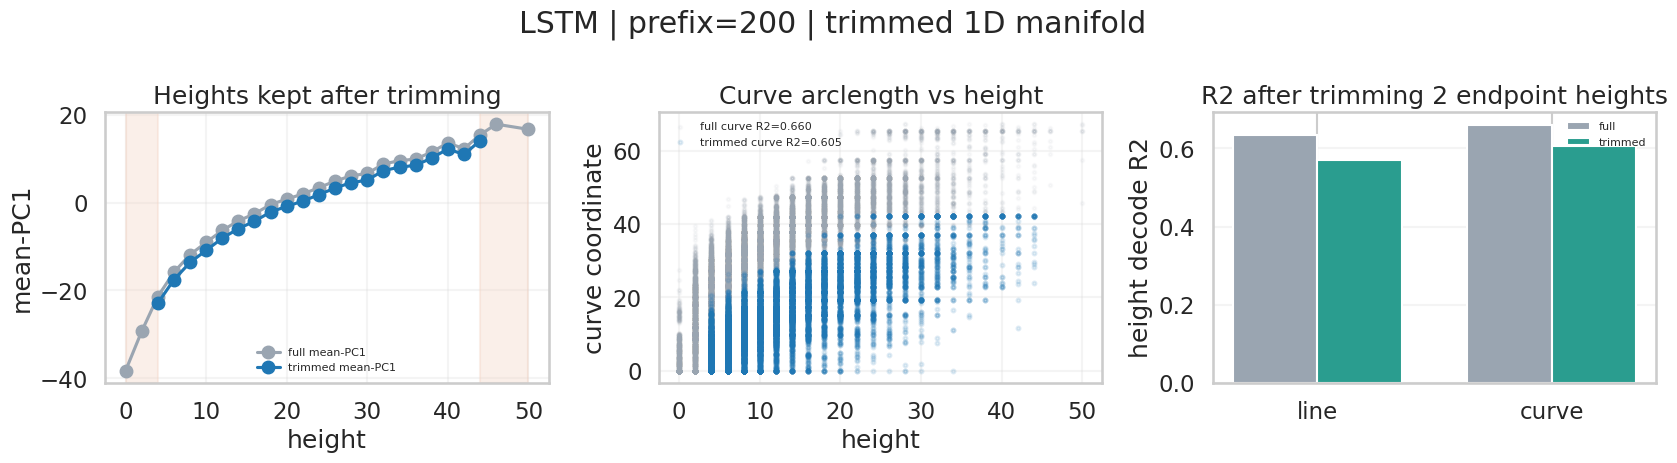

TRIMMED 1D: transformer | full_curve_r2=0.5452 -> trimmed_curve_r2=0.9369 | full_line_r2=0.5048 -> trimmed_line_r2=0.9618


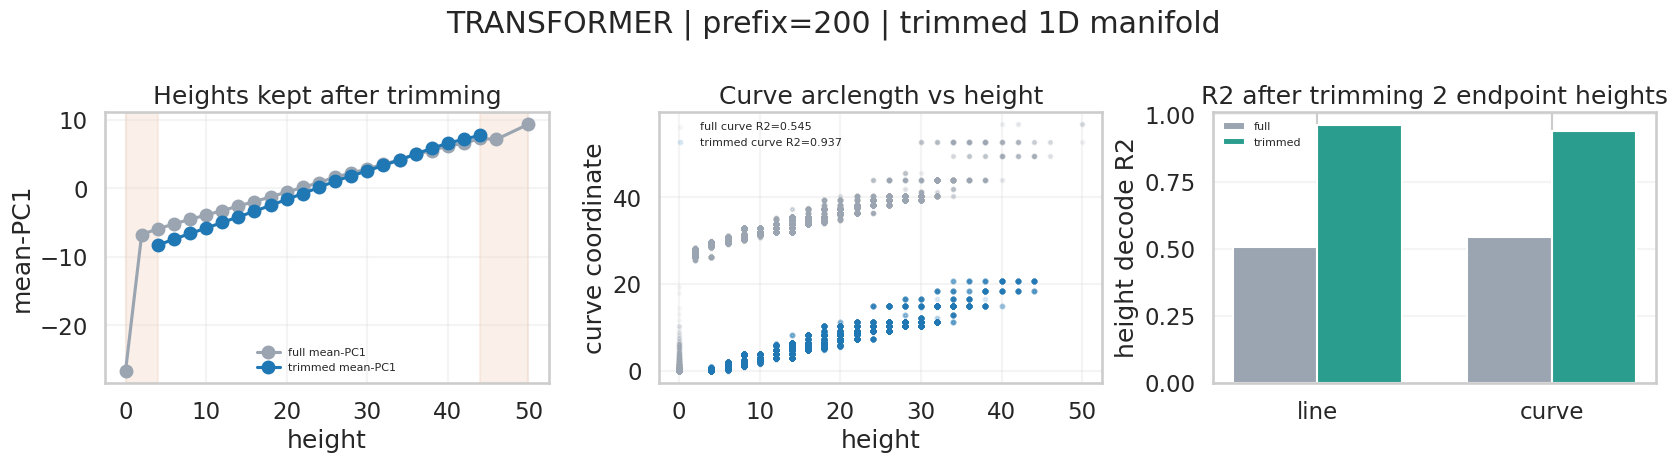

TRIMMED 1D: mamba | full_curve_r2=0.1360 -> trimmed_curve_r2=0.2176 | full_line_r2=0.0968 -> trimmed_line_r2=0.1056


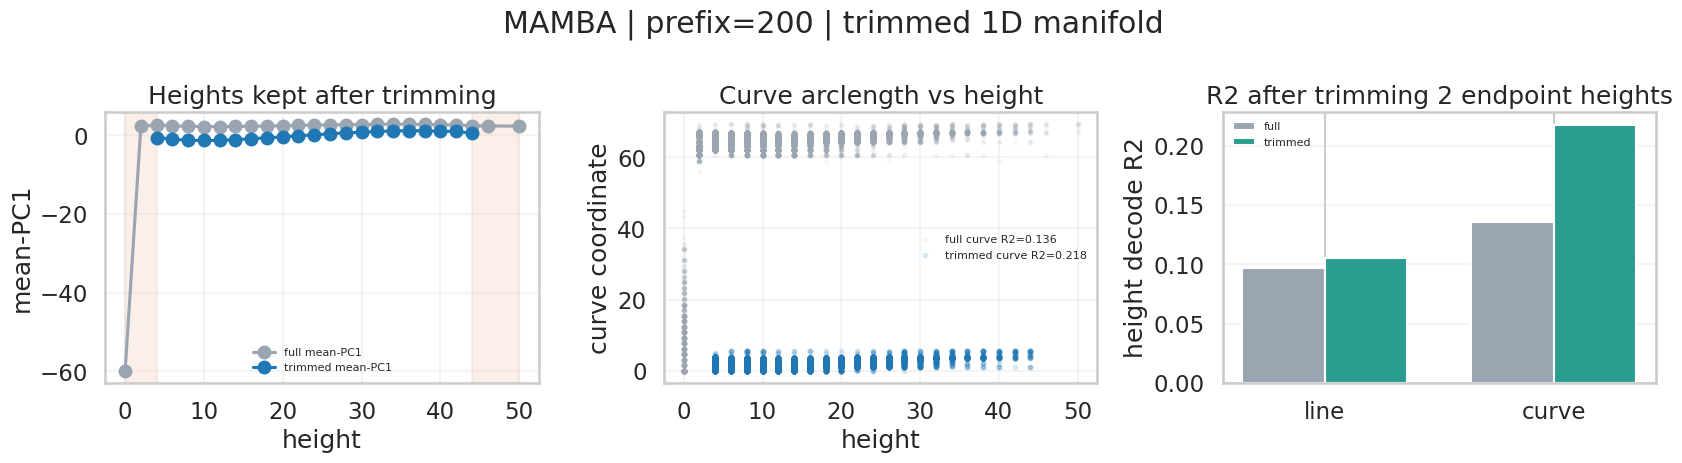

,model,trim_each_side,full_n_heights,trimmed_n_heights,full_curve_r2,trimmed_curve_r2,full_line_r2,trimmed_line_r2,full_curve_rmse,trimmed_curve_rmse
0,rnn,2,25,21,0.040251,0.000833,0.047312,0.000983,1.228630,1.193476
1,lstm,2,25,21,0.660425,0.604926,0.634381,0.570998,6.377336,6.511563
2,transformer,2,25,21,0.545234,0.936911,0.504818,0.961779,5.097968,5.259478
3,mamba,2,25,21,0.135994,0.217605,0.096837,0.105569,3.370934,1.121763


In [68]:
TRIM_ENDPOINT_HEIGHTS = 2


def _trim_height_classes(data, trim_each_side=TRIM_ENDPOINT_HEIGHTS, min_count=None):
    if min_count is None:
        min_count = globals().get('HEIGHT_GEOMETRY_MIN_COUNT', 5)
    height = np.asarray(data['height'])
    heights, counts = np.unique(height, return_counts=True)
    keep = heights[counts >= int(min_count)]
    keep = np.asarray(sorted(keep.tolist()), dtype=int)
    if len(keep) <= 2 * int(trim_each_side):
        raise ValueError('Not enough height classes left after trimming endpoints.')
    trimmed_heights = keep[int(trim_each_side): len(keep) - int(trim_each_side)]
    mask = np.isin(height, trimmed_heights)
    return {k: np.asarray(v)[mask] for k, v in data.items()}, keep, trimmed_heights


def compare_trimmed_piecewise_1d(all_results_dict, trim_each_side=TRIM_ENDPOINT_HEIGHTS):
    rows = []
    diags = {}
    for model_type in MODEL_TYPES:
        full_data = all_results_dict[model_type]['test_data']
        trimmed_data, full_heights, kept_heights = _trim_height_classes(full_data, trim_each_side=trim_each_side)
        full_diag = compute_height_manifold_search_polyline(full_data)
        trimmed_diag = compute_height_manifold_search_polyline(trimmed_data, min_count=1)
        diags[model_type] = {
            'full': full_diag,
            'trimmed': trimmed_diag,
            'full_heights': full_heights,
            'kept_heights': kept_heights,
        }
        rows.append({
            'model': model_type,
            'trim_each_side': int(trim_each_side),
            'full_n_heights': int(len(full_diag['heights'])),
            'trimmed_n_heights': int(len(trimmed_diag['heights'])),
            'full_curve_r2': float(full_diag['curve_height_r2']),
            'trimmed_curve_r2': float(trimmed_diag['curve_height_r2']),
            'full_line_r2': float(full_diag['line_height_r2']),
            'trimmed_line_r2': float(trimmed_diag['line_height_r2']),
            'full_curve_rmse': float(full_diag['curve_rmse']),
            'trimmed_curve_rmse': float(trimmed_diag['curve_rmse']),
        })
    return rows, diags


def plot_trimmed_piecewise_1d(diag_bundle, *, model_type, trim_each_side=TRIM_ENDPOINT_HEIGHTS):
    full_diag = diag_bundle['full']
    trimmed_diag = diag_bundle['trimmed']
    kept_heights = diag_bundle['kept_heights']

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

    axes[0].plot(full_diag['heights'], full_diag['mean_coords'][:, 0], marker='o', color='#9aa5b1', label='full mean-PC1')
    axes[0].plot(trimmed_diag['heights'], trimmed_diag['mean_coords'][:, 0], marker='o', color='#1f77b4', label='trimmed mean-PC1')
    axes[0].axvspan(full_diag['heights'][0], kept_heights[0], color='#f3d2c1', alpha=0.35)
    axes[0].axvspan(kept_heights[-1], full_diag['heights'][-1], color='#f3d2c1', alpha=0.35)
    axes[0].set_title('Heights kept after trimming')
    axes[0].set_xlabel('height')
    axes[0].set_ylabel('mean-PC1')
    axes[0].grid(True, alpha=0.2)
    axes[0].legend(frameon=False, fontsize=8)

    axes[1].scatter(full_diag['sample_height'], full_diag['sample_curve_s'], s=6, alpha=0.06, color='#9aa5b1', label=f"full curve R2={full_diag['curve_height_r2']:.3f}")
    axes[1].scatter(trimmed_diag['sample_height'], trimmed_diag['sample_curve_s'], s=8, alpha=0.12, color='#1f77b4', label=f"trimmed curve R2={trimmed_diag['curve_height_r2']:.3f}")
    axes[1].set_title('Curve arclength vs height')
    axes[1].set_xlabel('height')
    axes[1].set_ylabel('curve coordinate')
    axes[1].grid(True, alpha=0.2)
    axes[1].legend(frameon=False, fontsize=8)

    labels = ['line', 'curve']
    full_r2 = [full_diag['line_height_r2'], full_diag['curve_height_r2']]
    trim_r2 = [trimmed_diag['line_height_r2'], trimmed_diag['curve_height_r2']]
    x = np.arange(len(labels))
    axes[2].bar(x - 0.18, full_r2, width=0.36, color='#9aa5b1', label='full')
    axes[2].bar(x + 0.18, trim_r2, width=0.36, color='#2a9d8f', label='trimmed')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(labels)
    axes[2].set_title(f'R2 after trimming {trim_each_side} endpoint heights')
    axes[2].set_ylabel('height decode R2')
    axes[2].grid(True, axis='y', alpha=0.2)
    axes[2].legend(frameon=False, fontsize=8)

    fig.suptitle(f'{model_type.upper()} | prefix={PREFIX_LENGTH} | trimmed 1D manifold')
    plt.tight_layout()
    plt.show()


trimmed_1d_rows, trimmed_1d_diags = compare_trimmed_piecewise_1d(all_results, trim_each_side=TRIM_ENDPOINT_HEIGHTS)
for model_type in MODEL_TYPES:
    print('=' * 80)
    row = next(r for r in trimmed_1d_rows if r['model'] == model_type)
    print(
        f"TRIMMED 1D: {model_type} | full_curve_r2={row['full_curve_r2']:.4f} -> trimmed_curve_r2={row['trimmed_curve_r2']:.4f} | "
        f"full_line_r2={row['full_line_r2']:.4f} -> trimmed_line_r2={row['trimmed_line_r2']:.4f}"
    )
    plot_trimmed_piecewise_1d(trimmed_1d_diags[model_type], model_type=model_type, trim_each_side=TRIM_ENDPOINT_HEIGHTS)

pd.DataFrame(trimmed_1d_rows)


把最小的几个 height 和最大的几个 height 先删掉，只保留中间那一段 height，然后重新跑一遍 `piecewise-linear 1D manifold`，比较 trimming 前后，`line_r2` 和 `curve_r2` 有没有明显变好。

- `TRIM_ENDPOINT_HEIGHTS = 2`: 最低的 2 个 height class 去掉，最高的 2 个 height class 去掉。

对每个模型做两次 manifold 分析：
- `full_diag`：原始全高度
- `trimmed_diag`：去掉端点后的高度

然后收集这些指标：
- `full_curve_r2 -> trimmed_curve_r2`
- `full_line_r2 -> trimmed_line_r2`
- 以及对应的 `curve_rmse`

1. 左图 `Heights kept after trimming`
- 灰线：全部 height 的 mean-PC1 轨迹
- 蓝线：trim 后保留部分
- 两边浅红色区域：被裁掉的端点高度

2. 中图 `Curve arclength vs height`
- 灰点：全数据时的 curve 坐标
- 蓝点：trim 后的 curve 坐标
- 直接看去掉端点后，`curve coordinate -> height` 是否更规整

3. 右图 `R2 after trimming`
- 比较 trim 前后 `line` 和 `curve` 的 `R²`

### RNN
- 本来就没有稳定的 1D height manifold

### LSTM
- 左图里端点确实更弯，中段更平滑，去掉两端后，蓝线看起来更规整。
- 但右图：
  - `full curve R2 ≈ 0.660`
  - `trimmed curve R2 ≈ 0.605`
  - `line_r2` 也略降

- 视觉上中段更“像线/像曲线”，但从真正的 height 解码上，trim 后反而没更好。
- LSTM 的 1D 结构不是“被端点毁掉”，相反，端点其实也是整体几何的一部分，去掉它们以后，并没有让 1D 解释更纯净。

### Transformer
- 左图去掉两端后，剩下的蓝线几乎就是一条非常规整的斜轨迹
- 中图里 trimmed 后蓝点的 `curve arclength vs height` 变得极其整齐
- 右图里 `R²` 大幅跳升：
  - `full line R2 ≈ 0.505 -> trimmed line R2 ≈ 0.955`
  - `full curve R2 ≈ 0.545 -> trimmed curve R2 ≈ 0.937`

- 对 Transformer 来说，中段甚至不只是 curved-1D，它更接近“几乎线性的 1D trend”，真正破坏全局 1D 叙事的，主要是端点状态。
- Transformer 的整体表示全局更像 2D，但中间高度区间非常接近 1D。
- 所以最准确的话是：
  - `global geometry`: 2D / endpoint-distorted
  - `interior regime`: almost 1D

### Mamba
- 本来就没有稳定的 1D height manifoldd

## 17. Top-Of-Stack Probes And Transformer Attention

Test whether the hidden state stores more than just `height` by probing the top of the current Dyck stack. In this single-bracket setting, the relevant top-of-stack variable is the most recent unmatched opening bracket, so we probe whether the stack is empty and how far away that top opening position is. For the transformer, we also inspect attention patterns directly and ask whether any heads concentrate attention on that top-of-stack opening position at `prefix = 200`.


TOP-OF-STACK PROBES: rnn | prefix=200


/home/hp_twist_shan/miniforge3/envs/hse/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 6.443607247774708e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


logistic     stack_nonempty  accuracy: 0.9572
   ridge  top_open_distance        r2: -410.6143
   ridge  top_open_distance       mae: 11.0915
TOP-OF-STACK PROBES: lstm | prefix=200
logistic     stack_nonempty  accuracy: 1.0000
   ridge  top_open_distance        r2: 0.6536
   ridge  top_open_distance       mae: 8.3689
TOP-OF-STACK PROBES: transformer | prefix=200
logistic     stack_nonempty  accuracy: 1.0000
   ridge  top_open_distance        r2: 0.4220
   ridge  top_open_distance       mae: 11.2193
TOP-OF-STACK PROBES: mamba | prefix=200
logistic     stack_nonempty  accuracy: 1.0000
   ridge  top_open_distance        r2: 0.6140
   ridge  top_open_distance       mae: 9.0248


,model,stack_nonempty_acc,top_open_distance_r2,top_open_distance_mae
0,rnn,0.9572,-410.614288,11.091507
1,lstm,1.0000,0.653633,8.368896
2,transformer,1.0000,0.421956,11.219271
3,mamba,1.0000,0.613961,9.024756


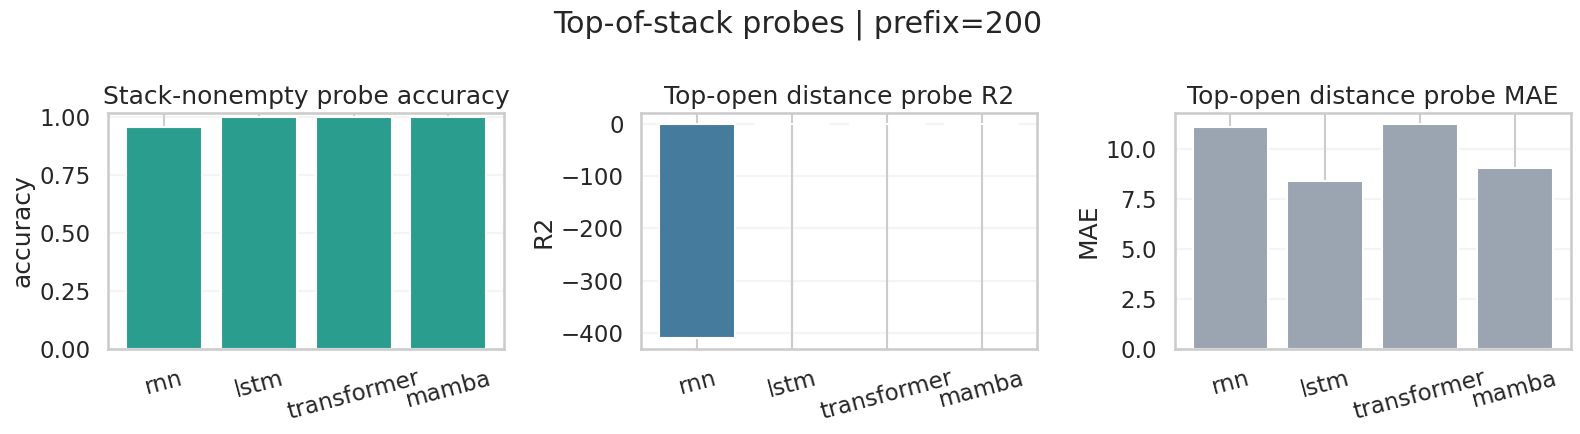

TRANSFORMER ATTENTION: prefix=200
best head for top-of-stack attention | layer=2 | head=3 | mean top mass=0.0168 | top1 hit=0.0000


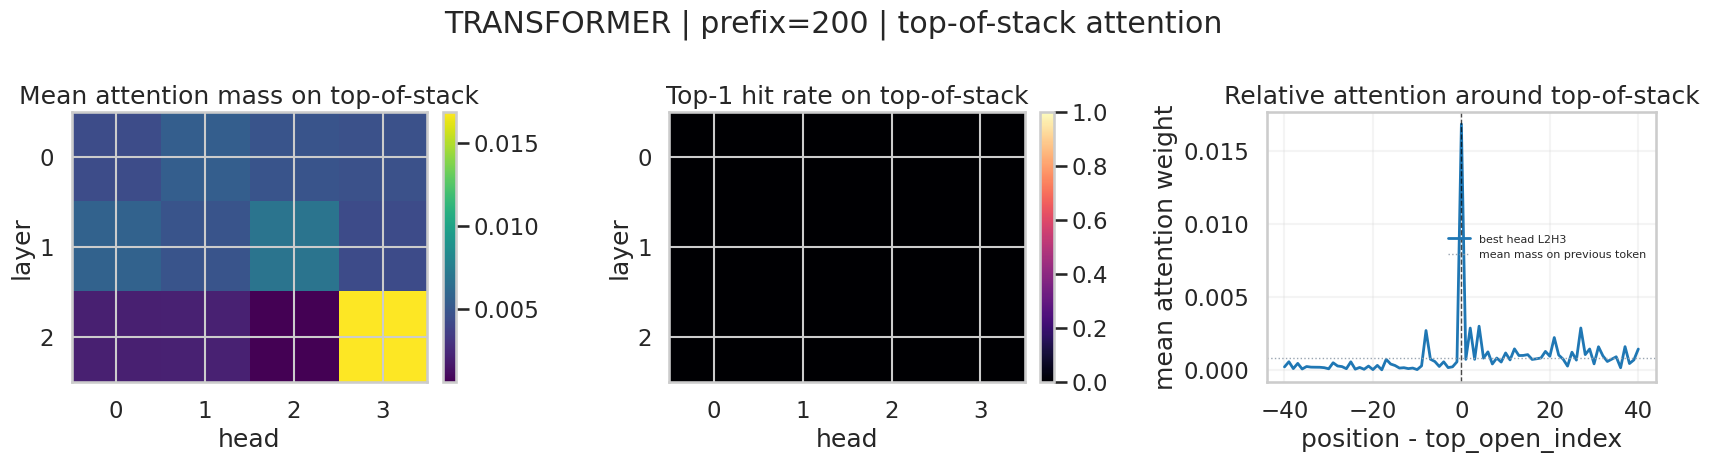

In [69]:
def augment_with_top_of_stack_labels(data, *, open_token=None, close_token=None):
    if open_token is None or close_token is None:
        cfg = make_sampler(seed_offset=0).config
        open_token = cfg.open_token
        close_token = cfg.close_token

    prefix = np.asarray(data['prefix'])
    n, prefix_length = prefix.shape
    top_open_index = np.full(n, -1, dtype=int)
    top_open_distance = np.full(n, -1, dtype=int)
    stack_nonempty = np.zeros(n, dtype=int)

    for i, row in enumerate(prefix):
        stack = []
        for pos, tok in enumerate(row.tolist()):
            if tok == open_token:
                stack.append(pos)
            elif tok == close_token and stack:
                stack.pop()
        if stack:
            top = int(stack[-1])
            top_open_index[i] = top
            top_open_distance[i] = int(prefix_length - 1 - top)
            stack_nonempty[i] = 1

    out = {k: np.asarray(v).copy() for k, v in data.items()}
    out['top_open_index'] = top_open_index
    out['top_open_distance'] = top_open_distance
    out['stack_nonempty'] = stack_nonempty
    return out


def filter_stack_nonempty(data):
    mask = np.asarray(data['stack_nonempty']).astype(bool)
    return {k: np.asarray(v)[mask] for k, v in data.items()}


def run_top_of_stack_probes(train_data, test_data):
    rows = []
    fitted = {}
    X_train = np.asarray(train_data['h'])
    X_test = np.asarray(test_data['h'])

    stack_out = fit_logistic_probe(
        X_train,
        np.asarray(train_data['stack_nonempty']),
        X_test,
        np.asarray(test_data['stack_nonempty']),
        'stack_nonempty',
    )
    fitted['logistic_stack_nonempty'] = stack_out['probe']
    rows.append({'probe': 'logistic', 'target': 'stack_nonempty', 'metric': 'accuracy', 'value': stack_out['accuracy']})
    rows.append({'probe': 'logistic', 'target': 'stack_nonempty', 'metric': 'n_classes', 'value': stack_out['n_classes']})

    train_nonempty = filter_stack_nonempty(train_data)
    test_nonempty = filter_stack_nonempty(test_data)
    if len(train_nonempty['h']) >= 8 and len(np.unique(train_nonempty['top_open_distance'])) >= 2 and len(np.unique(test_nonempty['top_open_distance'])) >= 2:
        dist_out = fit_ridge_probe(
            np.asarray(train_nonempty['h']),
            np.asarray(train_nonempty['top_open_distance']),
            np.asarray(test_nonempty['h']),
            np.asarray(test_nonempty['top_open_distance']),
            'top_open_distance',
        )
        fitted['ridge_top_open_distance'] = dist_out['probe']
        rows.append({'probe': 'ridge', 'target': 'top_open_distance', 'metric': 'r2', 'value': dist_out['r2']})
        rows.append({'probe': 'ridge', 'target': 'top_open_distance', 'metric': 'mae', 'value': dist_out['mae']})
    else:
        rows.append({'probe': 'ridge', 'target': 'top_open_distance', 'metric': 'r2', 'value': float('nan')})
        rows.append({'probe': 'ridge', 'target': 'top_open_distance', 'metric': 'mae', 'value': float('nan')})

    return rows, fitted


def collect_top_of_stack_probe_rows(results):
    rows = []
    for model_type, payload in results.items():
        lookup = {(row['probe'], row['target'], row['metric']): row['value'] for row in payload['rows']}
        rows.append({
            'model': model_type,
            'stack_nonempty_acc': lookup.get(('logistic', 'stack_nonempty', 'accuracy'), float('nan')),
            'top_open_distance_r2': lookup.get(('ridge', 'top_open_distance', 'r2'), float('nan')),
            'top_open_distance_mae': lookup.get(('ridge', 'top_open_distance', 'mae'), float('nan')),
        })
    return rows


def plot_top_of_stack_probe_summary(rows):
    df = pd.DataFrame(rows)
    labels = df['model'].tolist()
    x = np.arange(len(labels))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    axes[0].bar(x, df['stack_nonempty_acc'], color='#2a9d8f')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=15)
    axes[0].set_ylim(0.0, 1.02)
    axes[0].set_title('Stack-nonempty probe accuracy')
    axes[0].set_ylabel('accuracy')
    axes[0].grid(True, axis='y', alpha=0.2)

    axes[1].bar(x, df['top_open_distance_r2'], color='#457b9d')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=15)
    axes[1].set_title('Top-open distance probe R2')
    axes[1].set_ylabel('R2')
    axes[1].grid(True, axis='y', alpha=0.2)

    axes[2].bar(x, df['top_open_distance_mae'], color='#9aa5b1')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(labels, rotation=15)
    axes[2].set_title('Top-open distance probe MAE')
    axes[2].set_ylabel('MAE')
    axes[2].grid(True, axis='y', alpha=0.2)

    fig.suptitle(f'Top-of-stack probes | prefix={PREFIX_LENGTH}')
    plt.tight_layout()
    plt.show()


def capture_transformer_prefix_attention(model, tokens, *, prefix_length=PREFIX_LENGTH, layer_indices=None):
    import types

    if layer_indices is None:
        layer_indices = list(range(model.num_layers))
    layer_indices = [model.num_layers + idx if idx < 0 else idx for idx in layer_indices]
    cache = {}
    originals = {}

    for idx in layer_indices:
        layer = model.layers[idx]
        originals[idx] = layer._sa_block

        def make_patched(layer_idx):
            def patched(this, x, attn_mask, key_padding_mask, is_causal=False):
                attn_out, attn_w = this.self_attn(
                    x, x, x,
                    attn_mask=attn_mask,
                    key_padding_mask=key_padding_mask,
                    need_weights=True,
                    average_attn_weights=False,
                    is_causal=is_causal,
                )
                cache[layer_idx] = attn_w[:, :, prefix_length - 1, :prefix_length].detach().cpu()
                return this.dropout1(attn_out)
            return patched

        layer._sa_block = types.MethodType(make_patched(idx), layer)

    try:
        model.eval().to(DEVICE)
        _ = model(tokens.to(DEVICE))
    finally:
        for idx in layer_indices:
            model.layers[idx]._sa_block = originals[idx]

    return cache


def sample_transformer_attention_prefix_data(
    model,
    sampler,
    *,
    prefix_length=PREFIX_LENGTH,
    n_samples=1024,
    batch_size=128,
):
    cfg = sampler.config
    open_token = cfg.open_token
    close_token = cfg.close_token
    remaining = int(n_samples)
    attn_parts = None
    prefixes = []
    top_indices = []
    stack_nonempty = []
    heights = []

    while remaining > 0:
        bs = min(int(batch_size), remaining)
        batch = sampler.sample(bs)
        tokens = batch.tokens
        prefix = tokens[:, :prefix_length].detach().cpu().numpy()
        cache = capture_transformer_prefix_attention(model, tokens, prefix_length=prefix_length)

        if attn_parts is None:
            attn_parts = {idx: [] for idx in sorted(cache)}
        for idx in sorted(cache):
            attn_parts[idx].append(cache[idx].numpy())

        for row in prefix:
            stack = []
            for pos, tok in enumerate(row.tolist()):
                if tok == open_token:
                    stack.append(pos)
                elif tok == close_token and stack:
                    stack.pop()
            if stack:
                top_indices.append(int(stack[-1]))
                stack_nonempty.append(1)
            else:
                top_indices.append(-1)
                stack_nonempty.append(0)
            heights.append(int((row == open_token).sum() - (row == close_token).sum()))
        prefixes.append(prefix)
        remaining -= bs

    out = {
        'prefix': np.concatenate(prefixes, axis=0),
        'top_open_index': np.asarray(top_indices, dtype=int),
        'stack_nonempty': np.asarray(stack_nonempty, dtype=int),
        'height': np.asarray(heights, dtype=int),
        'attn_by_layer': {idx: np.concatenate(parts, axis=0) for idx, parts in attn_parts.items()},
    }
    return out


def summarize_transformer_top_attention(attn_data):
    top_idx = np.asarray(attn_data['top_open_index'])
    nonempty = np.asarray(attn_data['stack_nonempty']).astype(bool)
    n_layers = len(attn_data['attn_by_layer'])
    first = next(iter(attn_data['attn_by_layer'].values()))
    n_heads = first.shape[1]
    top_mass = np.full((n_layers, n_heads), np.nan, dtype=float)
    top1_hit = np.full((n_layers, n_heads), np.nan, dtype=float)
    prev_mass = np.full((n_layers, n_heads), np.nan, dtype=float)

    if not nonempty.any():
        raise ValueError('No nonempty-stack prefixes found for attention analysis.')

    valid_top = top_idx[nonempty]
    prefix_length = first.shape[-1]
    prev_idx = np.full_like(valid_top, prefix_length - 2)

    for layer_idx, attn in attn_data['attn_by_layer'].items():
        attn_nonempty = attn[nonempty]  # [N, H, P]
        gather_top = np.take_along_axis(attn_nonempty, valid_top[:, None, None], axis=2).squeeze(-1)
        gather_prev = np.take_along_axis(attn_nonempty, prev_idx[:, None, None], axis=2).squeeze(-1)
        argmax_idx = attn_nonempty.argmax(axis=2)
        top_mass[layer_idx] = gather_top.mean(axis=0)
        prev_mass[layer_idx] = gather_prev.mean(axis=0)
        top1_hit[layer_idx] = (argmax_idx == valid_top[:, None]).mean(axis=0)

    best_flat = np.nanargmax(top_mass)
    best_layer, best_head = np.unravel_index(best_flat, top_mass.shape)
    best_attn = attn_data['attn_by_layer'][best_layer][nonempty, best_head, :]

    return {
        'top_mass': top_mass,
        'top1_hit': top1_hit,
        'prev_mass': prev_mass,
        'best_layer': int(best_layer),
        'best_head': int(best_head),
        'best_head_attn': best_attn,
        'valid_top_index': valid_top,
        'nonempty_mask': nonempty,
    }


def relative_attention_profile(head_attn, top_index, window=40):
    head_attn = np.asarray(head_attn, dtype=float)
    top_index = np.asarray(top_index, dtype=int)
    prefix_length = head_attn.shape[1]
    rel = np.arange(prefix_length)[None, :] - top_index[:, None]
    mask = (rel >= -int(window)) & (rel <= int(window))
    bins = (rel[mask] + int(window)).astype(int)
    vals = head_attn[mask]
    sums = np.bincount(bins, weights=vals, minlength=2 * int(window) + 1)
    counts = np.bincount(bins, minlength=2 * int(window) + 1)
    profile = sums / np.maximum(counts, 1)
    offsets = np.arange(-int(window), int(window) + 1)
    return offsets, profile


def plot_transformer_top_attention(summary, *, title, window=40):
    top_mass = summary['top_mass']
    top1_hit = summary['top1_hit']
    prev_mass = summary['prev_mass']
    best_layer = summary['best_layer']
    best_head = summary['best_head']
    offsets, profile = relative_attention_profile(summary['best_head_attn'], summary['valid_top_index'], window=window)

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

    im0 = axes[0].imshow(top_mass, aspect='auto', cmap='viridis')
    axes[0].set_title('Mean attention mass on top-of-stack')
    axes[0].set_xlabel('head')
    axes[0].set_ylabel('layer')
    axes[0].set_xticks(np.arange(top_mass.shape[1]))
    axes[0].set_yticks(np.arange(top_mass.shape[0]))
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(top1_hit, aspect='auto', cmap='magma', vmin=0.0, vmax=1.0)
    axes[1].set_title('Top-1 hit rate on top-of-stack')
    axes[1].set_xlabel('head')
    axes[1].set_ylabel('layer')
    axes[1].set_xticks(np.arange(top1_hit.shape[1]))
    axes[1].set_yticks(np.arange(top1_hit.shape[0]))
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].plot(offsets, profile, color='#1f77b4', lw=2.0, label=f'best head L{best_layer}H{best_head}')
    axes[2].axvline(0, color='black', lw=1.0, linestyle='--', alpha=0.7)
    axes[2].axhline(prev_mass[best_layer, best_head], color='#9aa5b1', lw=1.0, linestyle=':', label='mean mass on previous token')
    axes[2].set_title('Relative attention around top-of-stack')
    axes[2].set_xlabel('position - top_open_index')
    axes[2].set_ylabel('mean attention weight')
    axes[2].grid(True, alpha=0.2)
    axes[2].legend(frameon=False, fontsize=8)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


top_of_stack_probe_results = {}
for model_type in MODEL_TYPES:
    print('=' * 80)
    print(f'TOP-OF-STACK PROBES: {model_type} | prefix={PREFIX_LENGTH}')
    train_aug = augment_with_top_of_stack_labels(all_results[model_type]['train_data'])
    test_aug = augment_with_top_of_stack_labels(all_results[model_type]['test_data'])
    rows, fitted = run_top_of_stack_probes(train_aug, test_aug)
    top_of_stack_probe_results[model_type] = {
        'rows': rows,
        'fitted': fitted,
        'train_data': train_aug,
        'test_data': test_aug,
    }
    for row in rows:
        if row['metric'] in {'accuracy', 'r2', 'mae'}:
            print(f"{row['probe']:>8s} {row['target']:>18s} {row['metric']:>9s}: {row['value']:.4f}")


top_of_stack_rows = collect_top_of_stack_probe_rows(top_of_stack_probe_results)
display(pd.DataFrame(top_of_stack_rows))
plot_top_of_stack_probe_summary(top_of_stack_rows)


print('=' * 80)
print(f'TRANSFORMER ATTENTION: prefix={PREFIX_LENGTH}')
transformer_attention_data = sample_transformer_attention_prefix_data(
    loaded_models['transformer']['model'],
    make_sampler(seed_offset=9100),
    prefix_length=PREFIX_LENGTH,
    n_samples=1024,
    batch_size=128,
)
transformer_attention_summary = summarize_transformer_top_attention(transformer_attention_data)
print(
    'best head for top-of-stack attention | '
    f"layer={transformer_attention_summary['best_layer']} | "
    f"head={transformer_attention_summary['best_head']} | "
    f"mean top mass={transformer_attention_summary['top_mass'][transformer_attention_summary['best_layer'], transformer_attention_summary['best_head']]:.4f} | "
    f"top1 hit={transformer_attention_summary['top1_hit'][transformer_attention_summary['best_layer'], transformer_attention_summary['best_head']]:.4f}"
)
plot_transformer_top_attention(
    transformer_attention_summary,
    title=f'TRANSFORMER | prefix={PREFIX_LENGTH} | top-of-stack attention',
    window=40,
)


给每个固定 prefix 的 hidden state 增加了两个和栈有关的标签。
- `stack_nonempty = 1` 表示这个 Dyck prefix 结束时，栈里至少还有一个未匹配的 opening bracket；否则为 `0`。
- `top_open_index` 表示这个 prefix 里最近那个尚未匹配的 opening bracket 的位置，最左边是 `0`；如果栈为空，则记为 `-1`。
- `top_open_distance = (prefix_length - 1) - top_open_index` 表示当前 prefix 末尾到这个“栈顶 opening 位置”的距离。
- `w_top_open_distance` 指的是最能线性预测 `top_open_distance` 的 Ridge probe 方向。

probe 部分随后拟合：
- 一个用于预测 `stack_nonempty` 的 logistic probe；
- 一个只在“栈非空”子集上预测 `top_open_distance` 的 Ridge probe。

transformer attention 部分会抓出每一层每一个 head 从 prefix 末尾这个 query 位置看向更早 prefix 位置的 attention 分布，并测量：
- 落在真实 `top_open_index` 上的平均 attention mass；
- 真实 `top_open_index` 是否是 attention top-1；
- attention 随着相对 `top_open_index` 偏移量变化的曲线。

`stack_nonempty` accuracy 高，只说明 hidden state 能把“空栈”和“非空栈”分开；如果标签极度不平衡，这个证据其实比较弱。
`top_open_distance` 的 `R^2` 高，才说明 hidden state 里有一个很强的、线性的“精确栈顶距离”编码。
在 attention 图里，如果真存在一个强的“栈指针”机制，通常应该看到一个或多个 head 同时满足：
- 在 `top_open_index` 上有较大的平均 attention mass；
- 有明显不为零的 top-1 hit rate；
- 在相对偏移 `0` 的位置出现尖锐的 attention 峰值。

四个模型的 `stack_nonempty` 几乎都能被完美分类。

`top_open_distance` 并没有被干净地解码出来。`R^2` 数值较弱或不稳定，这说明在这个单括号任务里，“精确的栈顶距离”不是一个稳定的线性特征。

transformer 的 attention 图显示，在真实 top-of-stack 附近确实有一点 enrichment，但并不是一个很强的 pointer-like 机制：
  - top-of-stack 上的平均 mass 只比均匀 baseline 稍高；
  - top-1 hit rate 接近零；
  - 偏移 `0` 的 attention 峰值存在，但并不大。

因此，当前证据不支持“transformer 主要靠某个 head 显式指向精确的栈顶 opening 位置来解这个任务”这一说法。

对于单括号 Dyck，这也不算太意外：和多括号任务相比，精确的栈顶 identity 在行为上没那么重要，所以模型更可能依赖 `height`、局部 token phase，或者其他低维状态变量。


## 18. Supervised 2D Projections Beyond PCA

Compare the mean-PCA visualizations to two more targeted 2D projections. The first uses the supervised `height` probe direction plus the leading residual-PCA direction after removing height, which tests whether there is a systematic second degree of freedom beyond the counter itself. The second uses the supervised `height` direction plus the supervised `top-of-stack` direction, which asks whether the extra geometry is specifically aligned with stack-top information rather than just with generic variance.


SUPERVISED 2D PROJECTION: rnn | prefix=200
residual-axis vs top-distance | R2=0.2800 | corr=-0.5291
top-axis vs top-distance      | R2=0.0018 | corr=-0.0427


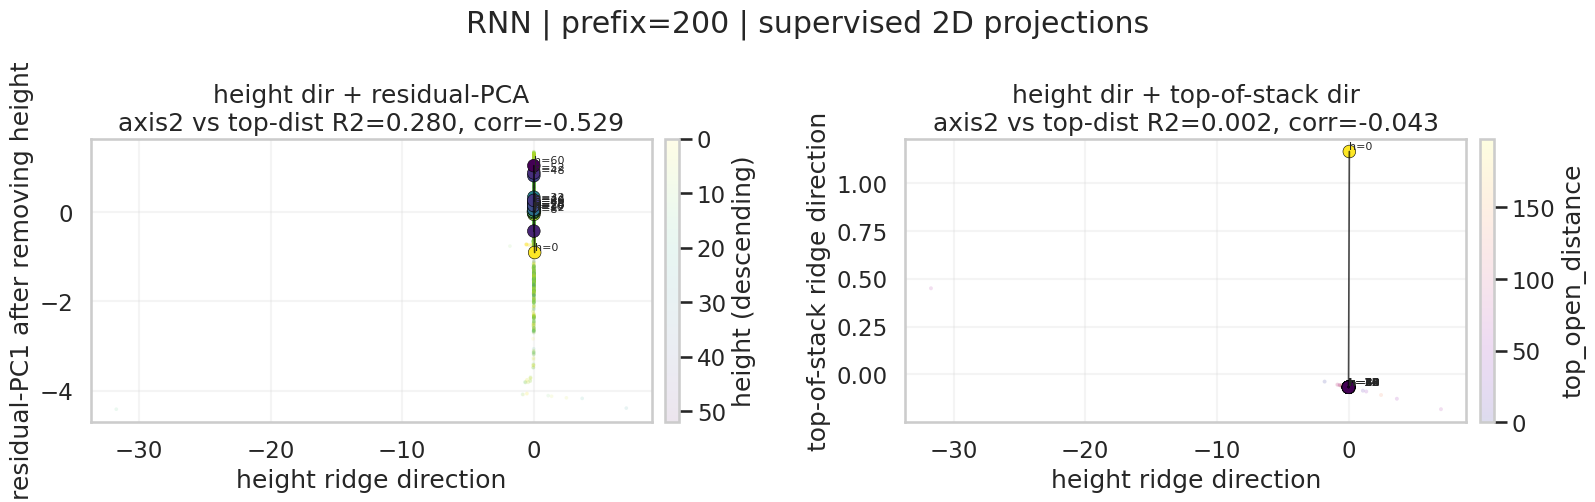

SUPERVISED 2D PROJECTION: lstm | prefix=200
residual-axis vs top-distance | R2=0.0124 | corr=-0.1115
top-axis vs top-distance      | R2=0.3741 | corr=0.6116


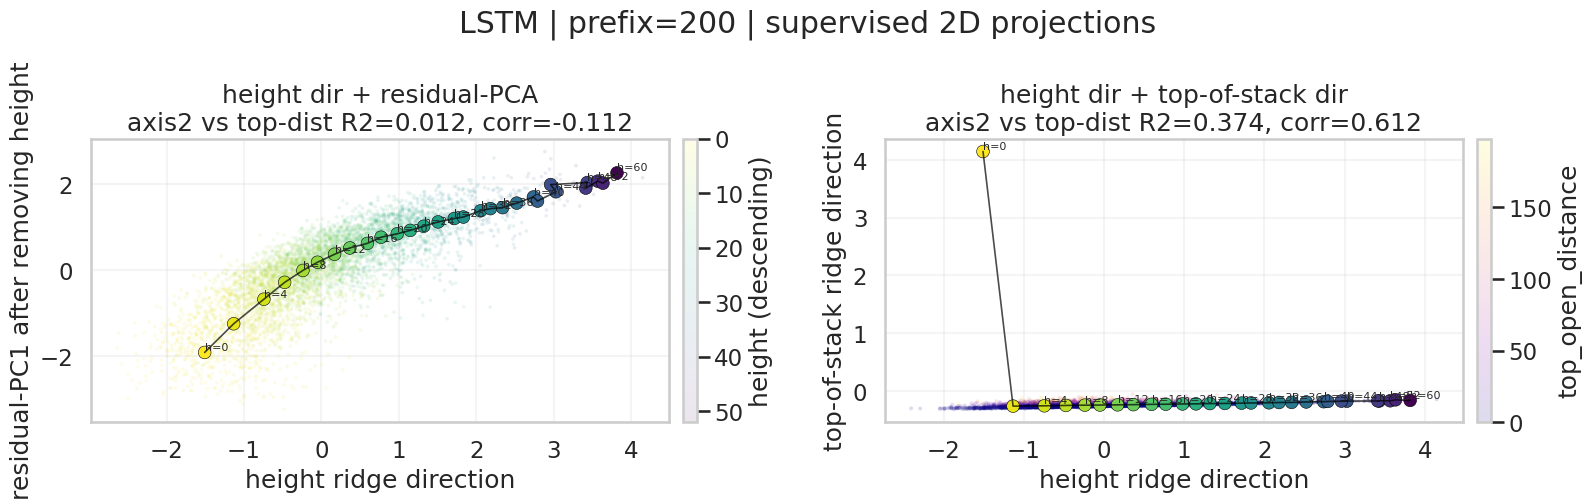

SUPERVISED 2D PROJECTION: transformer | prefix=200
residual-axis vs top-distance | R2=0.1635 | corr=-0.4043
top-axis vs top-distance      | R2=0.0540 | corr=0.2323


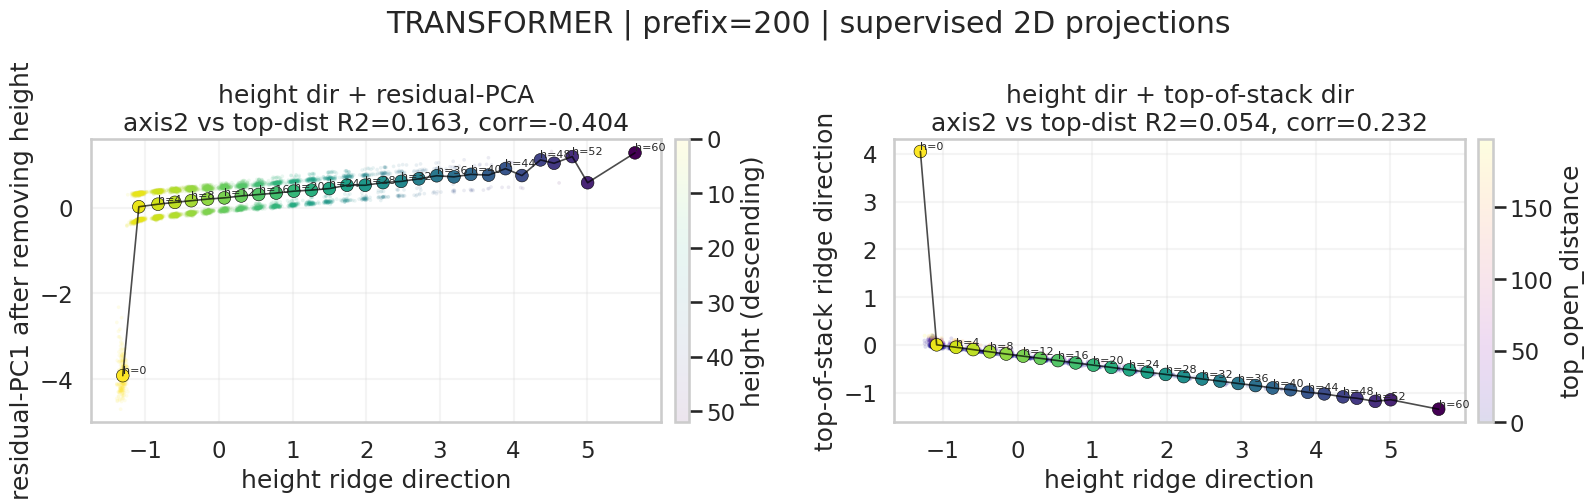

SUPERVISED 2D PROJECTION: mamba | prefix=200
residual-axis vs top-distance | R2=0.0265 | corr=-0.1627
top-axis vs top-distance      | R2=0.4482 | corr=0.6694


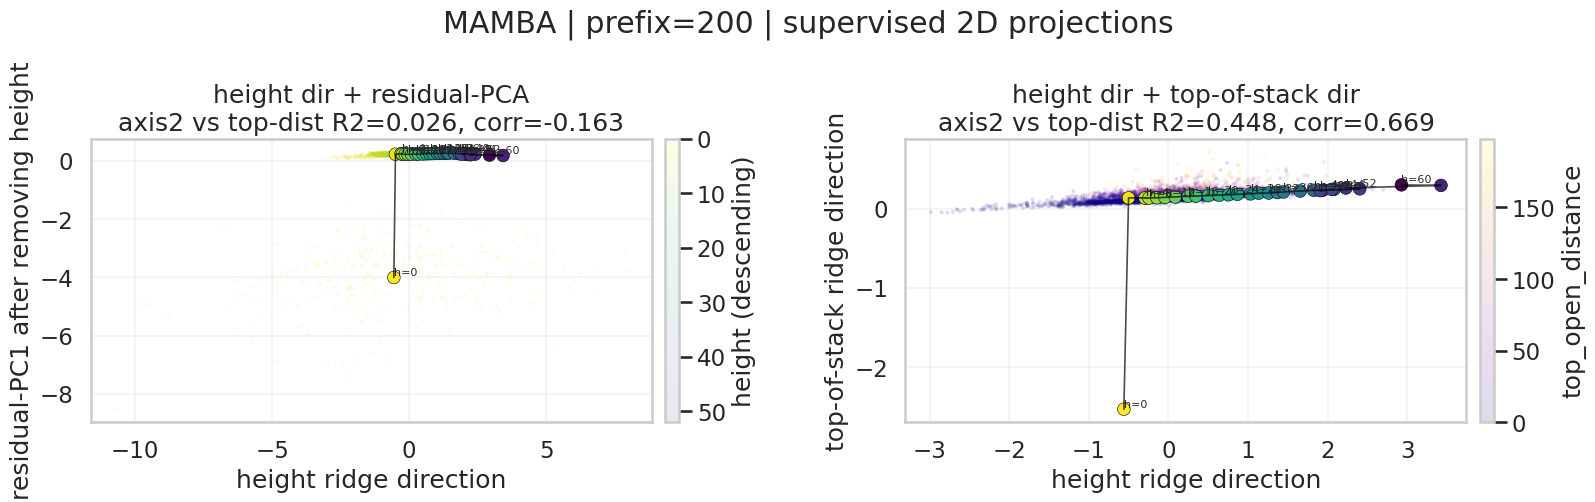

,model,residual_axis_topdist_r2,residual_axis_topdist_corr,top_axis_topdist_r2,top_axis_topdist_corr
0,rnn,0.279959,-0.529112,0.001820,-0.042660
1,lstm,0.012440,-0.111537,0.374098,0.611635
2,transformer,0.163458,-0.404300,0.053982,0.232340
3,mamba,0.026462,-0.162671,0.448155,0.669444


In [70]:
def _unit_vector(vec):
    vec = np.asarray(vec, dtype=float)
    return vec / (np.linalg.norm(vec) + 1e-12)


def _orthogonalize(vec, against):
    vec = np.asarray(vec, dtype=float)
    against = _unit_vector(against)
    out = vec - np.dot(vec, against) * against
    norm = np.linalg.norm(out)
    if norm < 1e-12:
        return out
    return out / norm


def _project_with_axes(X, axis1, axis2, *, center=None, standardize=True):
    X = np.asarray(X, dtype=float)
    if center is None:
        center = X.mean(axis=0, keepdims=True)
    Xc = X - center
    z1 = Xc @ _unit_vector(axis1)
    z2 = Xc @ _unit_vector(axis2)
    Z = np.c_[z1, z2]
    if standardize:
        Z = (Z - Z.mean(axis=0, keepdims=True)) / (Z.std(axis=0, keepdims=True) + 1e-12)
    return Z, center


def _fit_residual_axis(X_train, height_dir):
    height_dir = _unit_vector(height_dir)
    X_train = np.asarray(X_train, dtype=float)
    Xc = X_train - X_train.mean(axis=0, keepdims=True)
    resid = Xc - np.outer(Xc @ height_dir, height_dir)
    pca = PCA(n_components=1)
    pca.fit(resid)
    axis = pca.components_[0]
    axis = _orthogonalize(axis, height_dir)
    return axis, pca


def _compute_height_centroids(Z, height):
    height = np.asarray(height, dtype=int)
    uniq = np.asarray(sorted(np.unique(height).tolist()), dtype=int)
    centroids = np.stack([Z[height == h].mean(axis=0) for h in uniq], axis=0)
    return uniq, centroids


def _fit_axis_r2(axis_values, target):
    return _linear_fit_r2(np.asarray(axis_values), np.asarray(target))


def build_supervised_projection_diagnostics(model_type):
    base = all_results[model_type]
    top = top_of_stack_probe_results[model_type]

    X_train = np.asarray(base['train_data']['h'], dtype=float)
    X_test = np.asarray(base['test_data']['h'], dtype=float)
    height_train = np.asarray(base['train_data']['height'], dtype=int)
    height_test = np.asarray(base['test_data']['height'], dtype=int)

    height_probe = base['fitted']['ridge_height']
    height_dir = _unit_vector(_ridge_direction(height_probe))

    residual_axis, residual_pca = _fit_residual_axis(X_train, height_dir)
    Z_resid_train, center = _project_with_axes(X_train, height_dir, residual_axis)
    Z_resid_test, _ = _project_with_axes(X_test, height_dir, residual_axis, center=center)

    residual_axis_r2 = float('nan')
    residual_axis_topdist_r2 = float('nan')
    residual_axis_topdist_corr = float('nan')

    top_probe = top['fitted'].get('ridge_top_open_distance')
    top_axis = None
    Z_top_train = None
    Z_top_test = None
    top_axis_height_r2 = float('nan')
    top_axis_topdist_r2 = float('nan')
    top_axis_topdist_corr = float('nan')

    top_train = np.asarray(top['train_data']['top_open_distance'], dtype=int)
    top_test = np.asarray(top['test_data']['top_open_distance'], dtype=int)
    nonempty_train = np.asarray(top['train_data']['stack_nonempty']).astype(bool)
    nonempty_test = np.asarray(top['test_data']['stack_nonempty']).astype(bool)

    if top_probe is not None:
        top_axis_raw = _ridge_direction(top_probe)
        top_axis = _orthogonalize(top_axis_raw, height_dir)
        if np.linalg.norm(top_axis) > 1e-10:
            Z_top_train, _ = _project_with_axes(X_train, height_dir, top_axis, center=center)
            Z_top_test, _ = _project_with_axes(X_test, height_dir, top_axis, center=center)
            top_axis_height_r2 = _fit_axis_r2(Z_top_test[:, 1], height_test)
            if nonempty_test.any():
                top_axis_topdist_r2 = _fit_axis_r2(Z_top_test[nonempty_test, 1], top_test[nonempty_test])
                corr = np.corrcoef(Z_top_test[nonempty_test, 1], top_test[nonempty_test])[0, 1]
                top_axis_topdist_corr = float(0.0 if np.isnan(corr) else corr)

    if nonempty_test.any():
        residual_axis_topdist_r2 = _fit_axis_r2(Z_resid_test[nonempty_test, 1], top_test[nonempty_test])
        corr = np.corrcoef(Z_resid_test[nonempty_test, 1], top_test[nonempty_test])[0, 1]
        residual_axis_topdist_corr = float(0.0 if np.isnan(corr) else corr)
    residual_axis_r2 = _fit_axis_r2(Z_resid_test[:, 1], height_test)

    return {
        'model': model_type,
        'height_dir': height_dir,
        'residual_axis': residual_axis,
        'top_axis': top_axis,
        'center': center,
        'height_test': height_test,
        'top_distance_test': top_test,
        'nonempty_test': nonempty_test,
        'Z_resid_test': Z_resid_test,
        'Z_top_test': Z_top_test,
        'residual_height_centroids': _compute_height_centroids(Z_resid_test, height_test),
        'top_height_centroids': _compute_height_centroids(Z_top_test, height_test) if Z_top_test is not None else None,
        'residual_axis_height_r2': _fit_axis_r2(Z_resid_test[:, 0], height_test),
        'residual_axis_second_height_r2': residual_axis_r2,
        'residual_axis_topdist_r2': residual_axis_topdist_r2,
        'residual_axis_topdist_corr': residual_axis_topdist_corr,
        'top_axis_height_r2': top_axis_height_r2,
        'top_axis_topdist_r2': top_axis_topdist_r2,
        'top_axis_topdist_corr': top_axis_topdist_corr,
    }


def plot_supervised_2d_projections(diag, *, title, max_points=5000):
    rng = np.random.default_rng(0)
    height = np.asarray(diag['height_test'], dtype=int)
    nonempty = np.asarray(diag['nonempty_test']).astype(bool)
    top_distance = np.asarray(diag['top_distance_test'], dtype=int)
    Z_resid = np.asarray(diag['Z_resid_test'], dtype=float)
    Z_top = None if diag['Z_top_test'] is None else np.asarray(diag['Z_top_test'], dtype=float)

    idx = np.arange(len(height))
    if len(idx) > max_points:
        idx = rng.choice(idx, size=int(max_points), replace=False)
    h_plot = height[idx]
    resid_plot = Z_resid[idx]

    fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.2))

    sc0 = axes[0].scatter(resid_plot[:, 0], resid_plot[:, 1], c=h_plot, cmap='viridis_r', s=7, alpha=0.10, edgecolors='none')
    uniq_h, cent_resid = diag['residual_height_centroids']
    axes[0].plot(cent_resid[:, 0], cent_resid[:, 1], color='black', lw=1.2, alpha=0.7)
    axes[0].scatter(cent_resid[:, 0], cent_resid[:, 1], c=uniq_h, cmap='viridis_r', s=84, edgecolors='black', linewidths=0.4)
    label_every = max(1, len(uniq_h) // 10)
    for i, (x, y, h) in enumerate(zip(cent_resid[:, 0], cent_resid[:, 1], uniq_h)):
        if i % label_every == 0 or i == len(uniq_h) - 1:
            axes[0].text(x, y, f'h={int(h)}', fontsize=8, ha='left', va='bottom')
    axes[0].set_title(
        'height dir + residual-PCA\n'
        f"axis2 vs top-dist R2={diag['residual_axis_topdist_r2']:.3f}, corr={diag['residual_axis_topdist_corr']:.3f}"
    )
    axes[0].set_xlabel('height ridge direction')
    axes[0].set_ylabel('residual-PC1 after removing height')
    axes[0].grid(True, alpha=0.2)
    cbar0 = fig.colorbar(sc0, ax=axes[0], pad=0.02)
    cbar0.set_label('height (descending)')
    cbar0.ax.invert_yaxis()

    if Z_top is not None and np.linalg.norm(diag['top_axis']) > 1e-10:
        idx_top = idx[nonempty[idx]]
        if len(idx_top) == 0:
            idx_top = idx
        z_top_plot = Z_top[idx_top]
        td_plot = top_distance[idx_top]
        sc1 = axes[1].scatter(z_top_plot[:, 0], z_top_plot[:, 1], c=td_plot, cmap='plasma', s=8, alpha=0.14, edgecolors='none')
        uniq_h2, cent_top = diag['top_height_centroids']
        axes[1].plot(cent_top[:, 0], cent_top[:, 1], color='black', lw=1.2, alpha=0.7)
        axes[1].scatter(cent_top[:, 0], cent_top[:, 1], c=uniq_h2, cmap='viridis_r', s=84, edgecolors='black', linewidths=0.4)
        for i, (x, y, h) in enumerate(zip(cent_top[:, 0], cent_top[:, 1], uniq_h2)):
            if i % label_every == 0 or i == len(uniq_h2) - 1:
                axes[1].text(x, y, f'h={int(h)}', fontsize=8, ha='left', va='bottom')
        axes[1].set_title(
            'height dir + top-of-stack dir\n'
            f"axis2 vs top-dist R2={diag['top_axis_topdist_r2']:.3f}, corr={diag['top_axis_topdist_corr']:.3f}"
        )
        axes[1].set_xlabel('height ridge direction')
        axes[1].set_ylabel('top-of-stack ridge direction')
        axes[1].grid(True, alpha=0.2)
        cbar1 = fig.colorbar(sc1, ax=axes[1], pad=0.02)
        cbar1.set_label('top_open_distance')
    else:
        axes[1].text(0.5, 0.5, 'No stable top-of-stack direction available', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_axis_off()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def collect_supervised_projection_rows(diags):
    rows = []
    for model_type, diag in diags.items():
        rows.append({
            'model': model_type,
            'residual_axis_topdist_r2': diag['residual_axis_topdist_r2'],
            'residual_axis_topdist_corr': diag['residual_axis_topdist_corr'],
            'top_axis_topdist_r2': diag['top_axis_topdist_r2'],
            'top_axis_topdist_corr': diag['top_axis_topdist_corr'],
        })
    return rows


supervised_projection_results = {}
for model_type in MODEL_TYPES:
    print('=' * 80)
    print(f'SUPERVISED 2D PROJECTION: {model_type} | prefix={PREFIX_LENGTH}')
    diag = build_supervised_projection_diagnostics(model_type)
    supervised_projection_results[model_type] = diag
    print(
        f"residual-axis vs top-distance | R2={diag['residual_axis_topdist_r2']:.4f} | corr={diag['residual_axis_topdist_corr']:.4f}"
    )
    print(
        f"top-axis vs top-distance      | R2={diag['top_axis_topdist_r2']:.4f} | corr={diag['top_axis_topdist_corr']:.4f}"
    )
    plot_supervised_2d_projections(
        diag,
        title=f'{model_type.upper()} | prefix={PREFIX_LENGTH} | supervised 2D projections',
    )


supervised_projection_rows = collect_supervised_projection_rows(supervised_projection_results)
display(pd.DataFrame(supervised_projection_rows))


比起直接用 PCA，用更有解释性的坐标轴，是否更容易看清二维结构。
- `w_height` 是监督式 Ridge probe 用来预测 `height` 的方向。
- 第一种投影使用：
  - 轴 1：`w_height`；
  - 轴 2：去掉 `w_height` 分量之后，残差里的第一主成分（residual-PCA direction）。
- 第二种投影使用：
  - 轴 1：`w_height`；
  - 轴 2：`w_top_open_distance`，并且先对 `w_height` 做正交化，所以第二轴只表示“height 之外的那一部分 top-of-stack 信息”。

最后的 summary table 会报告这些第二轴对 `top_open_distance` 的解释能力。

- `height = left - right`，是在固定 prefix 处定义的。
- `w_height` 是从 hidden state 线性读出 `height` 的方向。
- `residual-PCA axis` 是先去掉 `w_height` 对齐的分量之后，在剩余 hidden state 里最大的无监督方向。
- `top-of-stack axis` 是监督式 `top_open_distance` 读出方向，并且已经对 `w_height` 做了正交化。

如果在 `height + residual-PCA` 这个坐标系下，点云明显变得更干净，就说明第二个自由度是真实存在的，但不一定和 stack 直接相关。如果在 `height + top-of-stack axis` 这个坐标系下，点云更干净，而且第二轴对 `top_open_distance` 的预测也很强，那才更支持“额外厚度就是 stack-related 变量”这个解释。如果这两种第二轴都不能干净地解释第二维，那额外几何更可能来自别的潜变量，比如当前 token phase、端点 regime，或者条件方差结构。

这些投影更适合被当作诊断性比较，而不是直接证明“第二轴有因果机制含义”。在当前这个单括号设定里，`top_open_distance` 这个轴本身并不特别有说服力，所以更有信息量的往往是 `height + residual-PCA`。这和 Section 17 的 attention 结果是一致的：模型看起来确实存了 `height` 之外的某些东西，但这些东西并不像一个干净的栈指针变量。


## 19. Transformer Current-Token Layers And Variance

Test whether the two-layer structure in the transformer projections is explained by the identity of the current token at the end of the prefix. This section reprojects the transformer states using the same global mean-PCA basis but splits the data by `current token = '('` versus `current token = ')'`, exports conditioned 3D HTML views, and then measures how class-conditional variance changes with height along the main trajectory versus transverse to it.


/tmp/ipykernel_1694/1828359418.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


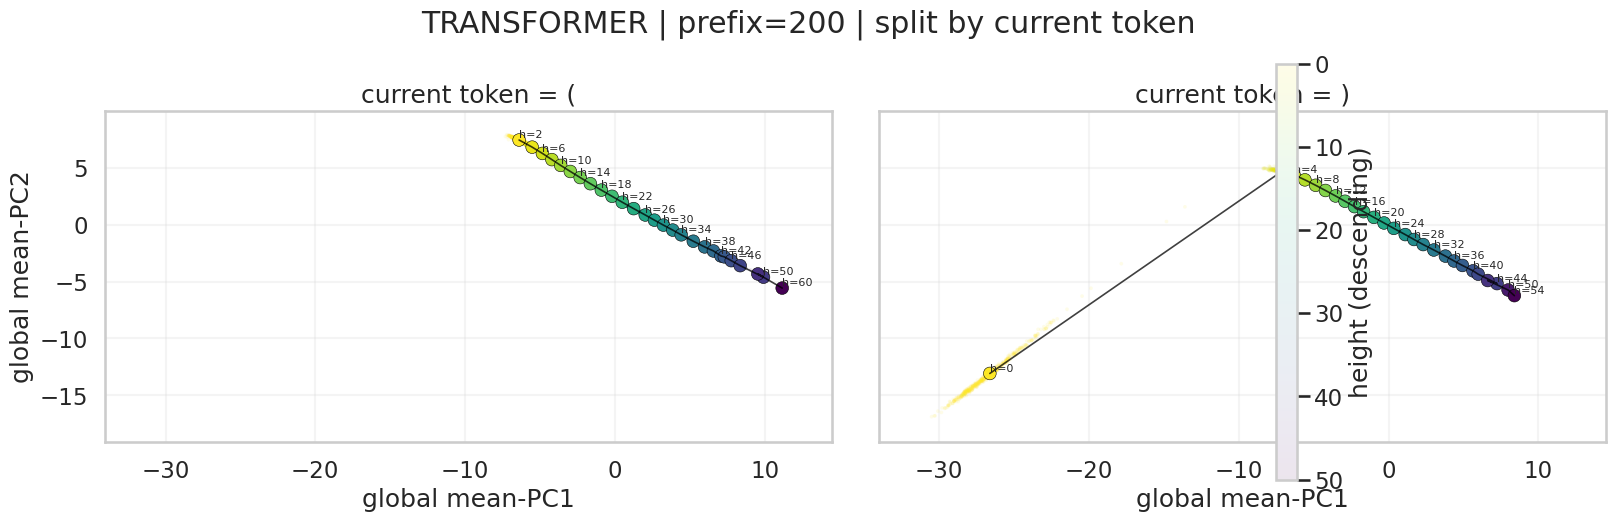

Transformer current-token 3D HTML files:
          open: /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_reference_style/formal_long_pairs200_len400/dyck_no_noise_pairs200_len400/manifold_3d_html/transformer_current_token_split/transformer_prefix200_current_open.html
         close: /home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/dyck_reference_style/formal_long_pairs200_len400/dyck_no_noise_pairs200_len400/manifold_3d_html/transformer_current_token_split/transformer_prefix200_current_close.html


,condition,height,n,var_pc1,var_pc2,var_pc3,var_transverse,var_total3d
0,all,0,1098,3.439902,3.932814,0.029373,3.962187,7.402089
1,all,2,2331,0.225904,1.868044,6.217205,8.085249,8.311153
2,all,4,2177,0.237213,1.509892,6.043433,7.553325,7.790538
3,all,6,2029,0.236833,1.396300,5.857858,7.254158,7.490991
4,all,8,1928,0.250164,1.346148,5.661823,7.007971,7.258135


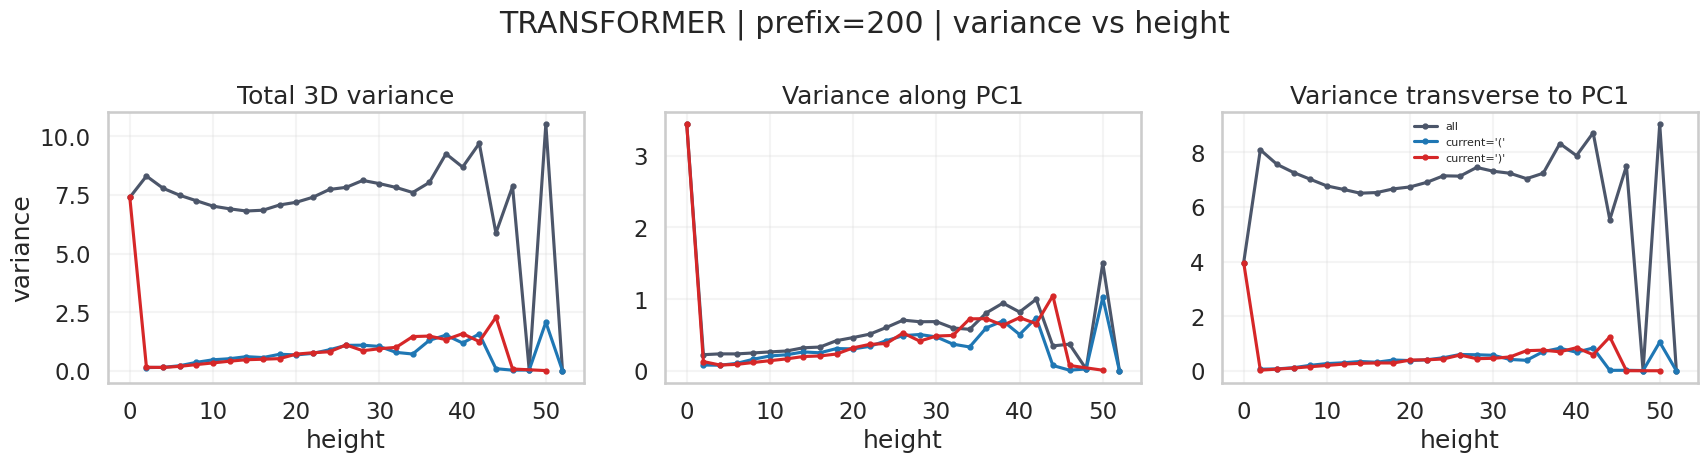

,condition,low_tail_total_var,mid_total_var,high_tail_total_var,low_tail_transverse_var,mid_transverse_var,high_tail_transverse_var
0,all,7.748693,7.643885,4.609661,6.713730,7.059170,4.133874
1,current_open,0.220475,0.909274,0.538615,0.113590,0.493313,0.273016
2,current_close,1.975265,0.805959,0.909503,1.039835,0.423707,0.461925


: 

In [ ]:
def _get_oriented_mean_pca_basis(diag):
    basis = np.asarray(diag['pca'].components_, dtype=float).copy()
    mean_centered = np.asarray(diag['means'] if 'means' in diag else diag['mean_coords'] * 0.0)
    if 'means' in diag:
        mean_centered = np.asarray(diag['means'], dtype=float) - np.asarray(diag['center'], dtype=float)
    else:
        return basis
    coords = mean_centered @ basis.T
    heights = np.asarray(diag['heights'], dtype=int)
    corr = np.corrcoef(coords[:, 0], heights)[0, 1] if len(heights) > 1 else 1.0
    if np.isnan(corr):
        corr = 0.0
    if corr < 0:
        basis[0] *= -1
    return basis


def _transformer_current_token_split(data, *, open_token=None, close_token=None):
    if open_token is None or close_token is None:
        cfg = make_sampler(seed_offset=0).config
        open_token = cfg.open_token
        close_token = cfg.close_token
    prefix = np.asarray(data['prefix'])
    current_token = prefix[:, -1]
    current_is_open = current_token == open_token
    current_symbol = np.where(current_is_open, '(', ')')
    out = {k: np.asarray(v) for k, v in data.items()}
    out['current_token'] = current_token
    out['current_is_open'] = current_is_open.astype(int)
    out['current_symbol'] = current_symbol
    return out


def _project_transformer_with_global_basis(data, diag, dims=3):
    X = np.asarray(data['h'], dtype=float)
    center = np.asarray(diag['center'], dtype=float)
    basis = _get_oriented_mean_pca_basis(diag)
    dims = min(int(dims), basis.shape[0])
    coords = (X - center) @ basis[:dims].T
    return coords, basis[:dims], center


def _height_centroids_from_coords(coords, height):
    height = np.asarray(height, dtype=int)
    uniq = np.asarray(sorted(np.unique(height).tolist()), dtype=int)
    centroids = np.stack([coords[height == h].mean(axis=0) for h in uniq], axis=0)
    return uniq, centroids


def plot_transformer_current_token_2d(data, diag, *, max_points=5000):
    cfg = make_sampler(seed_offset=0).config
    data = _transformer_current_token_split(data, open_token=cfg.open_token, close_token=cfg.close_token)
    coords, _, _ = _project_transformer_with_global_basis(data, diag, dims=2)
    height = np.asarray(data['height'], dtype=int)
    is_open = np.asarray(data['current_is_open']).astype(bool)

    rng = np.random.default_rng(0)
    fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.4), sharex=True, sharey=True)
    x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
    y_min, y_max = coords[:, 1].min(), coords[:, 1].max()
    x_pad = 0.08 * max(1e-6, x_max - x_min)
    y_pad = 0.08 * max(1e-6, y_max - y_min)

    for ax, mask, token_label in zip(axes, [is_open, ~is_open], ['current token = (', 'current token = )']):
        idx = np.flatnonzero(mask)
        if len(idx) > max_points:
            idx = rng.choice(idx, size=int(max_points), replace=False)
        pts = coords[idx]
        h = height[idx]
        sc = ax.scatter(pts[:, 0], pts[:, 1], c=h, cmap='viridis_r', s=7, alpha=0.10, edgecolors='none')
        uniq_h, centroids = _height_centroids_from_coords(coords[mask], height[mask])
        ax.plot(centroids[:, 0], centroids[:, 1], color='black', lw=1.2, alpha=0.75)
        ax.scatter(centroids[:, 0], centroids[:, 1], c=uniq_h, cmap='viridis_r', s=84, edgecolors='black', linewidths=0.4)
        label_every = max(1, len(uniq_h) // 10)
        for i, (x, y, hh) in enumerate(zip(centroids[:, 0], centroids[:, 1], uniq_h)):
            if i % label_every == 0 or i == len(uniq_h) - 1:
                ax.text(x, y, f'h={int(hh)}', fontsize=8, ha='left', va='bottom')
        ax.set_title(token_label)
        ax.set_xlabel('global mean-PC1')
        ax.grid(True, alpha=0.2)
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
    axes[0].set_ylabel('global mean-PC2')
    cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), pad=0.02)
    cbar.set_label('height (descending)')
    cbar.ax.invert_yaxis()
    fig.suptitle(f'TRANSFORMER | prefix={PREFIX_LENGTH} | split by current token')
    plt.tight_layout()
    plt.show()


def _pad_to_dim(arr, target_dim=3):
    arr = np.asarray(arr, dtype=float)
    if arr.shape[1] >= target_dim:
        return arr[:, :target_dim]
    return np.pad(arr, ((0, 0), (0, target_dim - arr.shape[1])), mode='constant')


def build_conditioned_transformer_3d_html(*, title, sample_coords, sample_height, mean_coords, mean_height, curve_points=None):
    sample_coords = _pad_to_dim(sample_coords, 3)
    mean_coords = _pad_to_dim(mean_coords, 3)
    curve_points = None if curve_points is None else _pad_to_dim(curve_points, 3)
    payload = {
        'sample': {
            'x': sample_coords[:, 0].tolist(),
            'y': sample_coords[:, 1].tolist(),
            'z': sample_coords[:, 2].tolist(),
            'height': np.asarray(sample_height, dtype=int).tolist(),
        },
        'mean': {
            'x': mean_coords[:, 0].tolist(),
            'y': mean_coords[:, 1].tolist(),
            'z': mean_coords[:, 2].tolist(),
            'height': np.asarray(mean_height, dtype=int).tolist(),
            'text': [f'h={int(h)}' for h in np.asarray(mean_height, dtype=int)],
        },
        'curve': None if curve_points is None else {
            'x': curve_points[:, 0].tolist(),
            'y': curve_points[:, 1].tolist(),
            'z': curve_points[:, 2].tolist(),
        },
    }
    curve_trace = """
    const curveTrace = {
      type: 'scatter3d',
      mode: 'lines',
      name: 'full fitted curve',
      x: payload.curve.x,
      y: payload.curve.y,
      z: payload.curve.z,
      line: { color: '#111111', width: 6 },
      hoverinfo: 'skip',
    };
    traces.push(curveTrace);
    """ if curve_points is not None else ""
    return f"""<!DOCTYPE html>
<html lang=\"en\">
<head>
  <meta charset=\"utf-8\" />
  <title>{title}</title>
  <script src=\"https://cdn.plot.ly/plotly-2.35.2.min.js\"></script>
  <style>
    body {{ font-family: Arial, sans-serif; margin: 0; background: #f8f7f4; color: #202124; }}
    .wrap {{ max-width: 1400px; margin: 0 auto; padding: 20px 24px 28px; }}
    h1 {{ margin: 0 0 8px; font-size: 28px; }}
    p {{ margin: 0 0 14px; color: #4b5563; line-height: 1.5; }}
    #plot {{ width: 100%; height: 78vh; min-height: 720px; border-radius: 14px; overflow: hidden; background: white; box-shadow: 0 10px 30px rgba(0,0,0,0.08); }}
  </style>
</head>
<body>
  <div class=\"wrap\">
    <h1>{title}</h1>
    <p>Transformer states projected into the same global mean-PCA basis, but filtered by the current token identity at the end of the prefix.</p>
    <div id=\"plot\"></div>
  </div>
  <script>
    const payload = {json.dumps(payload)};
    const traces = [];
    const sampleTrace = {{
      type: 'scatter3d',
      mode: 'markers',
      name: 'samples',
      x: payload.sample.x,
      y: payload.sample.y,
      z: payload.sample.z,
      marker: {{
        size: 2.6,
        opacity: 0.12,
        color: payload.sample.height,
        colorscale: 'Viridis',
        reversescale: true,
        colorbar: {{ title: 'height (descending)' }},
      }},
      hovertemplate: 'height=%{{marker.color}}<br>x=%{{x:.3f}}<br>y=%{{y:.3f}}<br>z=%{{z:.3f}}<extra></extra>',
    }};
    const meanTrace = {{
      type: 'scatter3d',
      mode: 'markers+text',
      name: 'height means',
      x: payload.mean.x,
      y: payload.mean.y,
      z: payload.mean.z,
      text: payload.mean.text,
      textposition: 'top center',
      marker: {{
        size: 7,
        color: payload.mean.height,
        colorscale: 'Viridis',
        reversescale: true,
        line: {{ color: '#111827', width: 1 }},
      }},
      hovertemplate: '%{{text}}<br>x=%{{x:.3f}}<br>y=%{{y:.3f}}<br>z=%{{z:.3f}}<extra></extra>',
    }};
    traces.push(sampleTrace);
    {curve_trace}
    traces.push(meanTrace);
    const layout = {{
      margin: {{ l: 0, r: 0, t: 20, b: 0 }},
      paper_bgcolor: '#f8f7f4',
      plot_bgcolor: '#ffffff',
      legend: {{ orientation: 'h', y: 1.02, x: 0.0 }},
      scene: {{
        xaxis: {{ title: 'global mean-PC1', backgroundcolor: '#fafaf9', gridcolor: '#d1d5db', zerolinecolor: '#9ca3af' }},
        yaxis: {{ title: 'global mean-PC2', backgroundcolor: '#fafaf9', gridcolor: '#d1d5db', zerolinecolor: '#9ca3af' }},
        zaxis: {{ title: 'global mean-PC3', backgroundcolor: '#fafaf9', gridcolor: '#d1d5db', zerolinecolor: '#9ca3af' }},
        camera: {{ eye: {{ x: 1.45, y: 1.55, z: 0.95 }} }},
        aspectmode: 'data',
      }},
    }};
    Plotly.newPlot('plot', traces, layout, {{responsive: true, displaylogo: false}});
  </script>
</body>
</html>
"""


def export_transformer_current_token_3d_html(data, diag, *, prefix_length=PREFIX_LENGTH, max_points=12000):
    cfg = make_sampler(seed_offset=0).config
    data = _transformer_current_token_split(data, open_token=cfg.open_token, close_token=cfg.close_token)
    coords, _, _ = _project_transformer_with_global_basis(data, diag, dims=3)
    height = np.asarray(data['height'], dtype=int)
    is_open = np.asarray(data['current_is_open']).astype(bool)
    curve_points = np.asarray(diag['curve_points'], dtype=float)
    out_dir = RESULTS_ROOT / 'manifold_3d_html' / 'transformer_current_token_split'
    out_dir.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(0)
    paths = {}

    for token_label, mask in [('open', is_open), ('close', ~is_open)]:
        idx = np.flatnonzero(mask)
        if len(idx) > max_points:
            idx = rng.choice(idx, size=int(max_points), replace=False)
        sample_coords = coords[idx]
        sample_height = height[idx]
        uniq_h, centroids = _height_centroids_from_coords(coords[mask], height[mask])
        html = build_conditioned_transformer_3d_html(
            title=f'TRANSFORMER | prefix={prefix_length} | current token = {'(' if token_label == 'open' else ')'}',
            sample_coords=sample_coords,
            sample_height=sample_height,
            mean_coords=centroids,
            mean_height=uniq_h,
            curve_points=curve_points,
        )
        out_path = out_dir / f'transformer_prefix{int(prefix_length)}_current_{token_label}.html'
        out_path.write_text(html, encoding='utf-8')
        paths[token_label] = out_path
    return paths


def compute_transformer_variance_by_height(data, diag):
    cfg = make_sampler(seed_offset=0).config
    data = _transformer_current_token_split(data, open_token=cfg.open_token, close_token=cfg.close_token)
    coords, _, _ = _project_transformer_with_global_basis(data, diag, dims=3)
    height = np.asarray(data['height'], dtype=int)
    current_symbol = np.asarray(data['current_symbol'])

    rows = []
    for cond_name, mask in [('all', np.ones(len(height), dtype=bool)), ('current_open', current_symbol == '('), ('current_close', current_symbol == ')')]:
        hs = np.asarray(sorted(np.unique(height[mask]).tolist()), dtype=int)
        for h in hs:
            pts = coords[mask & (height == h)]
            if len(pts) < 2:
                continue
            var_pc1 = float(np.var(pts[:, 0], ddof=0))
            var_pc2 = float(np.var(pts[:, 1], ddof=0))
            var_pc3 = float(np.var(pts[:, 2], ddof=0)) if pts.shape[1] >= 3 else 0.0
            rows.append({
                'condition': cond_name,
                'height': int(h),
                'n': int(len(pts)),
                'var_pc1': var_pc1,
                'var_pc2': var_pc2,
                'var_pc3': var_pc3,
                'var_transverse': float(var_pc2 + var_pc3),
                'var_total3d': float(var_pc1 + var_pc2 + var_pc3),
            })
    return pd.DataFrame(rows)


def plot_transformer_variance_by_height(df):
    fig, axes = plt.subplots(1, 3, figsize=(17.2, 4.8), sharex=True)
    cond_styles = {
        'all': ('#4c566a', 'all'),
        'current_open': ('#1f77b4', "current='('") ,
        'current_close': ('#d62728', "current=')'") ,
    }
    metrics = [
        ('var_total3d', 'Total 3D variance'),
        ('var_pc1', 'Variance along PC1'),
        ('var_transverse', 'Variance transverse to PC1'),
    ]
    for ax, (metric, title) in zip(axes, metrics):
        for cond, (color, label) in cond_styles.items():
            sub = df[df['condition'] == cond].sort_values('height')
            ax.plot(sub['height'], sub[metric], marker='o', ms=3.5, color=color, label=label)
        ax.set_title(title)
        ax.set_xlabel('height')
        ax.grid(True, alpha=0.2)
    axes[0].set_ylabel('variance')
    axes[2].legend(frameon=False, fontsize=8)
    fig.suptitle(f'TRANSFORMER | prefix={PREFIX_LENGTH} | variance vs height')
    plt.tight_layout()
    plt.show()


def summarize_transformer_variance(df):
    summary_rows = []
    for cond in ['all', 'current_open', 'current_close']:
        sub = df[df['condition'] == cond].sort_values('height')
        if len(sub) == 0:
            continue
        tail_n = min(4, len(sub))
        head = sub.head(tail_n)
        tail = sub.tail(tail_n)
        mid = sub.iloc[len(sub) // 3 : len(sub) - len(sub) // 3] if len(sub) >= 6 else sub
        summary_rows.append({
            'condition': cond,
            'low_tail_total_var': float(head['var_total3d'].mean()),
            'mid_total_var': float(mid['var_total3d'].mean()),
            'high_tail_total_var': float(tail['var_total3d'].mean()),
            'low_tail_transverse_var': float(head['var_transverse'].mean()),
            'mid_transverse_var': float(mid['var_transverse'].mean()),
            'high_tail_transverse_var': float(tail['var_transverse'].mean()),
        })
    return pd.DataFrame(summary_rows)


transformer_full_diag = manifold_search_results['transformer']
transformer_test_data = all_results['transformer']['test_data']
plot_transformer_current_token_2d(transformer_test_data, transformer_full_diag)
transformer_split_html_paths = export_transformer_current_token_3d_html(transformer_test_data, transformer_full_diag)
print('Transformer current-token 3D HTML files:')
for name, path in transformer_split_html_paths.items():
    print(f'  {name:>12s}: {path}')

transformer_variance_df = compute_transformer_variance_by_height(transformer_test_data, transformer_full_diag)
display(transformer_variance_df.head())
plot_transformer_variance_by_height(transformer_variance_df)
display(summarize_transformer_variance(transformer_variance_df))


这一节测试的是：transformer 投影里肉眼可见的“两层结构”，是否主要由 prefix 末尾那个当前 token 的身份驱动。
- 这里的 `current token` 指 `prefix[-1]`，也就是构成当前 hidden state 的最后一个输入 token。
- 数据被分成两个子集：
  - `current token = '('`；
  - `current token = ')'`。

这两个子集都投到同一个全局 mean-PCA basis 里，也就是和完整 transformer manifold 相同的坐标系，因此图上的差异可以解释为条件分组本身，而不是换了 basis。然后这一节还会导出条件化的 3D HTML，并在这个相同 basis 里计算随 `height` 变化的 variance。

定义：

- `var_pc1` 是固定 `height` 后，在第一条全局 mean-PC 方向上的类内方差。
- `var_pc2` 和 `var_pc3` 是固定 `height` 后，在第二、第三条全局 mean-PC 方向上的类内方差。
- `var_transverse = var_pc2 + var_pc3` 表示在这个 3D 图里，正交于主轨迹方向的方差。
- `var_total3d = var_pc1 + var_pc2 + var_pc3` 表示显示出来的 3D 子空间里的总类内方差。
- summary table 会比较 low-height tail、middle heights 和 high-height tail，看看 variance 是否集中在端点区域。

- 如果按当前 token 分组之后，两层结构在每个子集内部明显塌缩，那原来看到的两层就主要是由 `current token = '('` 和 `current token = ')'` 导致的。
- 如果分组以后两层依然存在，那说明还有别的潜变量在起作用。
- 对 variance 图来说：
  - `var_pc1` 增长，表示点云沿主轨迹方向被拉长；
  - `var_transverse` 增长，表示点云在横向上扩散，偏离主轨迹；
  - 尾部特异性的增长，说明端点 regime 在几何上和中段不同。

对当前 transformer 图的解释：

- 按 `(` 和 `)` 条件化之后，图明显变干净，支持两层结构由当前 token 决定：transformer 的全局 2D 结构里有一部分其实是 `height + current-token phase`。
- 条件化以后，尾部 variance 较小。
- `var_transverse` 在控制当前 token 之后明显下降，说明原来看到的 manifold 厚度就很大一部分只是“隐藏的二值分层”，而不是一个连续变化的第二维。
